<img src="https://drive.google.com/uc?export=view&id=1Q6vQcIWFPY27isBepABpJ7nroUNKox_Z" width="100%">


# La Voz de los Medios: Procesamiento de Lenguaje Natural en Noticias Colombianas

### Grupo No. 4

---

- Santiago Ruiz Rozo <<sruiz899@gmail.com>>
- Pablo Alejandro Reyes Granados <<alejogranados229@gmail.com>>
- Kevin Andrés Martínez Martínez <<kevinmartinez.ingbiom@gmail.com>>


## **1. Marco de Proyecto**

---


- ¿Quién es el cliente o los beneficiarios del proyecto? ¿En qué dominio se encuentran (marketing, medicina, entre otros)?

El principal beneficiario de este proyecto son los actores que requieren comprender de manera rápida, estructurada y confiable el panorama actual de Colombia a partir de la gran cantidad de información publicada diariamente en los medios de comunicación. Entre ellos se encuentran: ciudadanos interesados en informarse mejor, investigadores sociales y académicos, empresas de consultoría y analítica de datos, así como organismos públicos y privados que necesitan detectar tendencias sociales, políticas y económicas. En este sentido, el dominio del proyecto se ubica principalmente en la intersección de comunicación, ciencia de datos y análisis de información socioeconómica, con aplicaciones relevantes en marketing, ciencias sociales y estudios de opinión pública.

- ¿Qué problemas del negocio o del dominio estamos tratando de solucionar?

El problema que se busca solucionar es la fragmentación y sobrecarga de noticias colombianas: el ciudadano promedio y las instituciones enfrentan cientos de noticias diarias provenientes de múltiples fuentes, lo que dificulta obtener una visión clara, objetiva y organizada de los principales temas de actualidad. Además, los textos suelen estar sesgados por la línea editorial de cada medio, lo que impide una comprensión total de los eventos de la actualidad. Nuestro proyecto busca centralizar, limpiar y analizar sistemáticamente estas noticias mediante técnicas de procesamiento de lenguaje natural (NLP), como topic modeling, named entity recognition (NER) y modelos predictivos de clasificación temática. De esta manera, el proyecto no solo resuelve la dificultad de acceder a información dispersa y ruidosa, sino que también provee un radar de actualidad que permite identificar qué temas dominan en el boca a boca actual.


### **1.2. Alcance**

---


- ¿Qué solución de procesamiento de lenguaje natural tratamos de implementar? ¿Qué se hará?

Las principales técnicas de procesamiento de lenguaje natural que se aplicarán sobre el corpus de noticias extraídas para el período de tiempo definido serán la implementación de modelos de clasificación de Machine Learning sobre los tokens de los cuerpos de las noticias, utilizando un preprocesamiento de BoW y/o TF-IDF. Esto se hará para lograr un modelo supervisado preciso de categorización de las noticias, basándose en la frecuencia de las palabras que aparecen en el texto. Puede ser necesario estandarizar las palabras usando stemming o lematización, con el objetivo de enfocarse en la raíz de una palabra y no en sus conjugaciones.

También, se aplicará un modelo preentrenado de Spacy en español a cada documento (noticia). De esta forma, se buscará identificar entidades nombradas (NER) recurrentes en los cuerpos de las noticias, analizando qué entidades tienen mayor peso en las noticias en general y por categorías. Así, se podrá entender cuáles son los enfoques que han tenido las noticias durante el período de tiempo definido.

- ¿De qué forma el cliente o beneficiario utilizará el producto del proyecto?

El producto final brindará a los clientes datos de calidad y un entendimiento del panorama general de los productos emitidos por medios de comunicación colombianos, permitiendo entender el peso e importancia que le dan a las diferentes categorías, y qué temas y entidades son frecuentes en la redacción de las noticias. Con ello, se pueden realizar análisis de mayor profundidad sobre la actualidad del país y, también, se pueden definir temáticas de interés de los lectores, de acuerdo a la importancia que le dan los grandes periódicos.

Adicionalmente, tener un modelo de clasificación de noticias según su contenido puede ser de gran utilidad si se quiere clasificar material proveniente de otras fuentes (noticias de redes sociales, tweets, transcripciones de videos de noticias de televisión o medios digitales, artículos, comentarios, hilos de twitter, foros, etc.). Con esto, se puede aumentar la volumetría de documentos o tendencias en los diferentes medios, y entender qué temas llaman más la atención de los consumidores, o qué temas resultan ser más recurrentes en los medios digitales.


### **1.3. Plan**

---


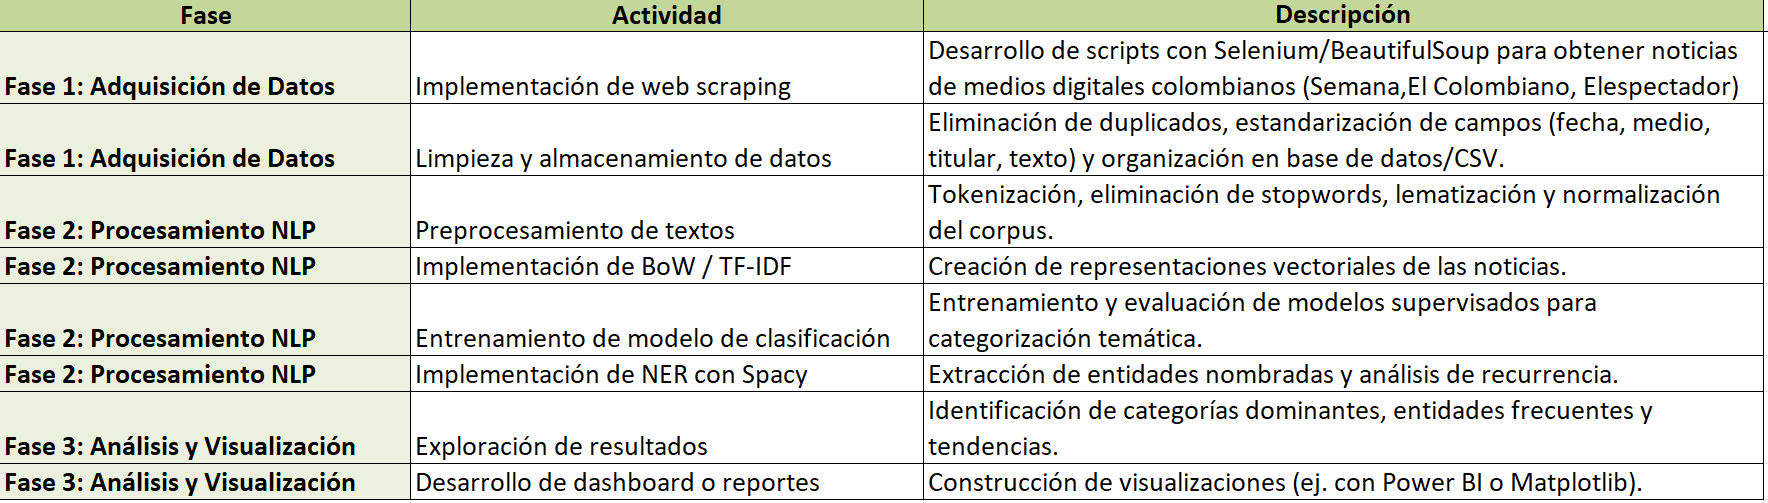


## **2. Definición del Corpus**

---


### **2.1. Origen**

---


- ¿De dónde vienen los textos?

Los datos provienen de las páginas web de tres de los periódicos y revistas más grandes del país: [El Espectador](https://www.elespectador.com/), [Semana](https://www.semana.com/) y [El Colombiano](https://www.elcolombiano.com/). De aquí, se obtienen las noticias o articulos realizados y publicados en agosto de 2025.

- ¿Se usa alguna herramienta o proceso para la descarga de la información textual?

Para la extracción de la información, se emplearon diferentes técnicas de web scraping personalizadas para cada página. Algunas de las páginas tienen un comportamiento dinámico, por lo que fue necesario el uso de Selenium. El cuerpo, el título, la categoría y demás datos se extrajeron mediante la librería BeautifulSoup (bs4) y el uso de expresiones regulares. (_ver sección 2.2.1_)

- ¿Qué tipo de textos estamos manejando?

Los datos se encuentran almacenados en formato columnar (.parquet), y presentan los siguientes campos:

- `fecha`: Fecha de publicación de la noticia o artículo.
- `titulo`: Título o encabezado de la noticia o artículo.
- `cuerpo`: Cuerpo o contenido de la noticia o artículo.
- `url`: Url donde de donde se realizó el scrapping estático.
- `categoria`: Categoría de la noticia según la fuente.
- `fuente`: Periódico, diario o revista de la cual publicó el texto.


### **2.2. Carga o Adquisición de Textos**

---


- Esta sección contiene las celdas de código utilizadas para obtener y procesar los datos de cada medio:
  - **REVISTA SEMANA** → 2 celdas ocultas.
  - **EL COLOMBIANO** → 1 celda oculta.
  - **EL ESPECTADOR** → 7 celdas ocultas.
- Cada “chunk” corresponde al **script de scrapins** para ese medio, garantizando que los resultados se integren en un formato homogéneo y listo para análisis posterior.


##### **REVISTA SEMANA**


In [ ]:
!pip install requests
!pip install bs4

!wget -q -O - https://dl.google.com/linux/linux_signing_key.pub | apt-key add -
!sh -c 'echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list'
!apt-get update
!apt-get install -y google-chrome-stable

!pip install selenium webdriver-manager

In [ ]:
import requests
import re

import time
import logging

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager

import pandas as pd
import numpy as np

from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import bs4

import os

from google.colab import drive

drive.mount('/content/drive')

logger = logging.getLogger()
logger.setLevel(logging.INFO)

# General
drive_path = '/content/drive/MyDrive/Diplomado_MLDS-UNAL/M4_PLN/00_proyecto/semana_news/'
base_Semana_url = "https://www.semana.com/"
complete_Semana_catalog_ls = [
    'nacion','politica','economia','deportes','tecnologia','semana-tv','tv',
    'semanaplay','salud','opinion','educacion','cultura','loterias','mundo',
    'turismo','como','vehiculos','finanzas','sostenible','confidenciales',
    'especiales','gente','actualidad','foros-semana/foros-anteriores','mejor-colombia',
    'mujeres','hablan-las-marcas','semanarural',
    'fotos','emprendimientos','impresa','empleos',
]
discarded_Semana_catalog_ls = [
    'fotos','emprendimientos','impresa','empleos','mujeres','semanarural',
    'semanaplay','opinion','mejor-colombia','economia',
]

# Catalog
##  regex
semana_catalog_ls = list(set(complete_Semana_catalog_ls) - set(discarded_Semana_catalog_ls))
pattern_catalog_soup = r'href=\"(.+?)\" (?:target=\"_self\" )?rel=\"noopener\"'
pattern_catalog_canonical = r'\"canonical_url\":\"(.+?)\"'

# News content
##  regex
trim_pattern = r'\<script type=\"application\/ld\+json\"\>(.*?)\<\/script\>'

## html relevant tags
tag_ls = ['headline', 'articleSection', 'datePublished', 'articleBody']
num_of_ver_mas_clicks = 60

def get_content_from_news(text: str, tag_ls: list, category: str, url: str) -> dict:
  content_dict = {}
  for tag in tag_ls:
    tag_pattern = r'\"{}\": \"(.*?)\",'.format(tag)
    if len(re.findall(tag_pattern, text)) != 0:
      content_dict[tag] = re.findall(tag_pattern, text)[0]
      logger.info(f"Successfully added: {tag}: {content_dict[tag]}")
    else:
      logger.exception(f"Error getting: {tag}")
      content_dict[tag] = None
  content_dict["scrappedCategory"] = category
  content_dict["sourceUrl"] = url
  return content_dict

def get_selenium_driver() -> webdriver:

  chrome_options = Options()
  chrome_options.add_argument("--headless=new")
  chrome_options.add_argument("--no-sandbox")
  chrome_options.add_argument("--disable-dev-shm-usage")
  chrome_options.add_argument("--disable-blink-features=AutomationControlled")

  chrome_options.binary_location = "/usr/bin/google-chrome"

  driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
  return driver

def access_to_Semana_category_news_catalog(
    driver: webdriver,
    category: str,
    base_Semana_url: str = "https://www.semana.com/",
    ver_mas_clicks_num: int = 10
) -> str:

  web_route = str(base_Semana_url) + str(category) + "/"
  print(web_route)
  driver.get(web_route)
  logger.info('Waiting 20 seconds')
  time.sleep(20)
  #get_rendered_screenshot(driver)

  try:
    recibir_notification_button = driver.find_element(By.ID, "onesignal-slidedown-cancel-button")
    recibir_notification_button.click()
    logger.info('Successfully clicked "recibir notification" button')
  except:
    logger.info('No "recibir notification" button found')
  time.sleep(1)
  #get_rendered_screenshot(driver)

  try:
    consent_use_personal_data_button = driver.find_element(By.CLASS_NAME, "fc-button-label")
    consent_use_personal_data_button.click()
    logger.info('Successfully clicked "consent use personal data" button')
  except:
    logger.info('No "consent use personal data" button found')
  time.sleep(1)
  #get_rendered_screenshot(driver)

  button_flag = False
  for n in range(ver_mas_clicks_num):

    if category == 'opinion':
      botton_name = 'Más Columnas'
    else:
      botton_name = 'Más contenido'

    try:
      if not button_flag:
        ver_mas_link = WebDriverWait(driver, 10).until(
          EC.element_to_be_clickable((By.XPATH, f"//a[text()='{botton_name}']"))
        )
        driver.execute_script("arguments[0].click();", ver_mas_link)
        button_type = 'executing script with <a>'
      else:
        ver_mas_link = driver.find_element(By.XPATH, f"//button[text()='{botton_name}']")
        driver.execute_script("arguments[0].click();", ver_mas_link)
        button_type = 'executing script with <button>'

      logger.info(f"[{n+1}] Successfully clicked '{botton_name}' in {web_route} by {button_type}")
    except:
      logger.error(f"[{n+1}] Error clicking '{botton_name}' in {web_route}")
      button_flag = True
      if (n > 5):
        logger.info(f"Stopping clicking '{botton_name}' in {web_route}")
        break

    time.sleep(1)

  return driver.page_source

def get_rendered_screenshot(driver: webdriver) -> None:
  driver.get_screenshot_as_file("screen.png")

  img = mpimg.imread("screen.png")
  fig, ax = plt.subplots(figsize=(10, 7))
  ax.imshow(img)
  ax.axis("off")

  return None
def get_news_urls_from_catalog(
    web_text: str,
    pattern_catalog_canonical: str,
    pattern_in_catalog_soup: str,
) -> list:

  # Canonical regex way
  try:
    news_urls_by_canonical_regex = re.findall(pattern_catalog_canonical, web_text, flags=re.DOTALL)
    logger.info(f"Successfully news urls from catalog using canonical regex: {len(news_urls_by_canonical_regex)}")
  except:
    news_urls_by_canonical_regex = []
    logger.exception("Error getting news urls from catalog using canonical regex")

  # Bs4 way
  soup = bs4.BeautifulSoup(web_text)
  news_others_urls_by_bs4_regex = []
  for class_ in [
        'card-title h4',
        'styles__Top2Titulo-sc-1mj7fj3-4 eeZjUb',
        'mb-5 flex gap-[10px] border-b border-solid border-[#ddd] pb-5 md:gap-4 lg:mb-7 lg:border-none lg:pb-0',
        'col-span-1',
        'lg:col-span-2',
        'card-media',
  ]:
    try:
      other_urls_soup = soup.find_all(class_ = class_)
      other_bs4_pattern = pattern_catalog_soup.split(' ')[0] if class_ != 'card-title h4' else pattern_catalog_soup
      news_others_urls_by_bs4_regex_ = [
          re.findall(other_bs4_pattern, str(html_text))[0] for html_text in other_urls_soup if len(re.findall(other_bs4_pattern, str(html_text))) != 0
      ]
      logger.info(f"Successfully news urls from catalog using bs4: {len(news_others_urls_by_bs4_regex)} (class = {class_})")
    except:
      news_others_urls_by_bs4_regex_ = []
      logger.exception(f"Error getting news urls from catalog using bs4 (class = {class_})")

    news_others_urls_by_bs4_regex += news_others_urls_by_bs4_regex_

  # Union
  initial_num_urls = len(news_urls_by_canonical_regex) + len(news_others_urls_by_bs4_regex)
  news_urls_ls = list(set(news_urls_by_canonical_regex + news_others_urls_by_bs4_regex))
  final_num_urls = len(news_urls_ls)

  if initial_num_urls == 0:
    logger.warning("No news urls obtained from catalog")
  else:
    logger.info(f"Unique urls obtained: {final_num_urls} [{100*final_num_urls/initial_num_urls:.2f}% of total extraction]")
  return news_urls_ls

def get_valid_news_urls(news_urls_ls: list, base_Semana_url) -> list:
  valid_news_urls_ls = []
  for url in news_urls_ls:
    if not url.startswith(base_Semana_url):
      valid_news_urls_ls.append(base_Semana_url + url)
    else:
      valid_news_urls_ls.append(url)

  return valid_news_urls_ls

def get_news_content_from_url_ls(
    valid_news_urls_web: list,
    trim_pattern: str,
    tag_ls: list,
    category: str
) -> list:

  news_scrapped_content_ls = []
  for index, url in enumerate(valid_news_urls_web, start=1):

    logger.info(f"[{index}/{len(valid_news_urls_web)}]")
    try:
      web = requests.get(url)
    except:
      logger.exception(f"Connection error when trying to access to: {url}")
      continue

    try:
      content_dict = get_content_from_news(web.text, tag_ls, category, url)
    except:
      logger.exception(f"Error getting content from: {url}")
      continue

    news_scrapped_content_ls.append(content_dict)
    logger.info(f"Successfully scrapped content from: {url}")
    time.sleep(1)

  return news_scrapped_content_ls

def run_scrapping_process(
    category: str,
    num_of_ver_mas_clicks: int,
    trim_pattern: str,
    pattern_catalog_canonical: str,
    pattern_catalog_soup: str,
    tag_ls: list,
    base_Semana_url: str,
    drive_path: str,
):
  # Selenium driver
  driver = get_selenium_driver()

  # Getting news urls
  catalog_web = access_to_Semana_category_news_catalog(driver, category, base_Semana_url, num_of_ver_mas_clicks)
  news_urls_web = get_news_urls_from_catalog(catalog_web, pattern_catalog_canonical, pattern_catalog_soup)
  valid_news_urls_web = get_valid_news_urls(news_urls_web, base_Semana_url)

  # Getting scrapped content
  news_content_ls = get_news_content_from_url_ls(valid_news_urls_web, trim_pattern, tag_ls, category)

  # Write parquet table
  df = pd.DataFrame(news_content_ls)
  category_ = str(category).replace("/","-")
  df.to_parquet(f"{drive_path}/semana_{category_}_news.parquet")
  logger.info(f"Successfully saved parquet table for: '{category}' in {drive_path}")

  return None

def get_news_df(
    drive_folder_path: str,
    original_published_date_col: str = 'datePublished',
    formatted_published_date_col: str = 'datePublishedFormatted',
    initial_published_date: str = '2025-08-01',
    final_published_date: str = '2025-08-30',
    filter_df_by_dates_flag: bool = True,
) -> pd.DataFrame:

  extracted_news_ls = os.listdir(drive_path)

  news_ls = []
  for file in extracted_news_ls:
    news_ls.append(pd.read_parquet(drive_path + file))

  df = pd.concat(news_ls)
  df = df[~df[original_published_date_col].isnull()]
  df.loc[:,formatted_published_date_col] = (
      pd.to_datetime(
          df[original_published_date_col]
          .astype(str)
          .apply(lambda x: x.replace('T', ' '))
      ).dt.strftime('%Y-%m-%d')
  )
  if filter_df_by_dates_flag:
    df = df[
        (df[formatted_published_date_col] >= initial_published_date) &
        (df[formatted_published_date_col] <= final_published_date)
    ]

  return df

for category in semana_catalog_ls:

  run_scrapping_process(
      category = category,
      num_of_ver_mas_clicks = num_of_ver_mas_clicks,
      trim_pattern = trim_pattern,
      pattern_catalog_canonical = pattern_catalog_canonical,
      pattern_catalog_soup = pattern_catalog_soup,
      tag_ls = tag_ls,
      base_Semana_url = base_Semana_url,
      drive_path = drive_path,
  )

  logger.info(f'Finished scrapping process for category: "{category}"')

df = get_news_df(drive_path)

final_path = drive_path.replace("/semana_news/","")
df.astype(pd.StringDtype()).to_parquet(f"{final_path}/semana_consolidated_dataset/semana_news_202508.parquet",compression='gzip')

##### **EL COLOMBIANO**


In [ ]:
import pandas as pd
from datetime import datetime
import numpy as np

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time
from selenium.common.exceptions import TimeoutException
from selenium.webdriver.chrome.service import Service
from requests.adapters import HTTPAdapter, Retry
from concurrent.futures import ThreadPoolExecutor, as_completed
import json

import pickle
import requests
from bs4 import BeautifulSoup
from urllib.parse import urlparse, urljoin, urlunparse
import re

SOCIAL_HOSTS = {"facebook.com","m.facebook.com","web.facebook.com",
    "twitter.com","x.com","t.co",
    "linkedin.com","lnkd.in",
    "api.whatsapp.com","wa.me","web.whatsapp.com",
    "instagram.com","youtube.com","youtu.be","tiktok.com",
    "telegram.me","t.me","pinterest.com"}


BAD_SUBSTR = ("share", "sharer.php", "dialog/send", "utm_", "redirect_uri=")


BAD_PATH_PREFIX = ( "/multimedia/imagenes/", "/multimedia/videos/", "/buscador/",
    "/servicios/", "/suscribete/", "/suscripciones/",)


GOOD_SECTIONS = {"colombia","medellin","antioquia","deportes","internacional",
    "negocios","entretenimiento","opinion","cultura","tendencias",
    "tecnologia","economia","construccion","metro","medio-ambiente",
    "redes-sociales",
    "politica","salud","educacion","paz-y-derechos-humanos",
    "empresas","finanzas","agro",
    "futbol","formula-1","atletico-nacional","independiente-medellin",
    "seguridad","movilidad","obras",
    "cine","literatura","musica","mascotas",
    "ciencia","gadgets","videojuegos","aplicaciones",
    "motores","turismo","moda","farandula","television"}


ART_ID_REGEX = re.compile(r"-[A-Z0-9]{6,}$")

## Todo el texto en un unico formato
def _normalize(base_url: str, href: str):
    absu = urljoin(base_url, href)
    p = urlparse(absu)
    p = p._replace(query="", fragment="")
    return urlunparse(p)

# Identificar si el link es una noticia del colombiano o es externo
def _is_internal_or_elcolombiano(href: str):
    if not href or href.startswith(("#", "javascript:", "mailto:", "tel:")):
        return False

    if href.startswith("/"):
        return True

    host = urlparse(href).netloc.lower()

    if any(host.endswith(s) for s in SOCIAL_HOSTS):
        return False

    return host.endswith("elcolombiano.com")

# Identificar si el link es un articulo o otra cosa como un podcast ...
def _looks_like_article(url: str, be_strict: bool) :
    p = urlparse(url)
    path = p.path

    if any(path.startswith(bad) for bad in BAD_PATH_PREFIX):
        return False
    if any(s in url for s in BAD_SUBSTR):
        return False

    if be_strict:
        if ART_ID_REGEX.search(path):
            return True
        if path.startswith("/opinion/columnistas/") and path.count("/") >= 3:
            return True
        return False
    parts = [p for p in path.split("/") if p]

    if len(parts) >= 2:
        if parts[0] not in GOOD_SECTIONS:
            print("Nueva sección detectada:", parts[0])
        return True

    return False


# Traer todos los links de noticias de la pagina header que le pasemos
def get_all_news_links(page_url: str, strict: bool = True):

    r = requests.get(page_url, headers={"User-Agent": "Mozilla/5.0"}, timeout=25)
    r.raise_for_status()
    r.encoding = "utf-8"
    soup = BeautifulSoup(r.text, "html.parser")

    links = set()
    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        if not _is_internal_or_elcolombiano(href):
            continue
        url = _normalize(page_url, href)
        if _looks_like_article(url, be_strict=strict):
            links.add(url)

    return sorted(links)

links_colombiano = [
                    "https://www.elcolombiano.com/medellin" ,
                    "https://www.elcolombiano.com/colombia" ,
                    "https://www.elcolombiano.com/negocios" ,
                    "https://www.elcolombiano.com/deportes" ,
                    "https://www.elcolombiano.com/antioquia" ,
                    "https://www.elcolombiano.com/cultura" ,
                    "https://www.elcolombiano.com/tendencias" ,
                    "https://www.elcolombiano.com/tecnologia" ,
                    "https://www.elcolombiano.com/entretenimiento" ,
                    'https://www.elcolombiano.com/colombia/politica' ,
                    'https://www.elcolombiano.com/colombia/salud' ,
                    'https://www.elcolombiano.com/colombia/educacion' ,
                    'https://www.elcolombiano.com/colombia/paz-y-derechos-humanos' ,
                    'https://www.elcolombiano.com/negocios/empresas' ,
                    'https://www.elcolombiano.com/negocios/finanzas' ,
                    'https://www.elcolombiano.com/negocios/agro' ,
                    'https://www.elcolombiano.com/deportes/futbol',
                    'https://www.elcolombiano.com/deportes/formula-1' ,
                    'https://www.elcolombiano.com/deportes/atletico-nacional' ,
                    'https://www.elcolombiano.com/deportes/independiente-medellin' ,
                    'https://www.elcolombiano.com/antioquia/seguridad' ,
                    'https://www.elcolombiano.com/antioquia/movilidad' ,
                    'https://www.elcolombiano.com/antioquia/obras' ,
                    'https://www.elcolombiano.com/cultura/cine' ,
                    'https://www.elcolombiano.com/cultura/literatura' ,
                    'https://www.elcolombiano.com/cultura/musica' ,
                    'https://www.elcolombiano.com/cultura/mascotas' ,
                    'https://www.elcolombiano.com/tecnologia/ciencia' ,
                    'https://www.elcolombiano.com/entretenimiento/motores' ,
                    'https://www.elcolombiano.com/entretenimiento/turismo' ,
                    'https://www.elcolombiano.com/medio-ambiente' ,
                    'https://www.elcolombiano.com/tecnologia/gadgets' ,
                    'https://www.elcolombiano.com/tecnologia/videojuegos' ,
                    'https://www.elcolombiano.com/tecnologia/aplicaciones' ,
                    'https://www.elcolombiano.com/redes-sociales/trending-topic' ,
                    'https://www.elcolombiano.com/entretenimiento/moda' ,
                    'https://www.elcolombiano.com/entretenimiento/farandula' ,
                    'https://www.elcolombiano.com/entretenimiento/television']


links_tuplas = [(link, link.rstrip('/').split('/')[-1]) for link in links_colombiano]
links_tuplas[:4]

links_totales = []
for i in links_tuplas:
    temp_links = get_all_news_links(i[0])
    temp_tuplas = [(noticia , i[1]) for noticia in temp_links]
    links_totales.extend(temp_tuplas)

print(links_totales[:10])
print(len(links_totales))

# Limpieza básica
def _clean(t) :
    if t is None:
        return None
    t = " ".join(t.split())
    return t or None

# Para unir los parrafos por separado de la pagina
def _join_paragraphs(parrafos):
    pars = [_clean(p) for p in parrafos if _clean(p)]
    filt = []
    for p in pars:
        if p and not re.search(r"Lea también|Puede interesarle|Siga leyendo|Podcast|Video", p, re.I):
            filt.append(p)
    return " ".join(filt) if filt else None


# Scraper noticia
def scrape_noticia(url, session = None, timeout=(5, 40)):

    sess = session or requests.Session()
    r = sess.get(url, timeout=timeout)
    r.raise_for_status()
    r.encoding = "utf-8"

    soup = BeautifulSoup(r.text, "lxml")

    # Hora
    hora = None
    hora_el = soup.select_one(".hora-noticia, time.hora-noticia, .fecha, time[datetime]")

    if hora_el:
        hora = _clean(hora_el.get_text(" ", strip=True))


    if not hora:
        for s in soup.select('script[type="application/ld+json"]'):
            try:
                data = json.loads(s.string or "")
                items = data if isinstance(data, list) else [data]
                for it in items:
                    if isinstance(it, dict):
                        if it.get("@type") in ("NewsArticle", "Article"):
                            hora = _clean(it.get("datePublished") or it.get("dateModified"))
                            if hora:
                                break
                if hora:
                    break
            except Exception:
                pass

    # Autor
    autor = None
    autor_el = soup.select_one(".div_author_r_texto_, .autor, .author, .byline, .firma")
    if autor_el:
        raw_text = autor_el.get_text(" ", strip=True)
        candidatos = re.findall(r"[A-ZÁÉÍÓÚÑ][a-záéíóúñ]+(?:\s+[A-ZÁÉÍÓÚÑ][a-záéíóúñ]+)+", raw_text)
        autor = _clean(candidatos[0]) if candidatos else _clean(raw_text.split("hace")[0])

    if not autor:
        meta_author = soup.find("meta", attrs={"name": "author"}) or soup.find("meta", attrs={"property": "article:author"})
        if meta_author and meta_author.get("content"):
            autor = _clean(meta_author["content"])

    # Título
    titulo = None
    tit_el = soup.select_one(".priority-content, h1.titulo, h1.title, h1.headline, h1")
    if tit_el:
        titulo = _clean(tit_el.get_text(" ", strip=True))
    if not titulo:
        og_title = soup.find("meta", attrs={"property": "og:title"})
        if og_title and og_title.get("content"):
            titulo = _clean(og_title["content"])

    # Cuerpo
    cuerpo = None
    cuerpo_div = soup.select_one("div.block-text, article .texto, article .cuerpo, article .content, .article-body, .texto-noticia")
    if cuerpo_div:
        pars = [p.get_text(" ", strip=True) for p in cuerpo_div.find_all("p")]
        cuerpo = _join_paragraphs(pars)
    if not cuerpo:
        pars = [p.get_text(" ", strip=True) for p in soup.select("article p")]
        cuerpo = _join_paragraphs(pars)

    return {"hora": hora, "titulo": titulo, "autor": autor, "cuerpo": cuerpo, "url": url}

# Escritura de noticias de columnista del colombiano

columnistas= ['https://www.elcolombiano.com/cronologia/noticias/meta/diego-santos',
'https://www.elcolombiano.com/cronologia/noticias/meta/luis-diego-monsalve',
'https://www.elcolombiano.com/cronologia/noticias/meta/mauricio-perfetti-del-corral',
'https://www.elcolombiano.com/cronologia/noticias/meta/oscar-dominguez-giraldo',
'https://www.elcolombiano.com/cronologia/noticias/meta/rodrigo-botero-montoya' ,
'https://www.elcolombiano.com/cronologia/noticias/meta/isabel-gutierrez-ramirez',
'https://www.elcolombiano.com/cronologia/noticias/meta/humberto-montero',
'https://www.elcolombiano.com/cronologia/noticias/meta/daniel-duque',
'https://www.elcolombiano.com/cronologia/noticias/meta/alberto-velasquez-martinez',
'https://www.elcolombiano.com/cronologia/noticias/meta/johel-moreno-s-',
'https://www.elcolombiano.com/cronologia/noticias/meta/paola-holguin',
'https://www.elcolombiano.com/cronologia/noticias/meta/david-e-santos-gomez']

# Limpiar el texto
def _clean(t):
    if t is None:
        return None
    t = " ".join(t.split())
    return t or None

# Unir los parrafos
def _join_paragraphs(parrafos):
    parrafos = [_clean(p) for p in parrafos if _clean(p)]
    return " ".join(parrafos) if parrafos else None


# Scrapper para los articulos escritos por un columnista
def scrape_columnista(url, session = None, timeout=(5, 40)):

    sess = session or requests.Session()
    r = sess.get(url, timeout=timeout)
    r.raise_for_status()
    r.encoding = "utf-8"

    soup = BeautifulSoup(r.text, "lxml")

    # Hora
    hora_el = soup.select_one(".hora-noticia, time.hora-noticia, .fecha, time[datetime]")
    hora = _clean(hora_el.get_text(strip=True)) if hora_el else None

    # Autor
    autor_el = soup.select_one(".texto-columnista p, .autor, .byline, .firma, .author , .nombre-columnista")
    autor = _clean(autor_el.get_text(strip=True)) if autor_el else None

    # Título
    tit_el = soup.select_one(".priority-content, h1.titulo, h1.title, h1")
    titulo = _clean(tit_el.get_text(strip=True)) if tit_el else None

    # principal
    cuerpo_div = soup.select_one("div.texto-columnista div.text, .texto-columnista .text, article .texto, article .cuerpo")
    if cuerpo_div:
        pars = [p.get_text(" ", strip=True) for p in cuerpo_div.find_all("p")]
        cuerpo = _join_paragraphs(pars)
    else:
        # fallback: buscar párrafos del artículo
        pars = [p.get_text(" ", strip=True) for p in soup.select("article p")]
        cuerpo = _join_paragraphs(pars)

    return {"hora": hora,
        "titulo": titulo,"autor": autor, "cuerpo": cuerpo,
        'link': url}


# Crear sesion para hacer seguro el scrapping
def build_session():
    s = requests.Session()

    retries = Retry(total=3,
        backoff_factor=0.5, status_forcelist=(429, 500, 502, 503, 504),allowed_methods=("GET", "HEAD"))

    adapter = HTTPAdapter(max_retries=retries,
        pool_connections=100, pool_maxsize=100)

    s.mount("https://", adapter)
    s.mount("http://", adapter)
    s.headers.update({"User-Agent": "Mozilla/5.0"})
    s.timeout = (5, 45)
    return s

# Scrapear noticia por link de forma segura
def _safe_scrape_any(url, categoria, session, columnistas_urls) :

    try:
        is_col = ("columnistas" in url.lower()) or (columnistas_urls and url in columnistas_urls)
        if is_col:
            item = scrape_columnista(url, session=session)

        else:
            item = scrape_noticia(url, session=session)

        if not item:
            return None
        item["categoria"] = categoria

        return item

    except requests.RequestException as e:
        print(f"[WARN] request error en {url}: {e}")
        return None

    except Exception as e:
        print(f"[WARN] parse error en {url}: {e}")
        return None


# Scrapear todas las noticias NO ESCRITAS por columnistas
def scrapping_all(l, columnistas = None):

    session = build_session()
    out = []
    total = len(l)
    for i, (url, cat) in enumerate(l, start=1):
        item = _safe_scrape_any(url, cat, session=session, columnistas_urls=columnistas)

        if item:
            out.append(item)

        if 50 and (i % 50 == 0):
            print(f"[INFO] Procesadas {i}/{total}")

    return out


noticias1 = scrapping_all(links_totales)
noticias1[:10]

BAD_SUBSTR = ("share", "sharer.php", "dialog/send", "utm_", "redirect_uri=")

# Verificar si estamos trayendo una noticia de algun columnista o otra cosa
def _is_article(url: str, base_host: str):
    p = urlparse(url)
    host = p.netloc.lower().removeprefix("www.")

    if not (host == base_host or host.endswith("." + base_host)):
        return False
    if any(s in url for s in BAD_SUBSTR):
        return False
    return True


# Normalizar los links
def _normalize(href: str, listing_url: str):
    absu = urljoin(listing_url, href)
    p = urlparse(absu)
    netloc = p.netloc.lower().removeprefix("www.")
    p = p._replace(scheme="https", netloc=netloc, query="", fragment="")
    if p.path != "/" and p.path.endswith("/"):
        p = p._replace(path=p.path.rstrip("/"))
    return urlunparse(p)


# Con esta funcion extrameos todos los links de una pagina de columnista
# Esto trae los links de todos los articulos de un columnista
def get_listing_article_links_from_html(listing_url: str, html: str):

    base_host = urlparse(listing_url).netloc.lower().removeprefix("www.")
    soup = BeautifulSoup(html, "html.parser")
    links = set()

    containers = soup.select("div.ec-teaser-noticia-seccion-metadatos, "
        "div.container-noticia-seccion-metadatos, "
        "div.text_container_noticia_metadato")

    for box in containers:
        a = None
        for cand in box.select("a[href]"):
            if cand.select_one("span.priority-content, h3, .title__link"):
                a = cand
                break
        if not a:
            a = box.find("a", href=True)
        if not a:
            continue
        url = _normalize(a["href"].strip(), listing_url)
        if _is_article(url, base_host):
            links.add(url)

    for a in soup.select("a[href]"):
        href = a["href"].strip()
        if not href or href.startswith(("#", "javascript:", "mailto:", "tel:")):
            continue
        url = _normalize(href, listing_url)
        if _is_article(url, base_host) and a.select_one("span.priority-content, h3"):
            links.add(url)

    return sorted(links)


# Funcion que sirve para darle al boton de 'CARGAR MAS' en las paginas de los columnistas
# y cuando no se puedan cargar mas noticias (no tiene mas ese columnista) se traen todos los
# links de todas las noticias mediante la funcion de arriba
def get_links_after_clicks(listing_url: str, max_clicks: int = 80, wait_secs: int = 12):

    opts = webdriver.ChromeOptions()
    opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-gpu")
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=opts)

    try:
        driver.get(listing_url)
        wait = WebDriverWait(driver, wait_secs)

        def count_cards():
            return len(driver.find_elements(By.CSS_SELECTOR, "article"))

        clicks = 0

        while clicks < max_clicks:
            try:
                btn = wait.until(EC.element_to_be_clickable(
                    (By.CSS_SELECTOR, "div.more-button[id$='_myMoreButton']")))
            except Exception:
                break

            before = count_cards()
            driver.execute_script("arguments[0].scrollIntoView({block:'center'});", btn)
            time.sleep(0.2)
            driver.execute_script("arguments[0].click();", btn)

            try:
                wait.until(EC.invisibility_of_element_located(
                    (By.CSS_SELECTOR, "div[id$='_loadingDiv']")))
            except Exception:
                pass

            try:
                wait.until(lambda d: count_cards() > before)
                clicks += 1
                time.sleep(0.3)
            except Exception:
                break

        html = driver.page_source
    finally:
        driver.quit()

    return get_listing_article_links_from_html(listing_url, html)

total_noticas_columnistas = []

for i in columnistas:
    links = get_links_after_clicks(i)
    print("Total:", len(links))
    total_noticas_columnistas.extend(links)

# Guardar los Links
with open("lista_columnistas.pkl", "wb") as f:
    pickle.dump(total_noticas_columnistas, f)

# Hacer seguro el scrapping de las noticas de columnistas
def _safe_scrape(url, session):
    try:

        return scrape_columnista(url, session=session)

    except requests.RequestException as e:
        print(f"[WARN] fallo en {url}: {e}")
        return None

# En paralelo y de forma segura extraemos toda la informacion de las noticias de todos
# los links de todos los columnistas del colombiano
def scrapping_columnistas(urls, max_workers=12, sleep_jitter=0.0):

    session = build_session()
    results = []

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = []
        for u in urls:
            if sleep_jitter:
                time.sleep(sleep_jitter)
            futures.append(ex.submit(_safe_scrape, u, session))

        for idx, fut in enumerate(as_completed(futures), start=1):
            item = fut.result()
            if item is not None:
                results.append(item)

            if idx % 100 == 0:
                print(f"[INFO] Procesadas {idx} noticias de {len(urls)}")

    return results

noticias_columnistas = scrapping_columnistas(total_noticas_columnistas)
noticias_columnistas[:3]

def preparar_df(lista):

    hoy = '4 de Septiembre de 2025'
    df = pd.DataFrame(lista)
    df = df.replace("", np.nan)
    df_limpio = df.dropna(subset=["titulo", "cuerpo"])

    pat = r'^\s*(?:\d+\s*y\s*\d+\s*|no\s+){4,}\s*'
    df_limpio["cuerpo"] = df_limpio["cuerpo"].str.replace(pat, "", regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
    df_limpio.loc[:, "hora"] = df_limpio["hora"].apply(lambda x: hoy if "hace" in str(x) else x)

    return df_limpio


noticias_columnistas = preparar_df(noticias_columnistas)
noticias_estatico = preparar_df(noticias1)

noticias_columnistas.to_csv('ElColombiano_Columnistas.csv')
noticias_estatico.to_csv('ElColombiano_Estatico.csv')

#### **EL ESPECTADOR**


In [ ]:
!pip install selenium

!apt-get update
!apt install chromium-chromedriver
!cp /usr/lib/chromium-browser/chromedriver /usr/bin

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Fetched 129 kB in 2s (62.6 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (so

In [ ]:
import sys
from selenium import webdriver

sys.path.insert(0,'/usr/lib/chromium-browser/chromedriver')

options = webdriver.ChromeOptions()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')

nav = webdriver.Chrome(options = options, )
print(nav)

<selenium.webdriver.chrome.webdriver.WebDriver (session="ac66cbc13dc7f27b6ed8e7aaf879194b")>


In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd

In [ ]:
# --- abrir el sitio y menú ---
nav.get('https://www.elespectador.com/')
time.sleep(3)
print(nav.current_url)

menu_dict = {}

try:
    posibles = ["BurgerMenu-OpenButtom", "BurgerMenu-OpenButton"]
    btn = None
    for cls in posibles:
        try:
            btn = nav.find_element(By.CLASS_NAME, cls)
            btn.click()
            time.sleep(3)
            break
        except:
            continue
    if not btn:
        print("Could not find the burger menu button.")

    right_col = nav.find_element(By.CLASS_NAME, "BurgerMenu-RightColumn")
    content = right_col.find_element(By.CLASS_NAME, "BurgerMenu-Content")

    print("\nAnchor tags within the BurgerMenu-Content:")
    anchors = content.find_elements(By.TAG_NAME, "a")
    for a in anchors:
        link = a.get_attribute("href")
        text = a.text.strip()
        if text and link:
            menu_dict[text] = link

except Exception as e:
    print("Error interacting with the menu:", e)

print("Categorías encontradas:", list(menu_dict.keys()))

https://www.elespectador.com/

Anchor tags within the BurgerMenu-Content:
Categorías encontradas: ['¡Mejoramos para ti!\n"Mi cuenta" cambió\nAhora su uso es más intuitivo y ágil. Explora tu perfil, modifícalo y disfruta nuestro nuevo diseño.\nDescúbrelo aquí', 'Últimas Noticias', 'Política', 'Judicial', 'Economía', 'Mundo', 'Bogotá', 'Entretenimiento', 'Deportes', 'Colombia', 'El Magazín Cultural', 'Salud', 'Ambiente', 'Investigación', 'Educación', 'Ciencia', 'Género y Diversidad', 'Tecnología', 'Actualidad', 'Reportajes', 'Historias visuales', 'Podcast', 'Cromos', 'Vea']


In [ ]:
# Diccionario de categorías con las URL de archivo
categorias_elespectador = {
    'Política': 'https://www.elespectador.com/archivo/politica/',
    'Judicial': 'https://www.elespectador.com/archivo/judicial/',
    'Economía': 'https://www.elespectador.com/archivo/economia/',
    'Mundo': 'https://www.elespectador.com/archivo/mundo/',
    'Bogotá': 'https://www.elespectador.com/archivo/bogota/',
    'Entretenimiento': 'https://www.elespectador.com/archivo/entretenimiento/',
    'Deportes': 'https://www.elespectador.com/archivo/deportes/',
    'Colombia': 'https://www.elespectador.com/archivo/colombia/',
    'El Magazín Cultural': 'https://www.elespectador.com/archivo/el-magazin-cultural/',
    'Salud': 'https://www.elespectador.com/archivo/salud/',
    'Ambiente': 'https://www.elespectador.com/archivo/ambiente/',
    'Investigación': 'https://www.elespectador.com/archivo/investigacion/',
    'Educación': 'https://www.elespectador.com/archivo/educacion/',
    'Ciencia': 'https://www.elespectador.com/archivo/ciencia/',
    'Género y Diversidad': 'https://www.elespectador.com/archivo/genero-y-diversidad/',
    'Tecnología': 'https://www.elespectador.com/archivo/tecnologia/',
    'Actualidad': 'https://www.elespectador.com/archivo/actualidad/',
    'Reportajes': 'https://www.elespectador.com/archivo/reportajes/'
}

In [ ]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, WebDriverException
import time
import sys
import re

# Configuración de Selenium
options = webdriver.ChromeOptions()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')

try:
    nav = webdriver.Chrome(options=options)
except WebDriverException as e:
    print(f"❌ Error al iniciar el navegador: {e}")
    print("Asegúrate de tener instalado chromedriver y que esté en tu PATH.")
    sys.exit()

def extract_article_data(nav, base_url, num_paginas=2):
    """
    Scrapea noticias de un archivo de El Espectador, navegando a través de las páginas
    construyendo la URL. Ignora las noticias que fallan en vez de reintentar.

    Parámetros:
        nav (webdriver.Chrome): Instancia del navegador Selenium.
        base_url (str): La URL base del archivo, por ejemplo "https://www.elespectador.com/archivo/politica/".
        num_paginas (int): El número de páginas a raspar.

    Retorna:
        pandas.DataFrame: Un DataFrame con los datos de los artículos.
    """
    data = []

    for page_num in range(11, num_paginas + 1):
        # Construye la URL para la página actual
        current_url = f"{base_url}{page_num}/"
        print(f"Scraping página {page_num}...")

        try:
            nav.get(current_url)

            # Espera explícita para asegurar que los bloques de noticias estén cargados
            WebDriverWait(nav, 20).until(
                EC.presence_of_element_located((By.ID, "sectionLayout"))
            )

            ini = nav.find_element(By.ID, "sectionLayout")
            ini2 = ini.find_element(By.ID, "main-layout-12-13")
            bloques = ini2.find_elements(By.XPATH, ".//div[contains(@class, 'Card-HomeEE_lateral')]")

            if not bloques:
                print("🔎 No se encontraron bloques de noticias en esta página. Terminando.")
                break

            links_to_visit = [link.get_attribute("href") for bloque in bloques for link in bloque.find_elements(By.XPATH, ".//h2[contains(@class, 'Card-Title_xs')]/a")]

            # Navega a cada enlace en la misma pestaña, sin abrir nuevas ventanas
            for href in links_to_visit:
                try:
                    nav.get(href)

                    # Espera explícita para el título. Si falla, el bloque 'except' se activa.
                    WebDriverWait(nav, 45).until(
                        EC.presence_of_element_located((By.XPATH, "//h1[contains(@class, 'ArticleHeader-Title')]"))
                    )

                    titulo = nav.find_element(By.XPATH, "//h1[contains(@class, 'ArticleHeader-Title')]").text

                    # Extracción robusta de fecha
                    fecha = ""
                    fecha_xpaths = ["//time[@datetime]", "//time[contains(@class, 'date')]", "//meta[@property='article:published_time']", "//meta[@name='cXenseParse:recs:publishtime']", "//div[contains(@class, 'ArticleHeader-Date')]", "//span[contains(@class, 'ArticleHeader-Date')]", "//div[contains(@class, 'Datetime')]", "//div[contains(@class, 'VideoHeader-Date')]", "//span[contains(@class, 'date')]", "//p[contains(@class, 'PublishedDate')]"]
                    for xp in fecha_xpaths:
                        try:
                            elem = nav.find_element(By.XPATH, xp)
                            if elem.tag_name == "meta": fecha = elem.get_attribute("content")
                            elif elem.tag_name == "time": fecha = elem.get_attribute("datetime") or elem.text.strip()
                            else: fecha = elem.text.strip()
                            if fecha: break
                        except: continue

                    if not fecha:
                        html = nav.page_source
                        patrones = [r"\d{1,2}\s+de\s+[a-zA-Záéíóúñ]+\s+de\s+\d{4}", r"\d{4}-\d{2}-\d{2}", r"[A-Z][a-z]{2,8}\s+\d{1,2},\s+\d{4}"]
                        for patron in patrones:
                            match = re.search(patron, html)
                            if match:
                                fecha = match.group(0)
                                break

                    # Extracción de otros datos
                    try: categoria = nav.find_element(By.XPATH, "//div[@class='' and string-length(text()) > 0]").text
                    except: categoria = ""
                    try: hook = nav.find_element(By.XPATH, "//h2[contains(@class,'ArticleHeader-Hook')]/div").text
                    except: hook = ""
                    try: parrafos = " ".join([p.text for p in nav.find_elements(By.XPATH, "//div[contains(@class,'ArticleBody-Content')]/p")])
                    except: parrafos = ""

                    cuerpo = (hook + " " + parrafos).strip()

                    data.append({
                        "Titulo": titulo, "Link": href, "Fecha": fecha, "Categoria": categoria, "Cuerpo": cuerpo
                    })

                except (TimeoutException, WebDriverException) as e:
                    print(f"❌ Error al procesar el enlace: {href}. Saltando a la siguiente noticia.")
                except Exception as e:
                    print(f"❌ Error desconocido al procesar el enlace: {href}. Saltando a la siguiente noticia.")

        except (TimeoutException, WebDriverException) as e:
            print(f"⚠️ Ocurrió un error al cargar la página principal o los bloques de noticias: {e}")
            break
        except Exception as e:
            print(f"⚠️ Ocurrió un error inesperado en el bucle de la página: {e}")
            break

    df = pd.DataFrame(data)
    return df

In [ ]:
# Lista para guardar los DataFrames de cada categoría
all_dataframes = []

# Bucle para recorrer cada categoría del diccionario
for categoria, url in categorias_elespectador.items():
    print(f"\n--- Iniciando scraping de la categoría: {categoria} ---")
    df_categoria = extract_article_data(nav, url, 12)

    # Agrega una columna con el nombre de la categoría para identificarla
    df_categoria['Categoria'] = categoria

    all_dataframes.append(df_categoria)
    time.sleep(3)

# Concatenar todos los DataFrames en uno solo
final_df = pd.concat(all_dataframes, ignore_index=True)

# Cerrar el navegador al finalizar el proceso
nav.quit()


# Save DataFrame to Excel
excel_file_name = "noticias_elespectador.xlsx"
final_df.to_excel(excel_file_name, index=False)

print(f"DataFrame saved to {excel_file_name}")


# # Mount Google Drive
# drive.mount('/content/drive')

# # Define the path to save the file in your Drive
# # You can change 'My Drive' to any other folder name in your Drive
# drive_path = '/content/drive/My Drive/noticias_elespectador.xlsx'

# # Copy the locally saved Excel file to Google Drive
# !cp noticias_elespectador.xlsx "$drive_path"

# print(f"Excel file saved to Google Drive at: {drive_path}")



--- Iniciando scraping de la categoría: Política ---
Scraping página 11...
⚠️ Ocurrió un error al cargar la página principal o los bloques de noticias: Message: 
Stacktrace:
#0 0x5a05ef5ee94a <unknown>
#1 0x5a05ef0638a0 <unknown>
#2 0x5a05ef0b5540 <unknown>
#3 0x5a05ef0b5731 <unknown>
#4 0x5a05ef103824 <unknown>
#5 0x5a05ef0db05d <unknown>
#6 0x5a05ef100c23 <unknown>
#7 0x5a05ef0dae03 <unknown>
#8 0x5a05ef0a7968 <unknown>
#9 0x5a05ef0a85e1 <unknown>
#10 0x5a05ef5b2548 <unknown>
#11 0x5a05ef5b6272 <unknown>
#12 0x5a05ef599313 <unknown>
#13 0x5a05ef5b6dc5 <unknown>
#14 0x5a05ef57e49f <unknown>
#15 0x5a05ef5db158 <unknown>
#16 0x5a05ef5db332 <unknown>
#17 0x5a05ef5eda53 <unknown>
#18 0x7a7ce94abac3 <unknown>


--- Iniciando scraping de la categoría: Judicial ---
Scraping página 11...


KeyboardInterrupt: 

---

### 2.3 **Exploración del dataset**


In [ ]:
!pip install unidecode
!python -m spacy download es_core_news_sm

In [ ]:
import re
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from datetime import datetime
from unidecode import unidecode
import spacy
import nltk

# Google Colab
from google.colab import drive, output
output.enable_custom_widget_manager()

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier


spacy.cli.download("es_core_news_sm")

nltk.download('stopwords')
drive.mount('/content/drive')

In [ ]:
!curl -L "https://drive.google.com/uc?export=download&id=166Qhy7dNjwF429mW4WteYt6wtvJr-KQe" -o "corpus_raw.csv"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 16.9M  100 16.9M    0     0  4332k      0  0:00:03  0:00:03 --:--:-- 6624k


In [ ]:
corpus_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7116 entries, 0 to 7115
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   fecha      7116 non-null   object
 1   titulo     7116 non-null   object
 2   cuerpo     6813 non-null   object
 3   url        7116 non-null   object
 4   categoria  7116 non-null   object
 5   fuente     7116 non-null   object
dtypes: object(6)
memory usage: 333.7+ KB


El corpus final está conformado por **7.116 noticias** obtenidas de _El Espectador_, _Semana_ y _El Colombiano_.  
Cada registro incluye las siguientes **6 columnas**:

- `fecha`: Fecha de publicación.
- `titulo`: Encabezado de la noticia.
- `cuerpo`: Contenido principal (6.813 no nulos).
- `url`: Fuente de origen.
- `categoria`: Categoría asignada por el medio.
- `fuente`: Nombre del periódico o revista.

En total, el dataset ocupa aproximadamente **333 KB** en memoria.

---


## Agrupamiento de Categorias


In [ ]:
mapping = {
    "deportes": "deportes",
    "Deportes": "deportes",
    "futbol": "deportes",
    "formula-1": "deportes",
    "atletico-nacional": "deportes",
    "independiente-medellin": "deportes",



    "politica": "politica_gobierno",
    "nacion": "politica_gobierno",
    "seguridad": "politica_gobierno",
    "paz-y-derechos-humanos": "politica_gobierno",
    "economia": "politica_gobierno",
    "judicial": "politica_gobierno",



    "gente": "sociedad_cultura",
    "cultura": "sociedad_cultura",
    "opinion": "sociedad_cultura",
    "educacion": "sociedad_cultura",
    "Educacion": "sociedad_cultura",
    "literatura": "sociedad_cultura",
    "musica": "sociedad_cultura",
    "mascotas": "sociedad_cultura",
    "El Magazín Cultural": "sociedad_cultura",
    "Género y Diversidad": "sociedad_cultura",



    "mundo": "internacional",
    "Mundo": "internacional",
    "como": "internacional",



    "tecnologia": "tecnologia_ciencia",
    "Tecnologia": "tecnologia_ciencia",
    "gadgets": "tecnologia_ciencia",
    "ciencia": "tecnologia_ciencia",
    "Ciencia": "tecnologia_ciencia",
    "videojuegos": "tecnologia_ciencia",
    "Investigación": "tecnologia_ciencia",




    "finanzas": "economia_negocios",
    "economia": "economia_negocios",
    "negocios": "economia_negocios",
    "empresas": "economia_negocios",


    "semana-tv": "entretenimiento",
    "cine": "entretenimiento",
    "moda": "entretenimiento",
    "tendencias": "entretenimiento",
    "entretenimiento": "entretenimiento",
    "Entretenimiento": "entretenimiento",
    "Actualidad": "entretenimiento",
    "Reportajes": "entretenimiento",


    "turismo": "estilo_vida",
    "hablan-las-marcas": "estilo_vida",
    "sostenible": "estilo_vida",
    "medio-ambiente": "estilo_vida",
    "Ambiente": "estilo_vida",
    "movilidad": "estilo_vida",
    "obras": "estilo_vida",
    "Salud": "estilo_vida",


    "confidenciales": "confidenciales_especiales",
    "especiales": "confidenciales_especiales",
    "foros-semana/foros-anteriores": "confidenciales_especiales",
    "mejor-colombia": "confidenciales_especiales",


    "antioquia": "regiones",
    "medellin": "regiones",
    "colombia": "regiones",
    "Colombia": "regiones",
    "Bogotá": "regiones"}


corpus_completo["categoria_agrupada"] = corpus_completo["categoria"].map(mapping)
corpus_completo["categoria_agrupada"].value_counts()
conteos = corpus_completo["categoria_agrupada"].value_counts()
conteos

,count
categoria_agrupada,
politica_gobierno,1247
sociedad_cultura,961
internacional,829
deportes,772
tecnologia_ciencia,649
estilo_vida,573
confidenciales_especiales,474
entretenimiento,404
regiones,185


Durante la construcción del corpus nos encontramos con el problema de que las noticias venían clasificadas en una gran cantidad de categorías distintas (muchas de ellas redundantes o demasiado específicas).

Para facilitar el análisis y evitar la dispersión de datos, realizamos un **proceso de agrupación temática**, reduciendo todas esas categorías originales a **10 categorías principales**.

Los resultados finales de la agrupación fueron los siguientes:

- **política_gobierno**: 1.247 noticias
- **sociedad_cultura**: 961 noticias
- **internacional**: 829 noticias
- **deportes**: 772 noticias
- **tecnología_ciencia**: 649 noticias
- **estilo_vida**: 573 noticias
- **confidenciales_especiales**: 474 noticias
- **entretenimiento**: 404 noticias
- **regiones**: 185 noticias
- **economía_negocios**: 130 noticias

---


### **Analisis Grafico del Corpus**


A continuación, se presenta una sección con **diversas visualizaciones** que permiten comprender mejor la composición del corpus.

Se incluyen gráficos que muestran:

- La **cantidad de noticias por día**, lo que ayuda a identificar picos de publicación.
- La **distribución de noticias por categorías**, basada en la agrupación realizada previamente.
- La **longitud de los textos** (en títulos y cuerpos), como aproximación a la densidad informativa.
- La **evolución por categorías**, para analizar tendencias y variaciones temáticas a lo largo del tiempo.

Estas gráficas proporcionan una visión más clara y estructurada del corpus, facilitando el análisis exploratorio de los datos.


/tmp/ipython-input-129873088.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  corpus_completo["mes"] = corpus_completo["fecha"].dt.to_period("M")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low 

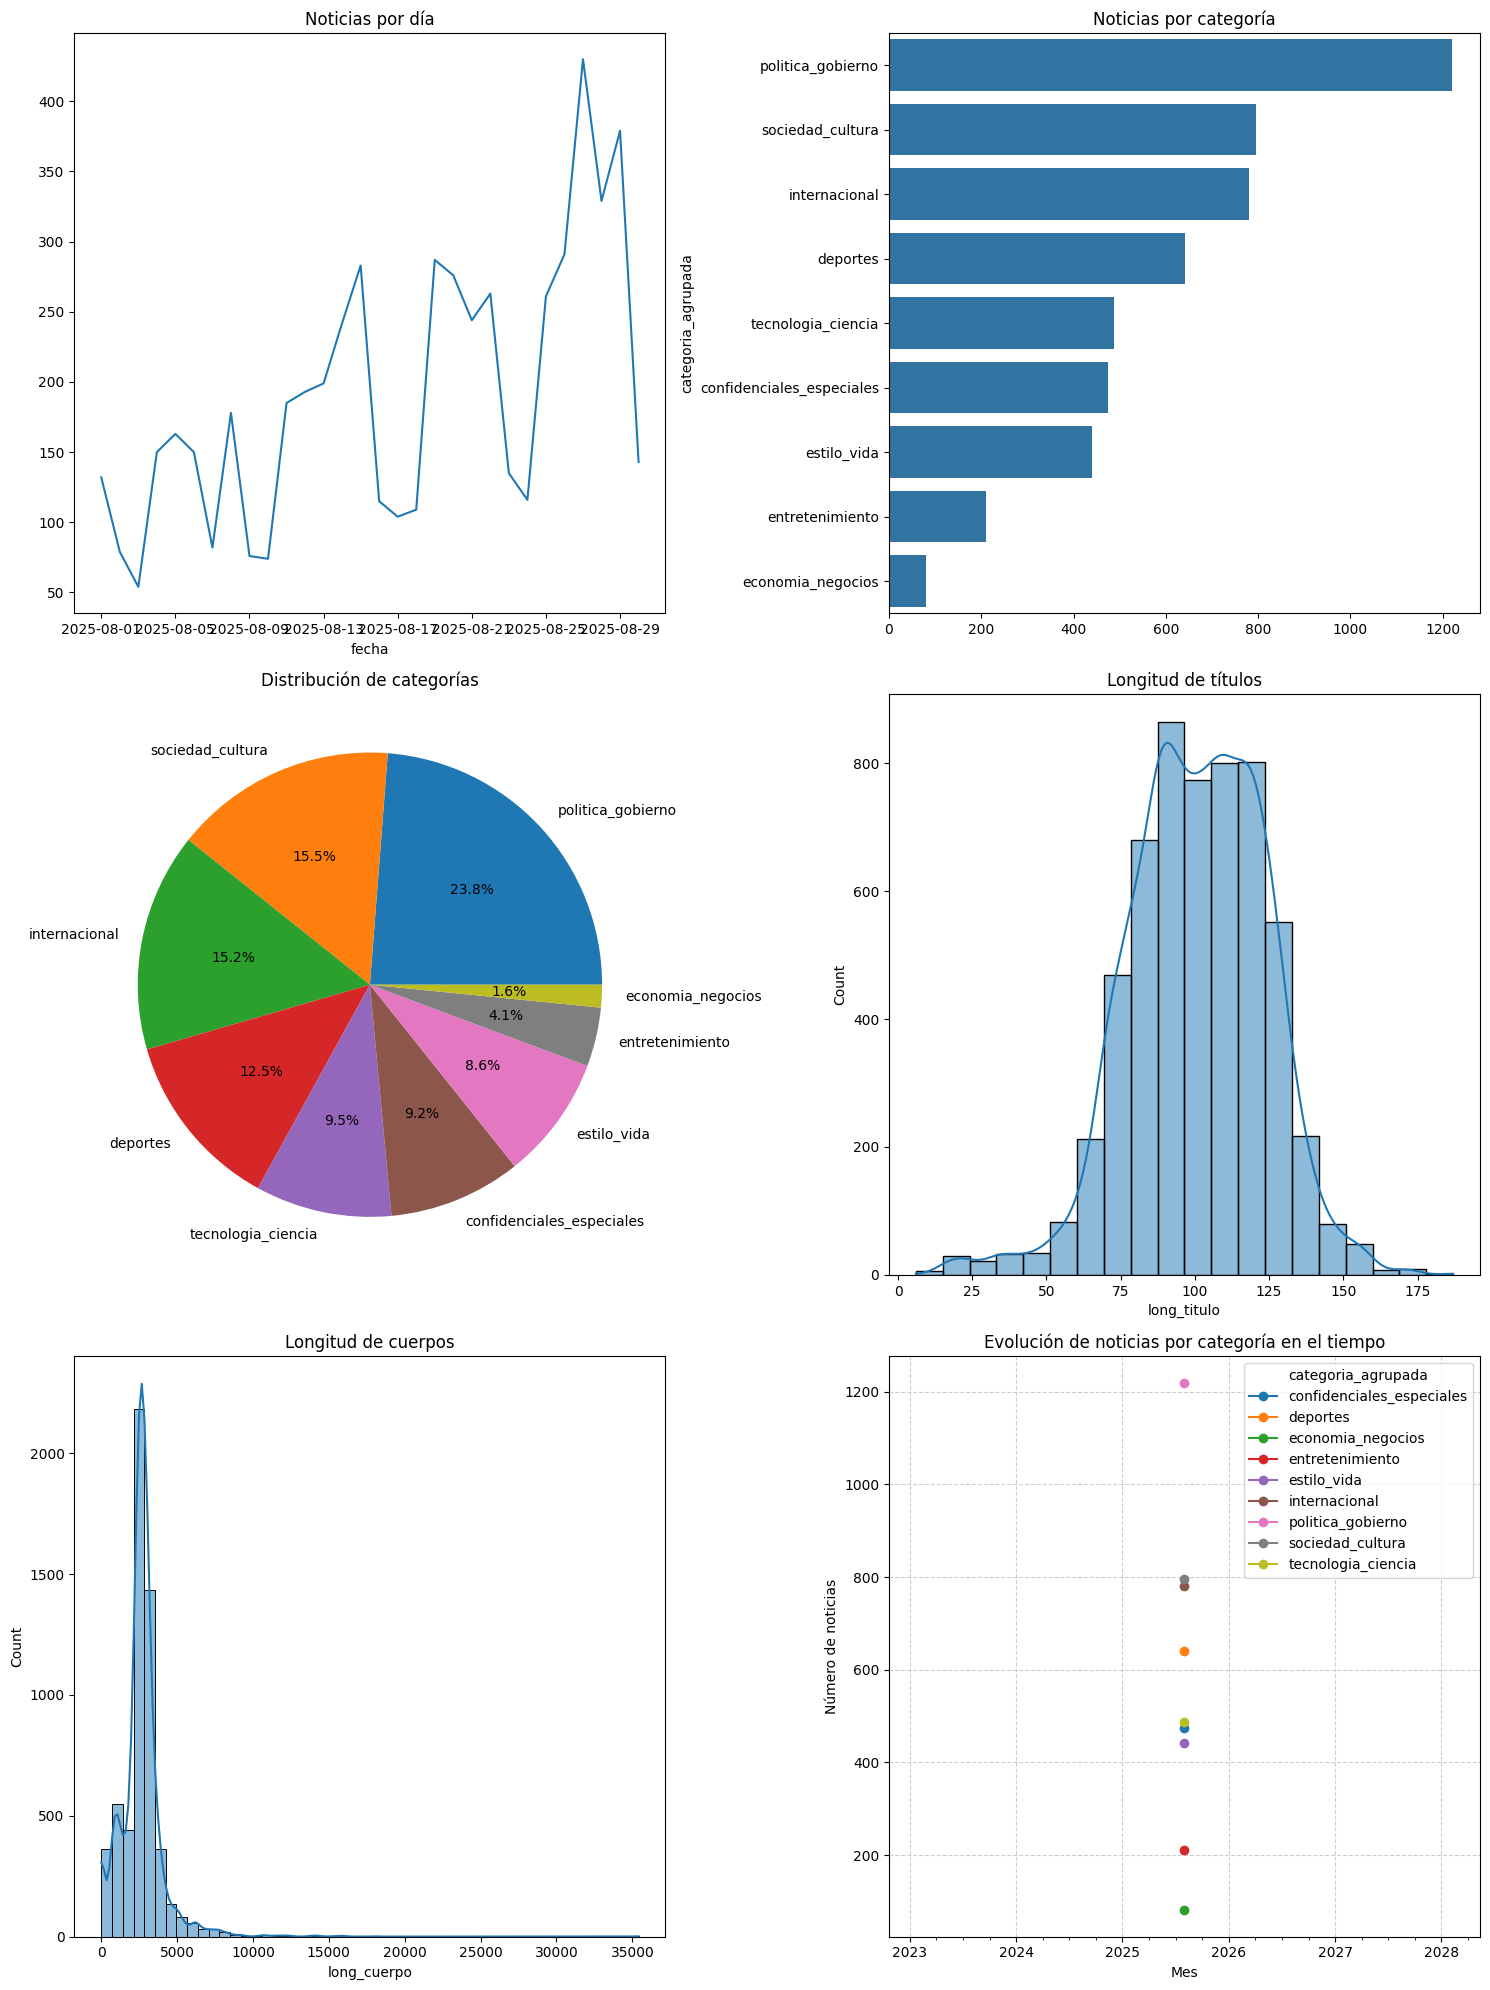

In [ ]:

corpus_completo.columns = corpus_completo.columns.str.lower()
corpus_completo['fecha'] = pd.to_datetime(corpus_completo['fecha'], errors='coerce', utc=True)

# Eliminar filas donde la conversión de fecha falló
corpus_completo.dropna(subset=['fecha'], inplace=True)


# Noticias por día
noticias_por_dia = corpus_completo.groupby(corpus_completo["fecha"].dt.date).size()
# Categorías
conteo_categorias = corpus_completo["categoria_agrupada"].value_counts()
# Longitud de textos
corpus_completo["long_titulo"] = corpus_completo["titulo"].apply(lambda x: len(str(x)))
corpus_completo["long_cuerpo"] = corpus_completo["cuerpo"].apply(lambda x: len(str(x)))
# Evolución mensual
corpus_completo["mes"] = corpus_completo["fecha"].dt.to_period("M")
conteo_mes_cat = corpus_completo.groupby(["mes", "categoria_agrupada"]).size().unstack(fill_value=0)

# --- Crear figura con subplots de 2x3 ---
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten()  # Convertir a lista para acceder fácil

# 1. Noticias por día
noticias_por_dia.plot(kind="line", ax=axes[0], title="Noticias por día")

# 2. Noticias por categoría (barplot)
sns.barplot(x=conteo_categorias.values, y=conteo_categorias.index, ax=axes[1])
axes[1].set_title("Noticias por categoría")

# 3. Noticias por categoría (pie)
conteo_categorias.plot(kind="pie", autopct="%1.1f%%", ax=axes[2])
axes[2].set_ylabel("")  # Quitar etiqueta extra
axes[2].set_title("Distribución de categorías")

# 4. Distribución longitud títulos
sns.histplot(corpus_completo["long_titulo"], bins=20, kde=True, ax=axes[3])
axes[3].set_title("Longitud de títulos")

# 5. Distribución longitud cuerpos
sns.histplot(corpus_completo["long_cuerpo"], bins=50, kde=True, ax=axes[4])
axes[4].set_title("Longitud de cuerpos")

# 6. Evolución mensual de categorías
conteo_mes_cat.plot(kind="line", marker="o", ax=axes[5])
axes[5].set_title("Evolución de noticias por categoría en el tiempo")
axes[5].set_xlabel("Mes")
axes[5].set_ylabel("Número de noticias")
axes[5].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## Interpretación

1. **Noticias por día (arriba izquierda)**  
   Se observa una alta variabilidad en el número de publicaciones diarias durante agosto de 2025. Hay días con menos de 100 noticias y picos que superan las 400, lo que indica posibles eventos coyunturales que dispararon la producción informativa.

2. **Noticias por categoría (arriba derecha)**  
   La categoría con mayor volumen es **política_gobierno**, con más de 1.200 artículos, seguida de **sociedad_cultura** e **internacional**. Esto refleja que los medios priorizan temas políticos y sociales sobre económicos o regionales, que tienen menor representación.

3. **Distribución de categorías (centro izquierda)**  
   En términos relativos, la política concentra casi **una cuarta parte (23.8%)** de las noticias. Luego, sociedad y cultura (15.5%) e internacional (15.2%) también ocupan un lugar importante, mientras que áreas como economía y negocios apenas alcanzan un 1.6%. La distribución confirma el sesgo hacia lo político y lo social.

4. **Longitud de títulos (centro derecha)**  
   La mayoría de títulos se encuentra entre **80 y 120 caracteres**, mostrando un patrón relativamente uniforme y con pocas variaciones extremas. Esto refleja cierta homogeneidad en los estilos editoriales de los medios.

5. **Longitud de cuerpos (abajo izquierda)**  
   La distribución es mucho más dispersa: la mayoría de los textos se concentran en menos de **5.000 caracteres**, aunque existen outliers que alcanzan hasta **35.000 caracteres** (probablemente reportajes extensos o especiales). Esto evidencia heterogeneidad en la extensión de las notas.

6. **Evolución de noticias por categoría en el tiempo (abajo derecha)**  
   Aunque los datos corresponden a un único mes, se observa que política, sociedad y cultura, e internacional dominan la producción informativa. Las demás categorías se mantienen mucho más bajas y relativamente estables.  
   Para un análisis más profundo, sería útil extender la serie temporal a varios meses para identificar patrones de largo plazo.

Con esto podemos decir que el corpus evidencia un **fuerte sesgo hacia lo político y lo social**, tanto en volumen absoluto como relativo. Los títulos muestran homogeneidad en su longitud, mientras que los cuerpos presentan alta dispersión. Estos gráficos permiten confirmar que el dataset tiene suficiente variabilidad para entrenar modelos de NLP, pero también reflejan un desbalance de clases (por categoría) que conviene considerar en etapas posteriores de clasificación.

---


## Categorías y Longitudes Promedio


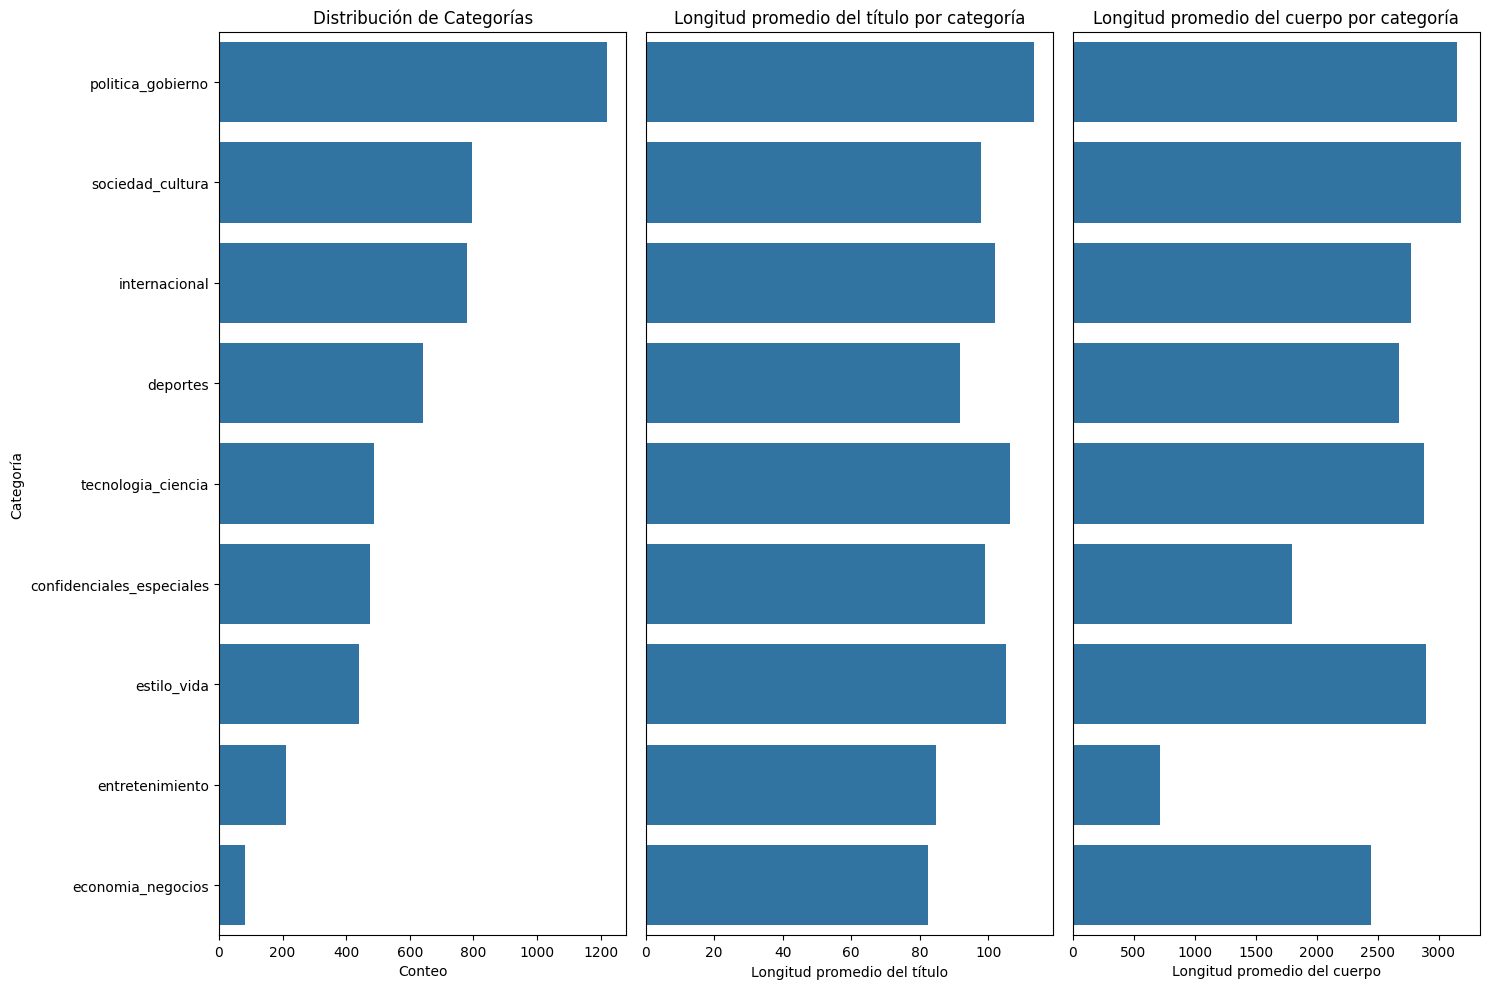

In [ ]:
# --- Código de visualización corregido ---
fig, ax = plt.subplots(1, 3, figsize=(15, 10))

# Obtiene el orden de las categorías para mantener la consistencia
categoria_order = corpus_completo['categoria_agrupada'].value_counts().index

# Gráfico 1: Distribución de categorías
sns.barplot(
    x=corpus_completo['categoria_agrupada'].value_counts(),
    y=categoria_order,
    orient='y',
    ax=ax[0]
)
ax[0].set_xlabel('Conteo')
ax[0].set_ylabel('Categoría')
ax[0].set_title('Distribución de Categorías')

# Gráfico 2: Longitud promedio de los títulos por categoría
sns.barplot(
    x=corpus_completo.groupby('categoria_agrupada')['long_titulo'].mean(),
    y=corpus_completo.groupby('categoria_agrupada')['long_titulo'].mean().index,
    orient='y',
    ax=ax[1],
    order=categoria_order
)
ax[1].set_xlabel('Longitud promedio del título')
ax[1].yaxis.set_visible(False)
ax[1].set_title('Longitud promedio del título por categoría')

# Gráfico 3: Longitud promedio del cuerpo por categoría
sns.barplot(
    x=corpus_completo.groupby('categoria_agrupada')['long_cuerpo'].mean(),
    y=corpus_completo.groupby('categoria_agrupada')['long_cuerpo'].mean().index,
    orient='y',
    ax=ax[2],
    order=categoria_order
)
ax[2].set_xlabel('Longitud promedio del cuerpo')
ax[2].yaxis.set_visible(False)
ax[2].set_title('Longitud promedio del cuerpo por categoría')

plt.tight_layout()
plt.show()


1. **Distribución de categorías (gráfico izquierdo)**  
   La categoría **política_gobierno** vuelve a ser la dominante, con más de 1.200 noticias, seguida por sociedad_cultura, internacional y deportes. En contraste, economía_negocios y entretenimiento son las categorías menos representadas. Esto confirma un **desequilibrio en el corpus**, lo que es relevante para cualquier tarea de clasificación supervisada.

2. **Longitud promedio del título por categoría (gráfico central)**  
   En general, los títulos mantienen una extensión similar (entre **80 y 100 caracteres en promedio**), con ligeras variaciones:

   - **tecnología_ciencia** y **internacional** tienden a tener títulos un poco más largos.
   - **entretenimiento** y **economía_negocios** muestran títulos más cortos en promedio.  
     Esto refleja diferencias en el estilo editorial según la temática.

3. **Longitud promedio del cuerpo por categoría (gráfico derecho)**  
   Aquí se observa mayor heterogeneidad:
   - **sociedad_cultura** y **economía_negocios** poseen los artículos más extensos (cerca de 3.000 caracteres en promedio), lo que sugiere reportajes más detallados.
   - **entretenimiento** produce textos mucho más cortos (menos de 1.000 caracteres en promedio), lo que indica notas breves.
   - Política, internacional y deportes tienen extensiones intermedias (entre 2.000 y 2.500 caracteres).

Estos gráficos permiten ver que, aunque los **títulos son relativamente homogéneos en su longitud**, los **cuerpos presentan variaciones importantes según la categoría**. Además, el **desequilibrio en el número de noticias por categoría** refuerza la necesidad de considerar técnicas de balanceo de clases para tareas de modelado en NLP.


---

## Distribución de noticias en _El Espectador_


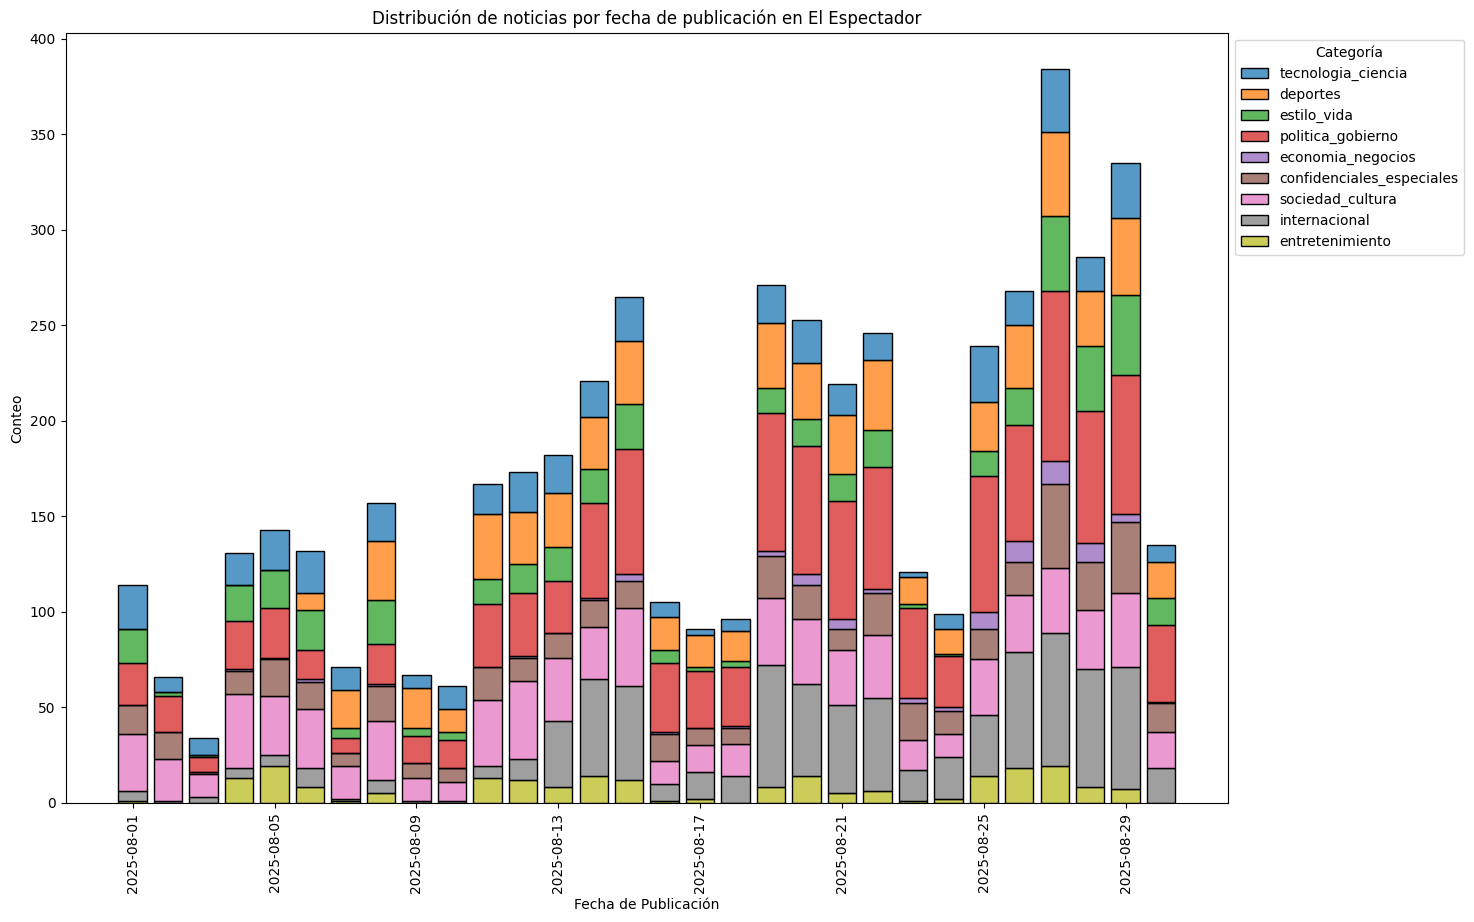

In [ ]:
# --- Código de visualización corregido ---
plt.figure(figsize=(15, 10))

ax = sns.histplot(
    data=corpus_completo,
    x=corpus_completo['fecha'].dt.date, # Agrupado por día para la visualización
    hue='categoria_agrupada',
    multiple="stack",
    shrink=.8,
)

sns.move_legend(
    ax, "upper left",
    bbox_to_anchor=(1, 1), ncol=1, title='Categoría', frameon=True,
)

plt.xlabel('Fecha de Publicación')
plt.xticks(rotation=90)
plt.ylabel('Conteo')
plt.title('Distribución de noticias por fecha de publicación en El Espectador')
plt.show()


El gráfico muestra la evolución diaria del número de publicaciones en _El Espectador_, desagregadas por categoría:

1. **Variabilidad en el volumen diario**  
   La cantidad de noticias publicadas varía significativamente: algunos días se producen menos de 50 artículos, mientras que en picos como el **27 y 28 de agosto** se superan las 350 publicaciones. Esto sugiere momentos coyunturales que aumentaron la producción informativa.

2. **Categorías predominantes**

   - **Política_gobierno** es la categoría más frecuente a lo largo de todo el mes, ocupando gran parte de las barras en los días con mayor producción.
   - **Sociedad_cultura** e **internacional** también tienen presencia constante, aunque en menor magnitud.
   - **Economía_negocios** y **entretenimiento** son claramente marginales, con muy poca representación.

3. **Diversificación temática**  
   A pesar de la dominancia de la política, en casi todos los días se observa una mezcla de categorías. Esto refleja la **pluralidad temática** de la agenda mediática del diario, aunque con un sesgo hacia lo político.

_El Espectador_ mantiene un flujo informativo altamente volátil y concentrado en **temas políticos**, que se intensifican en momentos específicos del mes. Las demás categorías funcionan como un complemento, asegurando cierta diversidad, pero con un peso mucho menor.


---

## Noticias por día en todo el corpus


/tmp/ipython-input-517050200.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


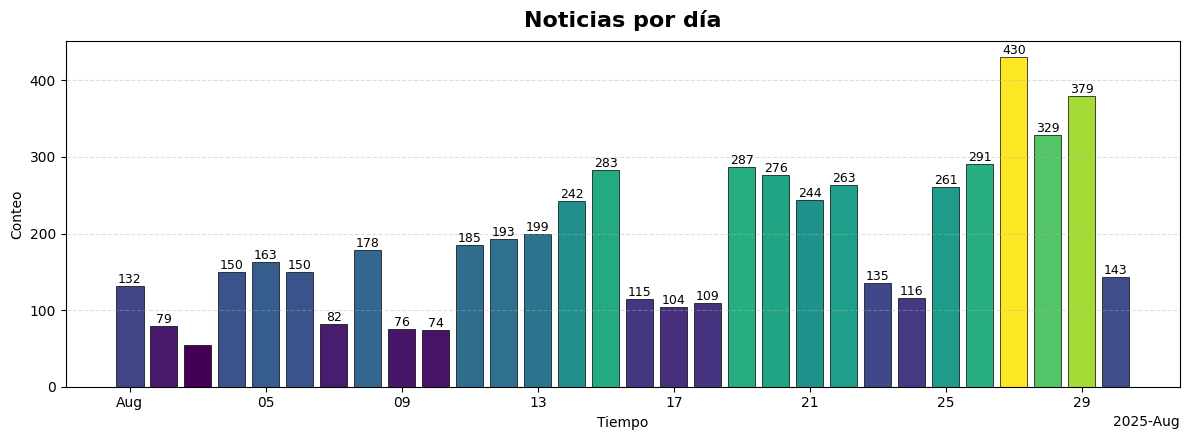

In [ ]:
import matplotlib.dates as mdates
import matplotlib.cm as cm # Import cm

corpus_completo['fecha'] = pd.to_datetime(corpus_completo['fecha'], errors='coerce', utc=True).dt.tz_localize(None)


def conteos_por_intervalo(df, freq='W'):

    s = (df.set_index('fecha')
         .sort_index().resample(freq).size().rename('n'))
    return s.reset_index()


def plot_barras_temporales(df_count, titulo="Eventos por intervalo"):
    """
    Genera un gráfico de barras temporales con colores normalizados por intensidad.

    El gráfico representa en el eje X las fechas y en el eje Y los conteos de eventos.
    La intensidad del color de cada barra se ajusta de acuerdo con la normalización
    de los valores, usando el mapa de color "viridis". Además, se muestran etiquetas
    en las barras que superan un umbral mínimo de relevancia.

    Args:
        df_count (pandas.DataFrame): DataFrame con al menos dos columnas:
            - 'fecha' (datetime): eje X, intervalo temporal.
            - 'n' (int): eje Y, número de eventos en cada fecha.
        titulo (str, optional): Título del gráfico. Por defecto "Eventos por intervalo".

    Returns:
        None: Muestra el gráfico directamente con `matplotlib.pyplot.show()`.

    Notas:
        - Se utiliza un umbral (`thresh`) igual al máximo entre 5 y el 15% del valor
          máximo de `y`, para decidir qué barras mostrar con etiquetas numéricas.
        - La escala de colores se normaliza entre el valor mínimo y máximo de `y`.
        - Se usan `matplotlib.dates` para el formateo conciso de fechas.
    """
    x = df_count['fecha']
    y = df_count['n'].astype(int)

    norm = (y - y.min()) / (y.max() - y.min() + 1e-9)
    cmap = cm.get_cmap("viridis")
    colors = cmap(norm)

    plt.figure(figsize=(12, 4.5))
    plt.bar(x, y, color=colors, edgecolor="black", linewidth=0.5)

    ax = plt.gca()
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    plt.title(titulo, fontsize=16, fontweight='bold', pad=10)
    plt.xlabel("Tiempo")
    plt.ylabel("Conteo")

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    ymax = y.max()
    thresh = max(5, int(0.15 * ymax))
    for xi, yi in zip(x, y):
        if yi >= thresh:
            plt.text(xi, yi, f"{yi:,}".replace(',', '.'), ha='center', va='bottom', fontsize=9, color="black")

    plt.tight_layout()
    plt.show()


def plot_linea_area(df_count, titulo="Serie temporal de eventos", rol_window=4):
    """
    Genera un gráfico de línea con área sombreada, media móvil y media global.

    El gráfico representa la evolución temporal de eventos, mostrando la serie original,
    un área sombreada bajo la curva, una línea de media móvil y una línea horizontal
    con la media global. Además, resalta los tres valores más altos de la serie.

    Args:
        df_count (pandas.DataFrame): DataFrame con al menos dos columnas:
            - 'fecha' (datetime): eje X, intervalo temporal.
            - 'n' (float o int): eje Y, número de eventos en cada fecha.
        titulo (str, optional): Título del gráfico. Por defecto "Serie temporal de eventos".
        rol_window (int, optional): Tamaño de la ventana para la media móvil.
            Por defecto 4.

    Returns:
        None: Muestra el gráfico directamente con `matplotlib.pyplot.show()`.

    Notas:
        - El área bajo la serie se muestra con un tono azul claro.
        - La línea de media móvil se dibuja con estilo punteado.
        - La media global se representa como línea horizontal roja.
        - Se resaltan con puntos y etiquetas los tres valores más altos de la serie.
        - Se usan `matplotlib.dates` para el formateo conciso de fechas.
    """
    x = df_count['fecha']
    y = df_count['n'].astype(float)

    media = y.mean()
    rol = y.rolling(rol_window, min_periods=max(1, rol_window//2)).mean()

    line_color = "#1f77b4"
    rol_color = "#ff7f0e"
    area_color = cm.get_cmap("Blues")(0.3)

    plt.figure(figsize=(12, 4.8))
    plt.fill_between(x, y, color=area_color, alpha=0.3)
    plt.plot(x, y, color=line_color, linewidth=2, marker='o', markersize=4, label="Conteo")
    plt.plot(x, rol, color=rol_color, linewidth=2, linestyle='--', label=f"Media móvil ({rol_window})")
    plt.axhline(media, linestyle=':', linewidth=2, color="red", alpha=0.7,label=f"Media = {media:.0f}")

    ax = plt.gca()
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    plt.title(titulo, fontsize=16, fontweight='bold', pad=10)
    plt.xlabel("Tiempo")
    plt.ylabel("Conteo")
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.legend(frameon=False)
    top_idx = np.argsort(y.values)[-3:]
    for i in top_idx:
        plt.scatter(x.iloc[i], y.iloc[i], color=line_color, s=60, zorder=3)
        plt.text(x.iloc[i], y.iloc[i] * 1.02,
                 f"{int(y.iloc[i]):,}".replace(',', '.'),
                 va='bottom', ha='center', fontsize=9, fontweight='bold', color=line_color)

    plt.tight_layout()
    plt.show()

diario = conteos_por_intervalo(corpus_completo, freq='D')
plot_barras_temporales(diario, titulo="Noticias por día")

El gráfico muestra la evolución del volumen de publicaciones **de todo el corpus combinado** (El Espectador, Semana y El Colombiano) durante agosto de 2025:

1. **Crecimiento progresivo en el mes**  
   Durante la primera semana los volúmenes diarios rondan entre **70 y 180 noticias**, pero a partir de la segunda semana se observa un aumento sostenido, llegando a superar las **250 publicaciones por día**.

2. **Picos de publicación**

   - El **27 de agosto** se alcanzó el máximo con **430 noticias**, el día de mayor actividad informativa del mes.
   - Otros picos relevantes ocurrieron entre el **19 y el 21 de agosto**, con más de 280 noticias diarias.
   - La recta final del mes (28 y 29 de agosto) también presenta altos volúmenes, cercanos a las 380 publicaciones.

3. **Variabilidad y concentración**  
   El flujo no es uniforme: los medios parecen intensificar la producción en torno a fechas específicas, probablemente asociadas a coyunturas políticas, sociales o internacionales que dominaron la agenda noticiosa.

El corpus revela un **incremento progresivo en la actividad informativa** durante agosto de 2025, con picos notables hacia la tercera y cuarta semana del mes. Esto confirma que los medios tienden a reaccionar a coyunturas específicas, generando concentraciones de noticias que son clave para el análisis de tendencias y para la posterior aplicación de técnicas de NLP.


---

## Noticias por semana en todo el corpus (agosto 2025)


/tmp/ipython-input-517050200.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  area_color = cm.get_cmap("Blues")(0.3)


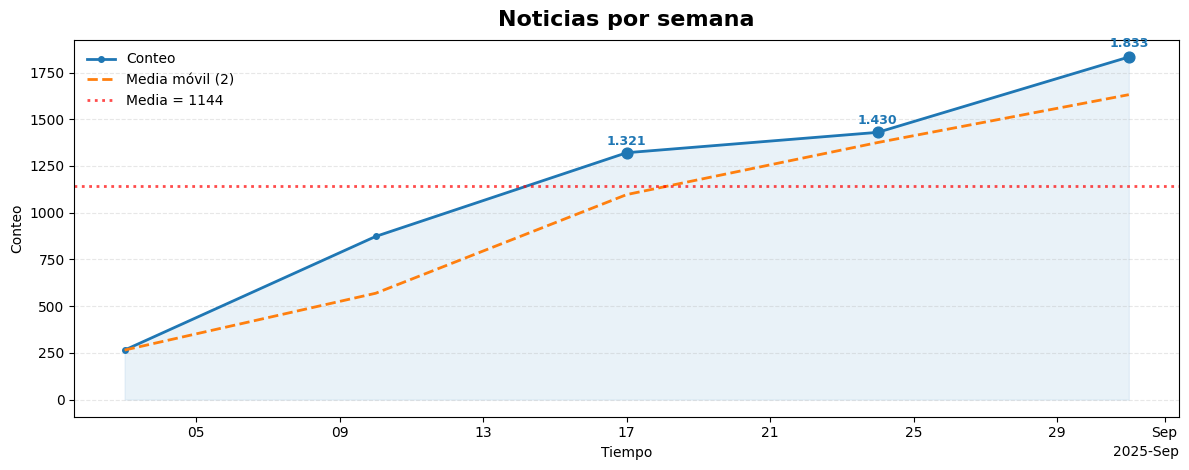

In [ ]:
semanal = conteos_por_intervalo(corpus_completo, freq='W')
plot_linea_area(semanal, titulo="Noticias por semana", rol_window=2)

El gráfico refleja una **tendencia creciente** en la cantidad de noticias recopiladas durante agosto de 2025. Sin embargo, es importante aclarar que este comportamiento no solo obedece a la dinámica real de producción informativa de los medios, sino también a factores técnicos del **proceso de scraping**:

1. **Sesgo por fechas del scraping**  
   El scraping se concentró con mayor intensidad en los **últimos días del mes**, lo que explica en parte por qué las semanas finales muestran un volumen mucho mayor de noticias. Es posible que no todas las noticias de la primera parte del mes hayan sido recolectadas con la misma exhaustividad.

2. **Tendencia observada**

   - Semana 1: ~250 noticias.
   - Semana 2: ~880 noticias.
   - Semana 3: ~1.321 noticias.
   - Semana 4: ~1.430 noticias.
   - Semana 5: ~1.833 noticias.

   La última semana destaca con un pico de publicaciones, pero este crecimiento puede estar amplificado por la cobertura del scraping.

3. **Media y media móvil**
   - **Media general:** 1.144 noticias por semana.
   - **Media móvil (2 semanas):** confirma la tendencia ascendente, aunque condicionada por la mayor recolección hacia el final.

El corpus muestra un **incremento progresivo en el número de noticias por semana**, pero este aumento no necesariamente refleja únicamente la actividad de los medios, sino también la **intensidad desigual del scraping**, que fue más exhaustivo en los últimos días del mes.


---

## Estadísticas descriptivas de la longitud de los textos


In [ ]:
corpus['len_char'] = corpus['cuerpo'].astype(str).str.len()
corpus['len_word'] = corpus['cuerpo'].astype(str).str.split().str.len()

print("=== Longitud en caracteres ===")
print(corpus['len_char'].describe())

print("\n=== Longitud en palabras ===")
print(corpus['len_word'].describe())

=== Longitud en caracteres ===
count     6302.000000
mean      2731.850682
std       1562.394941
min          3.000000
25%       2190.000000
50%       2646.500000
75%       3124.750000
max      35411.000000
Name: len_char, dtype: float64

=== Longitud en palabras ===
count    6302.000000
mean      442.516820
std       254.155198
min         1.000000
25%       353.000000
50%       427.000000
75%       504.000000
max      5573.000000
Name: len_word, dtype: float64


La distribución de longitudes muestra que la mayoría de las noticias se concentran en un rango relativamente acotado: alrededor de **2.600–2.700 caracteres**, equivalentes a unas **420 palabras**. Esto corresponde al estándar de una nota periodística breve o mediana, lo que da al corpus una base homogénea para el análisis.

El promedio resulta apenas mayor que la mediana, lo que indica una **asimetría positiva moderada**: existen artículos mucho más extensos que empujan la media hacia arriba, pero la gran mayoría se concentra en el rango intercuartílico (≈2.200–3.100 caracteres o 350–500 palabras).

En los extremos aparecen **outliers** relevantes. Por un lado, piezas muy largas (hasta 35.000 caracteres o 5.500 palabras) que probablemente corresponden a reportajes especiales. Por otro, notas extremadamente cortas (menos de 10 caracteres o una sola palabra), que parecen errores de scraping o registros incompletos.

Estas observaciones sugieren dos pasos metodológicos: (1) **filtrar las noticias mínimas** que no aportan información sustantiva (<100–150 palabras), y (2) decidir si conviene **recortar o tratar aparte** los textos más largos para evitar que distorsionen los análisis posteriores o el entrenamiento de modelos de NLP.


---

## Nube de palabras (sin preprocesamiento)


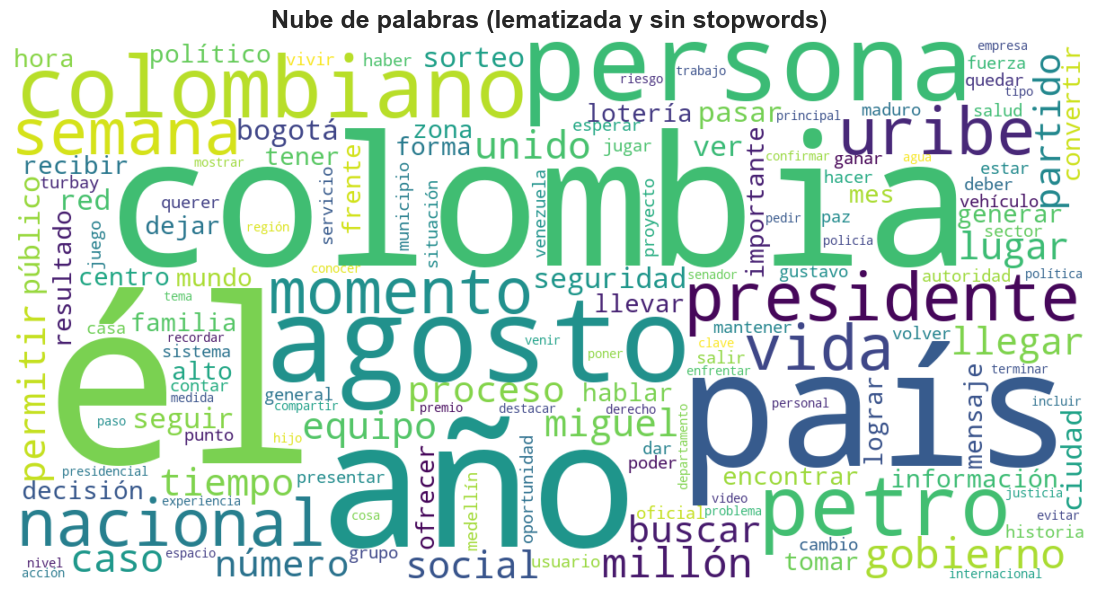

In [ ]:
from wordcloud import WordCloud
from spacy.attrs import IS_STOP, IS_PUNCT, IS_ALPHA, LEMMA

nlp = spacy.load("es_core_news_sm")

def lemmas_filtrados_docs(texts, batch_size=512, n_process=4):
    """
    Extrae y filtra los lemas de una lista de textos usando spaCy.

    La función procesa los textos con el pipeline de spaCy, eliminando tokens
    que sean stopwords o signos de puntuación, y conservando únicamente tokens
    alfabéticos. Devuelve una lista con los lemas en minúscula.

    Args:
        texts (list of str): Lista de documentos en formato texto.
        batch_size (int, optional): Tamaño de lote para el procesamiento por spaCy.
            Por defecto 512.
        n_process (int, optional): Número de procesos en paralelo a usar en spaCy.
            Por defecto 4.

    Returns:
        list of str: Lista de lemas filtrados en minúscula.

    Notas:
        - Se deshabilitan los componentes `ner` y `parser` para mejorar la eficiencia.
        - Se usan los atributos de spaCy `IS_STOP`, `IS_PUNCT`, `IS_ALPHA` y `LEMMA`.
        - Si no hay tokens válidos, se devuelve una lista vacía.
    """
    vocab_strings = nlp.vocab.strings
    lemas_ids_all = []

    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process,disable=["ner", "parser"]):

        arr = doc.to_array([IS_STOP, IS_PUNCT, IS_ALPHA, LEMMA])
        mask = (~arr[:,0].astype(bool)) & (~arr[:,1].astype(bool)) & (arr[:,2].astype(bool))
        lemas_ids_all.append(arr[mask, 3])

    lemas_ids_all = np.concatenate(lemas_ids_all) if lemas_ids_all else np.array([], dtype=np.int64)
    return [vocab_strings[lem_id].lower() for lem_id in lemas_ids_all]


texts = corpus['cuerpo'].dropna().astype(str)
tokens_filtrados = lemmas_filtrados_docs(texts)
texto_filtrado = " ".join(tokens_filtrados)

wordcloud = WordCloud(width=1200, height=600,background_color='white',max_words=150,
                      colormap='viridis',collocations=False).generate(texto_filtrado)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras (lematizada y sin stopwords)", fontsize=18, fontweight='bold', pad=10)
plt.show()

Esta nube se generó **antes de cualquier preprocesamiento**: **no** se eliminaron _stopwords_ ni se aplicó **lematización**. Por eso aparecen términos muy frecuentes pero poco informativos como “el”, así como marcadores temporales (“año”, “agosto”). La presencia de nombres propios mezclados con palabras funcionales confirma que aún falta limpiar el texto (remover _stopwords_, normalizar/lematizar, manejar mayúsculas y acentos, y tratar entidades) antes de usarlo en análisis o modelos de NLP.


---

## Analisis de Bi-Gramas y Tri-Gramas del corpus


In [ ]:
from collections import Counter

docs = list(nlp.pipe(corpus['cuerpo'].dropna().astype(str), disable=["ner", "parser"]))

tokens_filtrados = []
for doc in docs:
    for token in doc:
        if not token.is_stop and not token.is_punct and token.is_alpha:
            tokens_filtrados.append(token.lemma_.lower())

bigramas = Counter(zip(tokens_filtrados, tokens_filtrados[1:]))
trigramas = Counter(zip(tokens_filtrados, tokens_filtrados[1:], tokens_filtrados[2:]))


print("=== Top 15 Bigramas ===")
for (w1, w2), c in bigramas.most_common(15):
    print(f"{w1} {w2}: {c}")

print("\n=== Top 15 Trigramas ===")
for (w1, w2, w3), c in trigramas.most_common(15):
    print(f"{w1} {w2} {w3}: {c}")

=== Top 15 Bigramas ===
miguel uribe: 1457
gustavo petro: 1335
red social: 1244
uribe turbay: 1173
sorteo lotería: 1003
presidente gustavo: 757
inteligencia artificial: 630
llevar cabo: 616
centro democrático: 570
álvaro uribe: 548
millón pesos: 530
nicolás maduro: 522
precandidato presidencial: 492
número suerte: 438
uribe londoño: 411

=== Top 15 Trigramas ===
miguel uribe turbay: 955
presidente gustavo petro: 753
expresidente álvaro uribe: 301
agosto llevar cabo: 287
álvaro uribe vélez: 270
llevar cabo sorteo: 268
miguel uribe londoño: 256
cabo sorteo lotería: 239
ganador sorteo lotería: 225
ofrecer posibilidad ganar: 217
ganar premio millonario: 215
posibilidad ganar premio: 215
sorteo transmitir vivo: 213
resultado consultar página: 212
premio millonario modalidad: 211


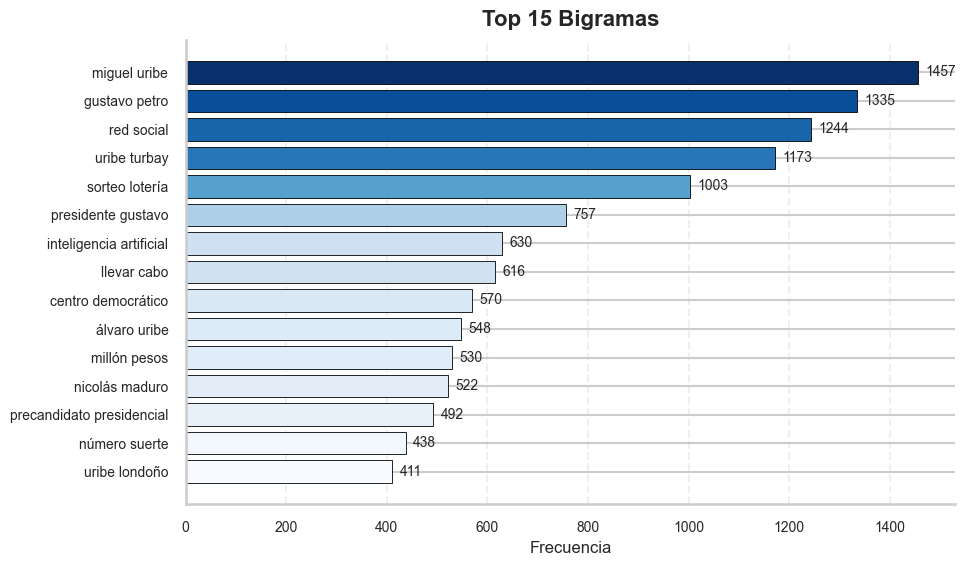

In [ ]:
top_bigrams = bigramas.most_common(15)
labels = [f"{w1} {w2}" for (w1, w2), _ in top_bigrams]
counts = np.array([c for _, c in top_bigrams])

norm = (counts - counts.min()) / (counts.max() - counts.min() + 1e-9)
colors = plt.colormaps.get_cmap("Blues")(norm)

plt.figure(figsize=(10, 6))
bars = plt.barh(labels[::-1], counts[::-1], color=colors[::-1], edgecolor="black", linewidth=0.6)
plt.title("Top 15 Bigramas", fontsize=16, fontweight="bold", pad=10)
plt.xlabel("Frecuencia", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3)

for bar, value in zip(bars, counts[::-1]):
    plt.text(bar.get_width() + counts.max()*0.01,
             bar.get_y() + bar.get_height()/2,
             str(value),
             va='center', fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

El análisis de bigramas muestra las combinaciones de palabras más frecuentes en las noticias. Los resultados reflejan tanto la **agenda política** como ciertos **temas sociales y de coyuntura**:

- Destacan actores políticos: _“miguel uribe”_, _“gustavo petro”_, _“álvaro uribe”_, _“uribe turbay”_, _“uribe londoño”_. Esto confirma que gran parte del contenido noticioso está centrado en la política nacional y figuras públicas.
- Aparecen también **instituciones y partidos**: _“centro democrático”_, _“precandidato presidencial”_, que subrayan la cobertura electoral y partidista.
- Existen temas **no políticos pero recurrentes** como _“red social”_, _“inteligencia artificial”_ o _“sorteo lotería”_, lo que indica diversidad en la agenda mediática.
- Otros términos como _“millón pesos”_ o _“número suerte”_ reflejan noticias de economía cotidiana o secciones de entretenimiento.

Los bigramas confirman que el corpus está fuertemente sesgado hacia la **política nacional** (especialmente en torno a figuras como Petro y Uribe), aunque también aparecen tópicos variados (tecnología, loterías, redes sociales). Esto será clave al entrenar modelos de NLP, pues los bigramas dominantes podrían influir en la clasificación y es necesario tener en cuenta este **desequilibrio temático**.


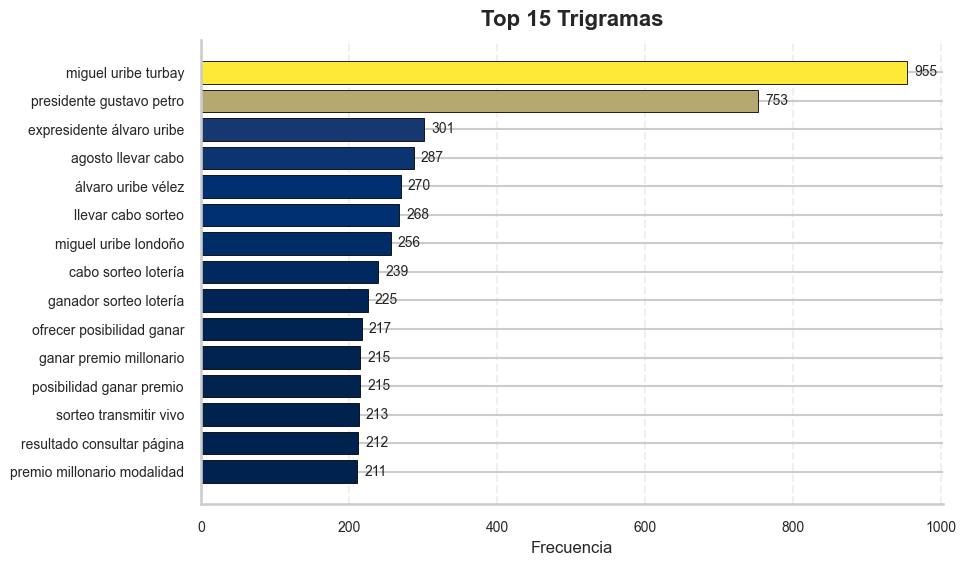

In [ ]:
top_trigrams = trigramas.most_common(15)
labels = [f"{w1} {w2} {w3}" for (w1, w2, w3), _ in top_trigrams]
counts = np.array([c for _, c in top_trigrams])
norm = (counts - counts.min()) / (counts.max() - counts.min() + 1e-9)
colors = plt.colormaps.get_cmap("cividis")(norm)

plt.figure(figsize=(10, 6))
bars = plt.barh(labels[::-1], counts[::-1], color=colors[::-1], edgecolor="black", linewidth=0.6)
plt.title("Top 15 Trigramas", fontsize=16, fontweight="bold", pad=10)
plt.xlabel("Frecuencia", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3)

for bar, value in zip(bars, counts[::-1]):
    plt.text(bar.get_width() + counts.max()*0.01,
             bar.get_y() + bar.get_height()/2,
             str(value),
             va='center', fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

El análisis de trigramas permite observar combinaciones más específicas de términos, lo que da una idea más clara de los temas dominantes en el corpus:

- **Política nacional**: aparecen de forma recurrente nombres de figuras políticas y cargos públicos como _“miguel uribe turbay”_, _“presidente gustavo petro”_, _“expresidente álvaro uribe”_ y _“álvaro uribe vélez”_. Esto confirma que la agenda política es el eje central de gran parte de las noticias.
- **Eventos y temporalidad**: términos como _“agosto llevar cabo”_ muestran cómo el mes analizado se refleja en las expresiones frecuentes, reforzando la necesidad de filtrar marcadores temporales en el preprocesamiento.
- **Sorteos y loterías**: expresiones como _“llevar cabo sorteo”_, _“cabo sorteo lotería”_, _“ganador sorteo lotería”_ o _“premio millonario modalidad”_ sugieren que los contenidos de entretenimiento y azar tienen un peso significativo en el corpus.
- **Otros patrones**: frases como _“ofrecer posibilidad ganar”_ o _“sorteo transmitir vivo”_ se relacionan con publicidad o notas de servicios, evidenciando la diversidad temática más allá de lo político.

Los trigramas confirman dos grandes ejes en el corpus:

1. La **política colombiana**, centrada en actores y partidos relevantes.
2. Los **sorteos y contenidos de azar**, que aparecen con frecuencia en los titulares y cuerpos.

Este hallazgo refleja la mezcla de **temas de alta relevancia nacional** con **noticias de entretenimiento masivo**, lo que debe tenerse en cuenta al diseñar tareas de clasificación o detección de tópicos.


---

## 3. **Preprocecamiento y Extraccion de Caracteristicas con Embeddings**


### 3.1 Preprocesamiento


In [ ]:
def preprocess_text_column(df,input_col,output_col = "texto_tfidf",
    spacy_model = "es_core_news_sm",
    remove_accents = True,remove_numbers = True,
    remove_punct = True,remove_stopwords = True,
    min_token_len = 2,batch_size = 256,n_process = 1, return_tokens = False):
    """
    Preprocesa una columna de texto en español con limpieza regex, normalización opcional
    de acentos y lematización con spaCy, filtrando tokens según reglas configurables.

    El flujo incluye: (1) limpieza básica (URLs, emails, @menciones, #hashtags, símbolos
    de moneda, caracteres no alfanuméricos), (2) lowercasing, (3) normalización opcional
    de acentos, (4) lematización y filtrado (stopwords, signos, números y longitud mínima).
    Devuelve una nueva columna con tokens listos para TF-IDF (string espacio-separado) o,
    si se especifica, una lista de tokens.

    Args:
        df (pandas.DataFrame): DataFrame de entrada que contiene la columna de texto crudo.
        input_col (str): Nombre de la columna con el texto crudo a procesar.
        output_col (str, optional): Nombre de la nueva columna con el texto procesado.
            Por defecto "texto_tfidf".
        spacy_model (str, optional): Nombre del modelo spaCy a cargar (p. ej.,
            "es_core_news_sm", "es_core_news_md"). Por defecto "es_core_news_sm".
        remove_accents (bool, optional): Si True, normaliza acentos/tildes con `unidecode`.
            Por defecto True.
        remove_numbers (bool, optional): Si True, elimina tokens numéricos. Por defecto True.
        remove_punct (bool, optional): Si True, elimina signos de puntuación/espacios/citas.
            Por defecto True.
        remove_stopwords (bool, optional): Si True, filtra stopwords de spaCy. Por defecto True.
        min_token_len (int, optional): Longitud mínima de lema para conservar el token.
            Por defecto 2.
        batch_size (int, optional): Tamaño de lote para `nlp.pipe`. Por defecto 256.
        n_process (int, optional): Número de procesos en paralelo para spaCy. Por defecto 1.
        return_tokens (bool, optional): Si True, `output_col` contendrá listas de tokens; si
            False, contendrá una cadena con tokens separados por espacio. Por defecto False.

    Returns:
        pandas.DataFrame: Copia de `df` con la columna `output_col` añadida, conteniendo
        texto procesado (string o lista de tokens según `return_tokens`).

    Notas:
        - La limpieza regex elimina URLs, emails, menciones, hashtags, símbolos de moneda y
          caracteres no alfanuméricos básicos (manteniendo letras y dígitos).
        - `remove_accents=True` aplica `unidecode`, lo que puede perder distinciones como "ñ".
        - Se usa `lemma_` de spaCy en minúscula; la calidad depende del modelo elegido.
        - `remove_stopwords` usa `nlp.Defaults.stop_words`; ajuste según necesidades.
        - Para datasets grandes, ajuste `batch_size` y `n_process` según su hardware.
        - La función no modifica `df` in place; retorna una copia con la columna añadida.
    """
    # Regex para limpieza previa
    re_url = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
    re_email = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
    re_mention = re.compile(r"(?<!\w)@\w+")
    re_hashtag = re.compile(r"(?<!\w)#\w+")
    re_currency= re.compile(r"[€$£¥₿]")
    re_space = re.compile(r"\s+")
    re_nonbasic = re.compile(r"[^0-9A-Za-zÁÉÍÓÚÜÑáéíóúüñ\s]", flags=re.UNICODE)

    def _clean_text_basic(txt: str):

        if not isinstance(txt, str):
            return ""

        t = txt.strip()
        t = re_url.sub(" ", t)
        t = re_email.sub(" ", t)
        t = re_mention.sub(" ", t)
        t = re_hashtag.sub(" ", t)
        t = re_currency.sub(" ", t)
        t = t.lower()
        t = re_nonbasic.sub(" ", t)
        t = re_space.sub(" ", t).strip()
        return t

    # Normalización de acentos
    def _strip_accents(txt: str) -> str:
        return unidecode(txt) if txt else txt

    # spaCy para lematizar y filtrar
    nlp = spacy.load(spacy_model, disable=["ner"])

    if nlp.max_length < 2_000_000:
        nlp.max_length = 2_000_000

    #stopwords
    stopwords_spacy = nlp.Defaults.stop_words if remove_stopwords else set()

    def _token_ok(tok):
        if remove_punct and (tok.is_punct or tok.is_space or tok.is_quote):
            return False
        if remove_numbers and (tok.like_num or tok.shape_.isdigit()):
            return False
        if remove_stopwords and tok.lemma_ in stopwords_spacy:
            return False
        if len(tok.lemma_) < min_token_len:
            return False
        return True

    # Pipeline
    cleaned = df[input_col].fillna("").map(_clean_text_basic)
    if remove_accents:
        cleaned = cleaned.map(_strip_accents)

    results = []
    for doc in nlp.pipe(cleaned.tolist(), batch_size=batch_size, n_process=n_process):
        toks = [tok.lemma_.lower() for tok in doc if _token_ok(tok)]
        if return_tokens:
            results.append(toks)
        else:
            results.append(" ".join(toks))

    df = df.copy()
    df[output_col] = results
    return df

Para preparar el corpus antes de aplicar técnicas de análisis como **TF-IDF**, se implementó una función de preprocesamiento en Python que combina limpieza con expresiones regulares y lematización con _spaCy_. El pipeline incluye:

1. **Limpieza inicial con regex**

   - Eliminación de URLs, correos electrónicos, menciones (@usuario), hashtags y símbolos de moneda.
   - Conversión a minúsculas y normalización de espacios en blanco.
   - Eliminación de caracteres no alfanuméricos básicos.

2. **Normalización de acentos**

   - Uso de `unidecode` para remover tildes y diacríticos, homogenizando palabras con y sin acento.

3. **Procesamiento lingüístico con spaCy**

   - Tokenización y **lematización**, reduciendo las palabras a su forma base.
   - Filtrado de tokens según reglas:
     - Exclusión de signos de puntuación y espacios.
     - Exclusión de números.
     - Eliminación de _stopwords_ en español.
     - Longitud mínima de 2 caracteres para descartar tokens irrelevantes.

4. **Salida flexible**
   - Los resultados pueden devolverse como lista de tokens o como texto lematizado separado por espacios, listo para vectorización con TF-IDF.

Este preprocesamiento garantiza un corpus **más limpio, normalizado y reducido a información relevante**, lo que mejora la calidad de las representaciones vectoriales y evita el ruido causado por caracteres, palabras vacías o redundancias ortográficas.


In [ ]:
df.shape

(6511, 7)

Después de realizar el proceso de adquisición, limpieza, normalización y preprocesamiento, el corpus quedó conformado por **6.511 noticias**, organizadas en **7 columnas**.

Este resultado refleja la depuración de registros nulos, la estandarización de categorías y la incorporación de la nueva columna de texto procesado para análisis posteriores (ej. TF-IDF, clasificación temática).

En este punto ya se cuenta con un **dataset consolidado y listo para tareas de NLP**, garantizando coherencia en el formato y reducción del ruido textual.


---

### 3.2 Implementación del Embedding


El corpus que armamos contiene **6.511 documentos de noticias** de diferentes periódicos.  
Teniendo este corpus en mente, consideramos que la aproximación más robusta es **TF-IDF con n-grams** (unigramas y bigramas de palabras + n-grams de caracteres), en lugar de una BoW simple.  
Más allá del tamaño del corpus, esta elección se justifica por:

- **Señal vs. ruido:** TF-IDF controla términos poco informativos y realza indicios discriminativos.
- **Captura de contexto corto:** los n-grams recogen colocalizaciones periodísticas clave (“sube tasa”, “alerta sanitaria”, “récord histórico”) que BoW pierde.
- **Robustez léxica:** los n-grams de caracteres mitigan OOV, tildes y variantes (“inflación/Inflación”, “petróleo/petroleo”).
- **Explicabilidad y control de sobreajuste:** con clasificadores lineales (SVM/LogReg) obtenemos pesos interpretables y buena generalización en dominios específicos.
- **Costo/beneficio:** frente a embeddings preentrenados (p. ej., fastText o BERT), TF-IDF+n-grams evita desajustes de dominio y demanda computacional alta, sirviendo como un _baseline_ fuerte y auditable.

Por otro lado, el **análisis de sentimiento** que queremos realizar sobre el corpus puede generar dudas, debido a que se necesitan _embeddings_ para entrenar cualquier modelo "estable" de NLP.  
Es por esto que emplearemos un **modelo preentrenado de análisis de sentimiento** que ya incorpora _embeddings contextuales_ (**BETO** en español).  
Esto nos permite aprovechar representaciones semánticas de alta calidad aprendidas sobre corpus masivos, garantizando mejor cobertura léxica.  
Así, el uso de _embeddings_ queda implícito en la arquitectura del modelo y nos concentramos únicamente en la **etapa de inferencia con BETO**, complementando con la implementación de **TF-IDF con n-grams** para nuestros propios modelos.


In [ ]:
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF de PALABRAS (unigramas + bigramas)
tfidf_word = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),      # uni + bi
    min_df=3,max_df=0.9, sublinear_tf=True, norm="l2")

# TF-IDF de CARACTERES (trigramas a pentagramas)
tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=3,max_df=0.9,sublinear_tf=True,norm="l2")

# Funcion para hacer inferencia (no hace fit)
def transform_embeddings(df_test, tfidf_word, tfidf_char, col="texto_tfidf"):
    """Transforma con los vectorizadores ya ajustados y concatena."""
    Xw = tfidf_word.transform(df_test[col])
    Xc = tfidf_char.transform(df_test[col])
    X  = sp.hstack([Xw, Xc], format="csr")
    return X

# Funcion para construir los embeddings (con fit)
def fit_transform_embeddings(df_train, col="texto_tfidf"):
    """Ajusta ambos vectorizadores y devuelve la matriz combinada + los objetos."""
    Xw = tfidf_word.fit_transform(df_train[col])
    Xc = tfidf_char.fit_transform(df_train[col])
    X  = sp.hstack([Xw, Xc], format="csr")
    return X, tfidf_word, tfidf_char

X_nlp, v_word, v_char = fit_transform_embeddings(df, col="texto_tfidf")

En este caso lo que hacemos con `sp.hstack([Xw, Xc], format="csr")` es pegar la matriz TF-IDF **caracteres-pentagramas** con la de **palabras-bigramas** de fora horizontal, por eso el resultado terminan siendo 195748 columnas, pero gracias a esto obtenemos un nivel de granularidad muy grande para entrenar cualquier modelo de clasificacion


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=10000, ngram_range=(1,2))
X_bow = bow.fit_transform(df["texto_tfidf"])

In [ ]:
from sentence_transformers import SentenceTransformer

model_bert = SentenceTransformer("distilbert-base-nli-mean-tokens")
# Reset the index before encoding
X_bert = model_bert.encode(df["texto_tfidf"].reset_index(drop=True), show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/195 [00:00<?, ?it/s]

Adicionalmente a la implementación principal con **TF-IDF**, realizamos pruebas de robustez utilizando diferentes enfoques de representación del texto:

1. **Bag of Words (BoW)**

   - Se empleó `CountVectorizer` con un máximo de 10.000 características y un rango de _n-gramas_ de (1,2).
   - Esto permitió capturar tanto palabras individuales como combinaciones frecuentes de dos términos (bigramas).

2. **Embeddings contextuales con BERT**
   - Se utilizó el modelo preentrenado `distilbert-base-nli-mean-tokens` de la librería _sentence-transformers_.
   - Cada documento fue transformado en un embedding denso, que incorpora contexto semántico más allá de la frecuencia de palabras.
   - Estos vectores son especialmente útiles para tareas de clasificación avanzada, clustering o detección de similitudes entre documentos.

Con estas pruebas, se buscó validar la **robustez de los resultados** frente a distintos métodos de representación del lenguaje:

- TF-IDF y BoW, más simples y basados en frecuencia.
- BERT, más avanzado y capaz de capturar relaciones semánticas profundas.

Esto asegura una mayor confiabilidad en las etapas posteriores de análisis y modelado.


---

## 4. Predicción mediante modelos de IA

En esta sección se implementaron tres enfoques de modelado distintos sobre el corpus:

1. **Clasificación temática de noticias**  
   Para asignar cada noticia a una de las categorías definidas, se entrenaron tres modelos de referencia:

   - **Multilayer Perceptron (MLP)**: red neuronal con dos capas ocultas (128 y 64 neuronas), función de activación _ReLU_ y optimizador _Adam_. Se evaluó con validación estratificada y se reportaron métricas de _accuracy_, _classification report_ y matriz de confusión.
   - **SVM (Support Vector Machine)**: se utilizó una variante lineal (_LinearSVC_), adecuada para representaciones TF-IDF y BoW, destacando por su rapidez y efectividad en texto de alta dimensionalidad.
   - **Random Forest (RF)**: ensamble de árboles de decisión entrenado con 100 estimadores en paralelo, robusto ante ruido y útil para interpretar la importancia de variables.

   En todos los casos se incluyó la **visualización de la matriz de confusión** para evaluar errores por clase y la generación de reportes de clasificación. Esto permitió identificar no solo la precisión global, sino también qué categorías eran más difíciles de separar (ej. _sociedad_cultura_ vs _entretenimiento_).

2. **Análisis de sentimiento**  
   Para capturar la carga afectiva de las noticias, se empleó el modelo preentrenado **`ignacio-ave/beto-sentiment-analysis-spanish`**, basado en **BETO (BERT para español)**.  
   Este modelo asigna cada texto a cinco clases ordinales: _VERY NEGATIVE_, _NEGATIVE_, _NEUTRAL_, _POSITIVE_, _VERY POSITIVE_, y además incluye una clase adicional _UNDEFINED_ para casos ambiguos.  
   Dado que el corpus consiste en noticias largas, se priorizó un modelo robusto y adaptado al español, lo que permitió obtener señales de polaridad que luego pueden cruzarse con categorías o tendencias temporales.

3. **Reconocimiento de Entidades Nombradas (NER)**  
   Para extraer **personas, organizaciones, lugares y entidades misceláneas**, se implementó una función interactiva que permite filtrar entidades por categoría temática y fecha.

   - El sistema agrupa menciones de entidades y permite visualizar las más frecuentes en gráficos interactivos.
   - Se empleó un enfoque flexible con _widgets_ en Google Colab, lo que facilita la exploración dinámica del corpus por actores políticos, instituciones o regiones.

   Esta etapa complementa los análisis previos, ya que permite observar no solo la polaridad de los textos, sino también **qué actores o instituciones dominan la agenda** en cada periodo.

Con estos tres enfoques (clasificación, sentimiento y NER) se logra una visión integral del corpus:

- **Clasificación**: organiza las noticias en temáticas principales.
- **Sentimiento**: aporta una capa afectiva para medir percepciones en el discurso.
- **NER**: identifica protagonistas y entidades clave.

En conjunto, estos métodos permiten pasar de un corpus disperso a un **mapa estructurado de tendencias, emociones y actores** en los medios colombianos.


---

## **1. Clasificacion Tematica**


In [ ]:
# -----------------------------
# Función auxiliar  matriz de confusión
# -----------------------------
def plot_confusion_matrix(y_true, y_pred, y_labels, titulo="Matriz de Confusión"):
    """
    Genera y muestra una matriz de confusión como mapa de calor.

    Args:
        y_true (array-like): Valores verdaderos de las clases.
        y_pred (array-like): Predicciones realizadas por el modelo.
        y_labels (list of str): Lista con los nombres de las clases, usada como
            etiquetas de filas y columnas en la matriz.
        titulo (str, optional): Título del gráfico. Por defecto "Matriz de Confusión".

    Returns:
        None: Muestra la figura directamente con `matplotlib.pyplot.show()`.

    Notas:
        - La matriz de confusión se calcula con `sklearn.metrics.confusion_matrix`.
        - Se visualiza con `seaborn.heatmap` usando un colormap azul.
        - Las etiquetas en X corresponden a las predicciones y en Y a los valores reales.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=y_labels,
                yticklabels=y_labels)
    plt.xlabel("Predicción")
    plt.ylabel("Verdadero")
    plt.title(titulo)
    plt.show()

# -----------------------------
# MLP
# -----------------------------
def entrenar_mlp(X, y, test_size=0.2, max_iter=20, random_state=42):
    """
    Entrena un clasificador MLP (Multi-Layer Perceptron) sobre los datos dados,
    evalúa su desempeño en un conjunto de prueba y muestra métricas de rendimiento.

    Args:
        X (array-like o pandas.DataFrame): Conjunto de características (features).
        y (array-like o pandas.Series): Etiquetas de clase correspondientes a X.
        test_size (float, optional): Proporción de los datos usados para prueba.
            Por defecto 0.2 (20%).
        max_iter (int, optional): Número máximo de iteraciones para entrenar el modelo.
            Por defecto 20.
        random_state (int, optional): Semilla aleatoria para reproducibilidad.
            Por defecto 42.

    Returns:
        sklearn.neural_network.MLPClassifier: Modelo entrenado.

    Notas:
        - Divide los datos en entrenamiento y prueba usando `train_test_split`,
          estratificando por `y` para preservar la distribución de clases.
        - El MLP tiene dos capas ocultas de tamaños `(128, 64)`, activación ReLU
          y optimizador Adam.
        - Imprime exactitud (accuracy) y reporte de clasificación (precision,
          recall, F1-score).
        - Muestra la matriz de confusión con `plot_confusion_matrix`.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        max_iter=max_iter,
        random_state=random_state,
        verbose=True
    )
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)

    print("🔹 MLPClassifier")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

    plot_confusion_matrix(y_test, y_pred, np.unique(y), "Matriz de Confusión - MLP")
    return mlp

# -----------------------------
# SVM
# -----------------------------
def entrenar_svm(X, y, test_size=0.2, kernel="linear", random_state=42):
    """
    Entrena un clasificador SVM (Support Vector Machine) sobre los datos dados,
    evalúa su desempeño en un conjunto de prueba y muestra métricas de rendimiento.

    Args:
        X (array-like o pandas.DataFrame): Conjunto de características (features).
        y (array-like o pandas.Series): Etiquetas de clase correspondientes a X.
        test_size (float, optional): Proporción de los datos usados para prueba.
            Por defecto 0.2 (20%).
        kernel (str, optional): Tipo de kernel para la SVM. Actualmente se ignora,
            ya que el modelo usa `LinearSVC`. Se mantiene por consistencia de interfaz.
            Por defecto "linear".
        random_state (int, optional): Semilla aleatoria para reproducibilidad.
            Por defecto 42.

    Returns:
        sklearn.svm.LinearSVC: Modelo SVM entrenado.

    Notas:
        - Divide los datos en entrenamiento y prueba usando `train_test_split`,
          estratificando por `y` para preservar la distribución de clases.
        - Se utiliza `LinearSVC`, que es eficiente para datasets de alta dimensión
          (ejemplo: representaciones TF-IDF en NLP).
        - Imprime exactitud (accuracy) y reporte de clasificación (precision,
          recall, F1-score).
        - Muestra la matriz de confusión con `plot_confusion_matrix`.
        - El parámetro `kernel` no tiene efecto en la implementación actual.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Definir modelo SVM lineal (rápido para TF-IDF)
    svm_model = LinearSVC(random_state=42)

    # Entrenar
    svm_model.fit(X_train, y_train)

    # Predicciones
    y_pred = svm_model.predict(X_test)
    print("🔹 SVM")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

    plot_confusion_matrix(y_test, y_pred, np.unique(y), "Matriz de Confusión - SVM")
    return svm_model

# -----------------------------
# Random Forest
# -----------------------------
def entrenar_random_forest(X, y, test_size=0.2, n_estimators=100, random_state=42):
    """
    Entrena un clasificador Random Forest sobre los datos dados,
    evalúa su desempeño en un conjunto de prueba y muestra métricas de rendimiento.

    Args:
        X (array-like o pandas.DataFrame): Conjunto de características (features).
        y (array-like o pandas.Series): Etiquetas de clase correspondientes a X.
        test_size (float, optional): Proporción de los datos usados para prueba.
            Por defecto 0.2 (20%).
        n_estimators (int, optional): Número de árboles en el bosque.
            Por defecto 100.
        random_state (int, optional): Semilla aleatoria para reproducibilidad.
            Por defecto 42.

    Returns:
        sklearn.ensemble.RandomForestClassifier: Modelo Random Forest entrenado.

    Notas:
        - Divide los datos en entrenamiento y prueba usando `train_test_split`,
          estratificando por `y` para preservar la distribución de clases.
        - Utiliza `RandomForestClassifier` con `n_jobs=-1` para aprovechar
          todos los núcleos disponibles y acelerar el entrenamiento.
        - Imprime exactitud (accuracy) y reporte de clasificación (precision,
          recall, F1-score).
        - Muestra la matriz de confusión con `plot_confusion_matrix`.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print("🔹 Random Forest")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

    plot_confusion_matrix(y_test, y_pred, np.unique(y), "Matriz de Confusión - Random Forest")
    return rf


---

## **Red Neuronal**


Iteration 1, loss = 1.84422990
Iteration 2, loss = 0.85070493
Iteration 3, loss = 0.43223529
Iteration 4, loss = 0.25918989
Iteration 5, loss = 0.19274972
Iteration 6, loss = 0.16413570
Iteration 7, loss = 0.15803386
Iteration 8, loss = 0.15105682
Iteration 9, loss = 0.14820955
Iteration 10, loss = 0.14159078
Iteration 11, loss = 0.14169471
Iteration 12, loss = 0.13966999
Iteration 13, loss = 0.13069862
Iteration 14, loss = 0.13680051
Iteration 15, loss = 0.12973502
Iteration 16, loss = 0.13516877
Iteration 17, loss = 0.12428892
Iteration 18, loss = 0.13130202
Iteration 19, loss = 0.12700538
Iteration 20, loss = 0.12377300


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.



🔹 MLPClassifier
Accuracy: 0.7489975942261428

Reporte de clasificación:
                            precision    recall  f1-score   support

confidenciales_especiales       0.40      0.22      0.28        92
                 deportes       0.94      0.89      0.91       136
        economia_negocios       0.59      0.38      0.47        26
          entretenimiento       0.85      0.74      0.79        91
              estilo_vida       0.66      0.71      0.69       150
            internacional       0.76      0.80      0.78       163
        politica_gobierno       0.68      0.80      0.74       260
                 regiones       0.88      0.37      0.52        19
         sociedad_cultura       0.78      0.82      0.80       186
       tecnologia_ciencia       0.85      0.89      0.87       124

                 accuracy                           0.75      1247
                macro avg       0.74      0.66      0.68      1247
             weighted avg       0.74      0.75      0.

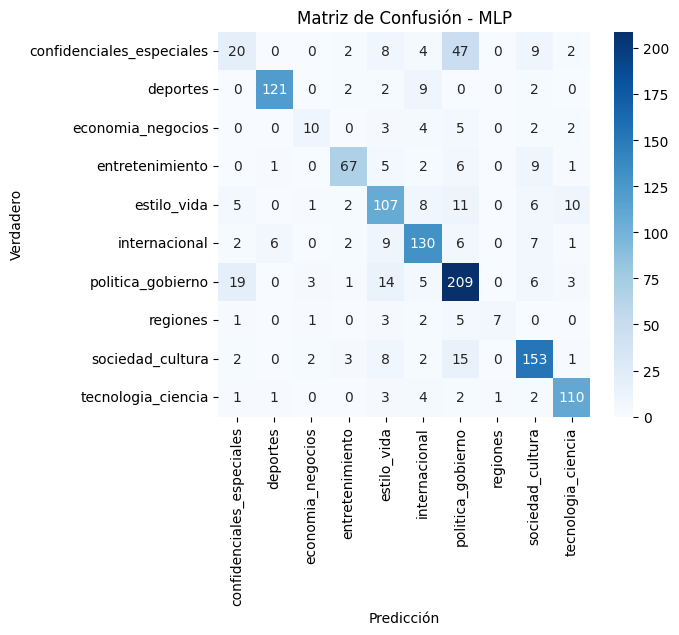

In [ ]:
y = df['categoria_grupo'].values

mlp_model = entrenar_mlp(X_nlp, y, max_iter=20)

### Resultados del MLP

El **perceptrón multicapa (MLP)** alcanzó una **precisión global del 74.9%**, mostrando un desempeño competitivo dado el carácter multiclase y el desbalance entre categorías.  
Los resultados por clase evidencian fortalezas y debilidades claras:

- **Fortalezas**: categorías como _deportes_ (F1 = 0.91), _tecnología_ciencia_ (F1 = 0.87) y _sociedad_cultura_ (F1 = 0.80) muestran una clasificación consistente, con altos niveles de _precision_ y _recall_.
- **Desempeño intermedio**: clases amplias como _política_gobierno_ (F1 = 0.74) e _internacional_ (F1 = 0.78) presentan un balance aceptable, aunque con cierta confusión hacia categorías cercanas.
- **Debilidades**: categorías con menor número de ejemplos, como _economia_negocios_ (F1 = 0.47) y _regiones_ (F1 = 0.52), muestran baja capacidad de generalización y alta confusión hacia clases más frecuentes (_política_gobierno_ y _sociedad_cultura_).

La **matriz de confusión** confirma que los errores más comunes se concentran en clases con menor representación, lo que sugiere que el modelo es sensible al **desbalance del corpus**. Sin embargo, el comportamiento de la curva de pérdida evidencia un aprendizaje estable, aunque no convergió del todo en las 20 iteraciones, lo que abre espacio para mejorar con un mayor número de épocas o técnicas de regularización.

En conclusión, el MLP se consolida como un modelo **efectivo para tareas de clasificación temática en noticias**, alcanzando un buen nivel de desempeño general, pero limitado en clases minoritarias donde la escasez de datos dificulta la discriminación precisa.


---

## **Maquinas de Soporte Vectorial (Kernel Lineal)**


🔹 SVM
Accuracy: 0.7602245388933441

Reporte de clasificación:
                            precision    recall  f1-score   support

confidenciales_especiales       0.43      0.24      0.31        92
                 deportes       0.94      0.89      0.91       136
        economia_negocios       0.50      0.38      0.43        26
          entretenimiento       0.85      0.75      0.80        91
              estilo_vida       0.71      0.73      0.72       150
            internacional       0.79      0.81      0.80       163
        politica_gobierno       0.69      0.82      0.75       260
                 regiones       0.64      0.37      0.47        19
         sociedad_cultura       0.79      0.81      0.80       186
       tecnologia_ciencia       0.86      0.91      0.88       124

                 accuracy                           0.76      1247
                macro avg       0.72      0.67      0.69      1247
             weighted avg       0.75      0.76      0.75      12

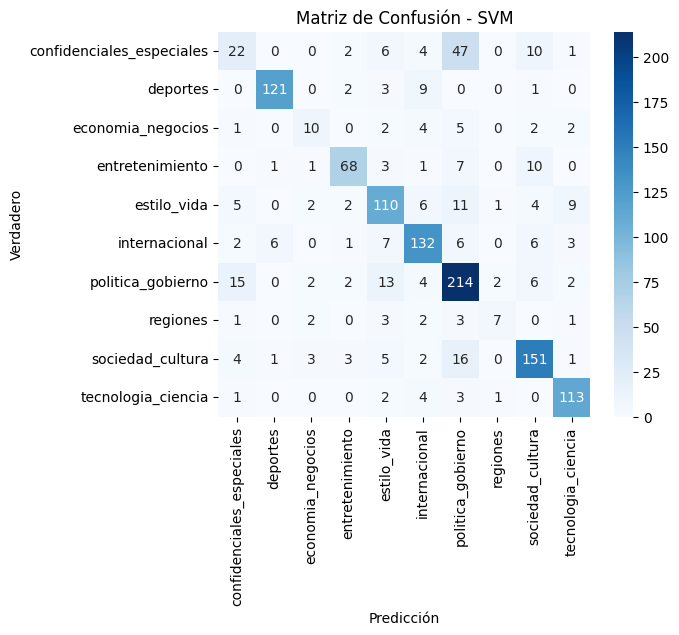

In [ ]:
svm_model = entrenar_svm(X_nlp, y, kernel="linear")

---

### Resultados del SVM

El modelo de **Support Vector Machine (SVM)** obtuvo una **precisión global del 76.0%**, superando ligeramente al MLP en desempeño general.

- **Fortalezas**: nuevamente destacan las categorías _deportes_ (F1 = 0.91), _tecnología_ciencia_ (F1 = 0.88), _sociedad_cultura_ (F1 = 0.80) e _internacional_ (F1 = 0.80), donde el modelo logra capturar patrones consistentes con altos niveles de _recall_.
- **Desempeño intermedio**: _política_gobierno_ (F1 = 0.75) y _estilo_vida_ (F1 = 0.72) muestran resultados estables, aunque la matriz de confusión revela cierta mezcla con _sociedad_cultura_ y _internacional_.
- **Debilidades**: las clases más pequeñas, como _economia_negocios_ (F1 = 0.43) y _regiones_ (F1 = 0.47), continúan con baja representación y generan predicciones imprecisas, en varios casos absorbidas por clases dominantes como _política_gobierno_.

En términos generales, el **SVM demuestra mayor robustez frente al MLP**, especialmente en la capacidad de separar clases con fronteras más definidas en espacios de alta dimensionalidad (TF-IDF). Sin embargo, el desbalance de datos sigue limitando el rendimiento en categorías minoritarias, lo que sugiere la necesidad de técnicas adicionales como _oversampling_ (SMOTE) o _class weights_.

En conclusión, el SVM se consolida como un clasificador confiable para este corpus, ofreciendo un buen equilibrio entre precisión y generalización, aunque con espacio de mejora en clases de baja frecuencia.


---

## **Random Forest**


🔹 Random Forest
Accuracy: 0.7121090617481957

Reporte de clasificación:
                            precision    recall  f1-score   support

confidenciales_especiales       0.47      0.08      0.13        92
                 deportes       0.93      0.91      0.92       136
        economia_negocios       0.00      0.00      0.00        26
          entretenimiento       0.87      0.73      0.79        91
              estilo_vida       0.71      0.65      0.68       150
            internacional       0.72      0.65      0.68       163
        politica_gobierno       0.62      0.90      0.73       260
                 regiones       0.79      0.58      0.67        19
         sociedad_cultura       0.71      0.74      0.72       186
       tecnologia_ciencia       0.70      0.85      0.77       124

                 accuracy                           0.71      1247
                macro avg       0.65      0.61      0.61      1247
             weighted avg       0.70      0.71      0.

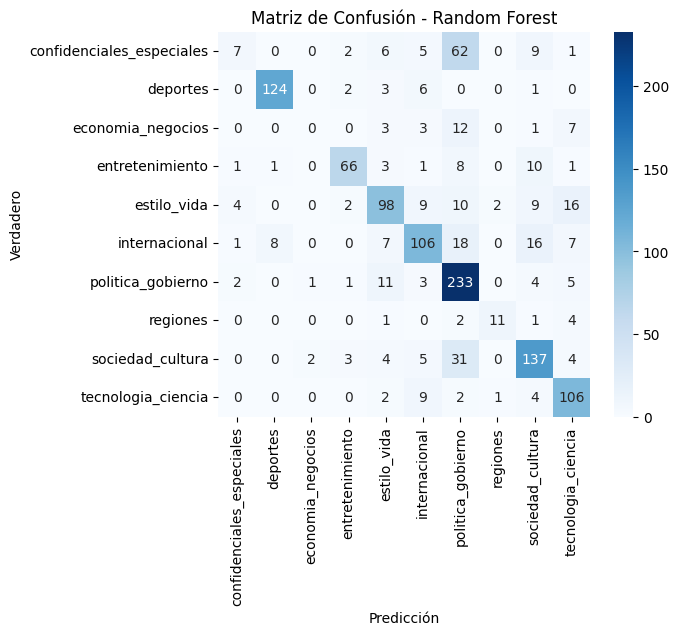

In [ ]:
rf_model  = entrenar_random_forest(X_nlp, y, n_estimators=200)

### Resultados del Random Forest

El modelo de **Random Forest (RF)** alcanzó una **precisión global del 71.2%**, siendo el de menor rendimiento entre los tres clasificadores probados.

- **Fortalezas**: categorías como _deportes_ (F1 = 0.92), _entretenimiento_ (F1 = 0.79) y _tecnología_ciencia_ (F1 = 0.77) presentan resultados sólidos, con _recall_ elevado en deportes y tecnología. Asimismo, _política_gobierno_ muestra un buen nivel de _recall_ (0.90), aunque a costa de una _precision_ más baja, lo que sugiere sobregeneralización.
- **Desempeño intermedio**: categorías amplias como _sociedad_cultura_ (F1 = 0.72) y _estilo_vida_ (F1 = 0.68) mantienen resultados aceptables, aunque con mayor dispersión de errores hacia otras clases.
- **Debilidades**: la clase _economia_negocios_ no fue correctamente aprendida (F1 = 0.00), y _confidenciales_especiales_ muestra un desempeño muy bajo (F1 = 0.13). Esto revela que el Random Forest tiene dificultades para capturar patrones en clases pequeñas y desbalanceadas.

La matriz de confusión confirma que los errores se concentran en clases minoritarias, donde el modelo tiende a clasificarlas en categorías mayoritarias como _política_gobierno_ o _sociedad_cultura_.

En síntesis, aunque el **Random Forest logra un rendimiento razonable en categorías dominantes**, su capacidad de generalización es menor en comparación con SVM y MLP, lo que lo convierte en el modelo menos competitivo dentro de este conjunto de pruebas.


### **Conclusiones sobre la clasificación**

De la aplicación de los tres modelos de clasificación se observa que el **SVM** alcanzó el mejor desempeño con una precisión del **76%**, superando ligeramente al **MLP** (75%) y al **Random Forest** (71%). Esta superioridad también se refleja en los valores de **F1-score**, donde el SVM muestra un balance más consistente entre _precision_ y _recall_ frente a los otros modelos.

El análisis de las **matrices de confusión** permite comprender de manera más detallada cómo se comporta cada modelo. Un ejemplo ilustrativo es el caso del **Random Forest**, donde 31 noticias etiquetadas como _sociedad_cultura_ fueron clasificadas erróneamente como _política_gobierno_. Esta confusión resulta lógica, ya que ambas categorías comparten fronteras temáticas y es común que una noticia cultural tenga un trasfondo político o que una noticia política contenga elementos culturales.

Este hallazgo resalta una limitación inherente al proceso: la **etiquetación manual de las noticias**. Aunque se realizó con cuidado, el carácter subjetivo de esta tarea puede introducir inconsistencias que afectan el rendimiento de los modelos. Esto abre dos líneas de mejora importantes:

1. **Refinamiento del etiquetado**: mediante protocolos más estrictos, consensos entre anotadores o incluso técnicas de _active learning_, donde el modelo retroalimenta el proceso de asignación de etiquetas.
2. **Exploración no supervisada**: aplicar técnicas de _clustering_ (por ejemplo, K-Means o DBSCAN sobre representaciones vectoriales como TF-IDF o embeddings de BERT) permitiría evaluar cuántos grupos temáticos emergen de forma natural en el corpus. Esto no solo validaría las etiquetas actuales, sino que también podría revelar nuevas categorías no contempladas inicialmente.

En conclusión, los experimentos muestran que los modelos supervisados logran un desempeño robusto, especialmente el SVM, pero también ponen en evidencia la importancia de combinar enfoques **supervisados y no supervisados** para obtener una clasificación más precisa y representativa del corpus. De esta manera, el análisis se enriquece al integrar tanto el aprendizaje automático clásico como estrategias exploratorias que ayudan a comprender mejor la estructura temática de las noticias.


---

## **Robustez y Comparacion Mediante Diferentes Implementaciones de Embeddings**


Si bien **TF-IDF** fue utilizado como nuestro embedding principal para las tareas de clasificación (resultados previamente presentados), con el fin de evaluar la **robustez** del sistema y verificar la consistencia de los hallazgos, se realizó a modo de anexo la misma experimentación utilizando representaciones alternativas: **Bag of Words (BoW)** y **embeddings semánticos basados en modelos preentrenados (Sentence-BERT)**. Esta comparación permite analizar cómo distintas formas de representación textual impactan en el rendimiento de los clasificadores.


### **Modelos con BOW**:


Iteration 1, loss = 1.30119350
Iteration 2, loss = 0.60712248
Iteration 3, loss = 0.44936717
Iteration 4, loss = 0.36919082
Iteration 5, loss = 0.32613107
Iteration 6, loss = 0.28164978
Iteration 7, loss = 0.26220554
Iteration 8, loss = 0.22830997
Iteration 9, loss = 0.20794996
Iteration 10, loss = 0.19318180
Iteration 11, loss = 0.17634404
Iteration 12, loss = 0.16285447
Iteration 13, loss = 0.15395393
Iteration 14, loss = 0.15091782
Iteration 15, loss = 0.14602375
Iteration 16, loss = 0.14399726
Iteration 17, loss = 0.13829407
Iteration 18, loss = 0.13574344
Iteration 19, loss = 0.12746955
Iteration 20, loss = 0.13025251
🔹 MLPClassifier
Accuracy: 0.7225340817963112

Reporte de clasificación:
                            precision    recall  f1-score   support

confidenciales_especiales       0.33      0.23      0.27        92
                 deportes       0.93      0.89      0.91       136
        economia_negocios       0.38      0.38      0.38        26
          entretenimiento  

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.



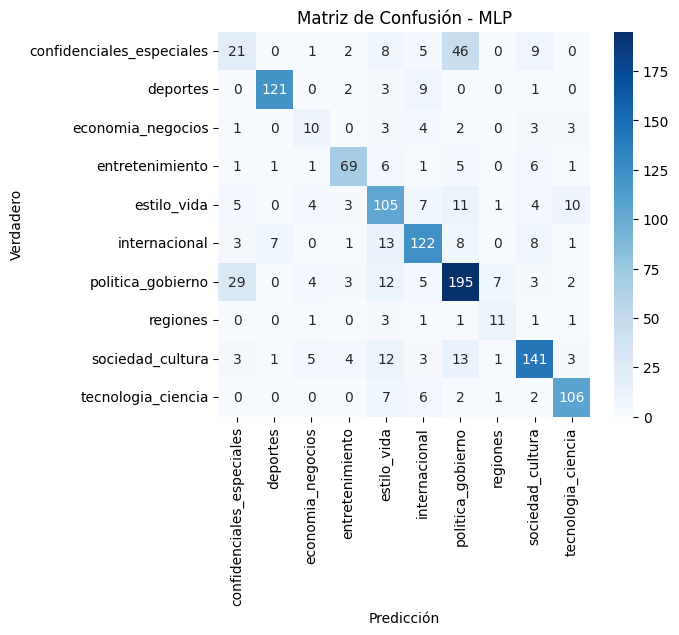

In [ ]:
mlp_model2 = entrenar_mlp(X_bow, y, max_iter=20)

### Resultados con BoW – MLP

Al emplear **Bag of Words (BoW)** como representación de los textos y un **MultiLayer Perceptron (MLP)** como clasificador, se obtuvo una **precisión global del 72%**, lo que representa un desempeño aceptable, aunque inferior al alcanzado con TF-IDF.

La matriz de confusión muestra un comportamiento consistente en categorías como **deportes** y **tecnología_ciencia**, donde el modelo logra altos valores de precisión y recall. Sin embargo, se observan mayores dificultades en categorías como **confidenciales_especiales** y **economía_negocios**, donde la dispersión temática y el menor volumen de ejemplos afectan la capacidad del modelo para generalizar.

En conjunto, los resultados sugieren que, aunque BoW ofrece una aproximación funcional, su menor capacidad para capturar relaciones semánticas entre términos limita el rendimiento comparado con TF-IDF o embeddings más sofisticados.

---


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



🔹 SVM
Accuracy: 0.6784282277465918

Reporte de clasificación:
                            precision    recall  f1-score   support

confidenciales_especiales       0.29      0.20      0.23        92
                 deportes       0.91      0.87      0.89       136
        economia_negocios       0.33      0.31      0.32        26
          entretenimiento       0.76      0.76      0.76        91
              estilo_vida       0.59      0.64      0.62       150
            internacional       0.76      0.73      0.74       163
        politica_gobierno       0.67      0.68      0.67       260
                 regiones       0.52      0.74      0.61        19
         sociedad_cultura       0.67      0.69      0.68       186
       tecnologia_ciencia       0.71      0.80      0.75       124

                 accuracy                           0.68      1247
                macro avg       0.62      0.64      0.63      1247
             weighted avg       0.67      0.68      0.67      12

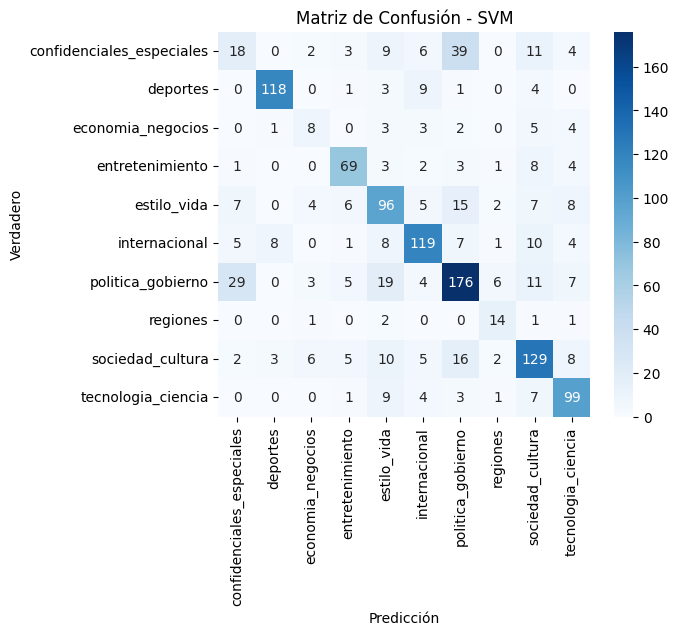

In [ ]:
svm_model2 = entrenar_svm(X_bow, y, kernel="linear")

### Resultados con BoW – SVM

Al utilizar **Bag of Words (BoW)** como embedding y un modelo de **SVM lineal** para la clasificación, la precisión obtenida fue del **68%**, siendo el rendimiento más bajo entre los modelos probados en este esquema.

La matriz de confusión refleja que el modelo logra un desempeño relativamente sólido en categorías como **deportes**, **internacional** y **tecnología_ciencia**, pero muestra debilidades en clases más pequeñas y heterogéneas, como **confidenciales_especiales** y **economía_negocios**, donde la confusión con etiquetas de mayor volumen, especialmente **política_gobierno**, es frecuente.

Este resultado evidencia una de las limitaciones de BoW: su incapacidad para capturar relaciones semánticas más complejas entre palabras, lo que afecta la capacidad del clasificador en contextos donde los términos se solapan entre categorías. Aun así, los resultados son consistentes con la idea de que SVM tiende a generalizar bien en espacios de alta dimensionalidad, aunque sin superar los resultados de TF-IDF.


🔹 Random Forest
Accuracy: 0.7209302325581395

Reporte de clasificación:
                            precision    recall  f1-score   support

confidenciales_especiales       0.44      0.08      0.13        92
                 deportes       0.93      0.90      0.92       136
        economia_negocios       0.25      0.08      0.12        26
          entretenimiento       0.85      0.74      0.79        91
              estilo_vida       0.69      0.69      0.69       150
            internacional       0.75      0.72      0.74       163
        politica_gobierno       0.63      0.86      0.73       260
                 regiones       0.75      0.47      0.58        19
         sociedad_cultura       0.75      0.73      0.74       186
       tecnologia_ciencia       0.70      0.89      0.78       124

                 accuracy                           0.72      1247
                macro avg       0.67      0.62      0.62      1247
             weighted avg       0.71      0.72      0.

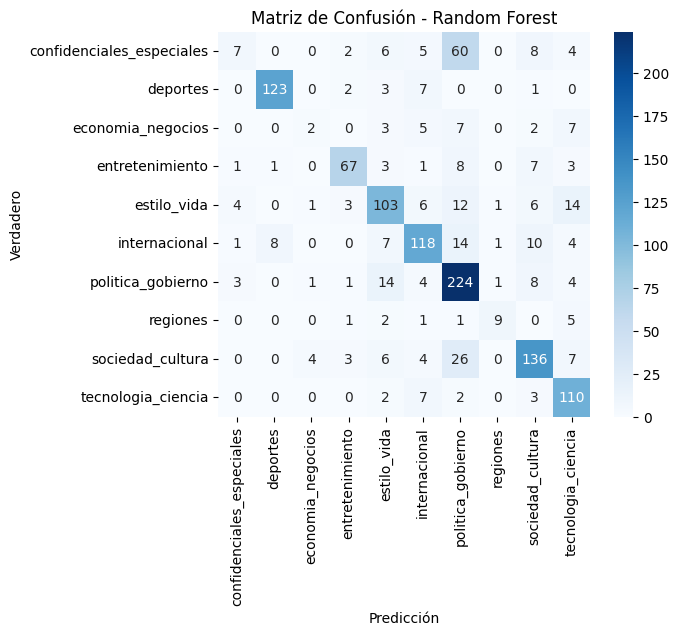

In [ ]:
rf_model2  = entrenar_random_forest(X_bow, y, n_estimators=200)

### Resultados con BoW – Random Forest

La implementación de **Random Forest** sobre los embeddings de **Bag of Words (BoW)** alcanzó una **precisión del 72%**, situándose en un rango intermedio frente a MLP y SVM en este mismo esquema.

La matriz de confusión evidencia que el modelo logra clasificar de forma consistente categorías como **deportes**, **tecnología_ciencia** y **política_gobierno**, pero muestra una caída importante en clases con menor representatividad, como **economía_negocios** o **confidenciales_especiales**, donde la precisión y el recall son bajos. Esto refleja la dificultad del algoritmo para generalizar en categorías con escaso número de ejemplos o con fronteras difusas respecto a otras.

En conjunto, los resultados muestran que Random Forest se beneficia de la robustez de BoW para capturar patrones frecuentes, pero sigue siendo más sensible a la desbalanceada distribución de las clases, lo que limita su desempeño global frente a representaciones más ricas como TF-IDF o embeddings semánticos.

### Conclusión sobre Bag of Words (BoW)

El uso de **BoW** permitió validar la robustez del pipeline al comparar con TF-IDF. Si bien los resultados fueron aceptables (con precisiones cercanas al 70%), se observa que este enfoque tiene limitaciones al no capturar adecuadamente el contexto semántico de las palabras. Esto genera confusiones en categorías con fronteras difusas, aunque sigue siendo útil como línea base para contrastar con representaciones más sofisticadas como TF-IDF o embeddings basados en transformadores.


### **Modelos con Embeddings tipo BERT**:


Iteration 1, loss = 1.79960275
Iteration 2, loss = 1.35687084
Iteration 3, loss = 1.22497150
Iteration 4, loss = 1.15123126
Iteration 5, loss = 1.09764717
Iteration 6, loss = 1.05391607
Iteration 7, loss = 1.03551424
Iteration 8, loss = 0.99991122
Iteration 9, loss = 0.97194293
Iteration 10, loss = 0.94275893
Iteration 11, loss = 0.90928736
Iteration 12, loss = 0.89897273
Iteration 13, loss = 0.88530877
Iteration 14, loss = 0.87767109
Iteration 15, loss = 0.83076731
Iteration 16, loss = 0.81779064
Iteration 17, loss = 0.78788896
Iteration 18, loss = 0.77084583
Iteration 19, loss = 0.76196742
Iteration 20, loss = 0.76046477
🔹 MLPClassifier
Accuracy: 0.6704089815557338

Reporte de clasificación:
                            precision    recall  f1-score   support

confidenciales_especiales       0.39      0.24      0.30        92
                 deportes       0.86      0.79      0.82       136
        economia_negocios       0.25      0.08      0.12        26
          entretenimiento  

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.



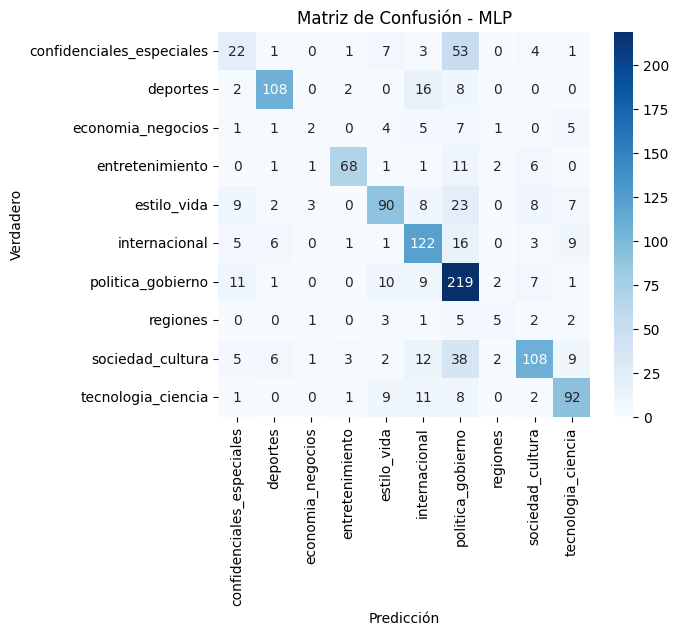

In [ ]:
mlp_model3 = entrenar_mlp(X_bert, y, max_iter=20)

### Resultados con BERT – MLP

La implementación de **MLP sobre embeddings BERT** obtuvo una **precisión global del 67%**, un rendimiento menor comparado con los experimentos de TF-IDF y BoW. Aunque las representaciones semánticas de BERT suelen capturar mayor riqueza contextual, en este caso el modelo mostró dificultades para generalizar de manera estable, especialmente en categorías con baja representatividad como **economía_negocios** o **regiones**, donde el desempeño fue claramente bajo.

La matriz de confusión evidencia que las categorías con mayor cantidad de ejemplos —como **política_gobierno** o **internacional**— mantienen un rendimiento relativamente sólido, mientras que las clases minoritarias tienden a confundirse con aquellas más amplias y temáticamente cercanas.

Esto sugiere que, aunque BERT aporta embeddings más informativos, la combinación con un clasificador simple como MLP puede no ser suficiente para explotar todo su potencial. En futuros trabajos podría explorarse el fine-tuning del modelo base o el uso de clasificadores más complejos que se adapten mejor a la naturaleza de los embeddings contextuales.


🔹 SVM
Accuracy: 0.6343223736968725

Reporte de clasificación:
                            precision    recall  f1-score   support

confidenciales_especiales       0.27      0.20      0.23        92
                 deportes       0.87      0.79      0.83       136
        economia_negocios       0.24      0.23      0.24        26
          entretenimiento       0.73      0.74      0.73        91
              estilo_vida       0.58      0.62      0.60       150
            internacional       0.63      0.60      0.61       163
        politica_gobierno       0.62      0.68      0.65       260
                 regiones       0.25      0.21      0.23        19
         sociedad_cultura       0.67      0.68      0.68       186
       tecnologia_ciencia       0.69      0.76      0.72       124

                 accuracy                           0.63      1247
                macro avg       0.56      0.55      0.55      1247
             weighted avg       0.63      0.63      0.63      12

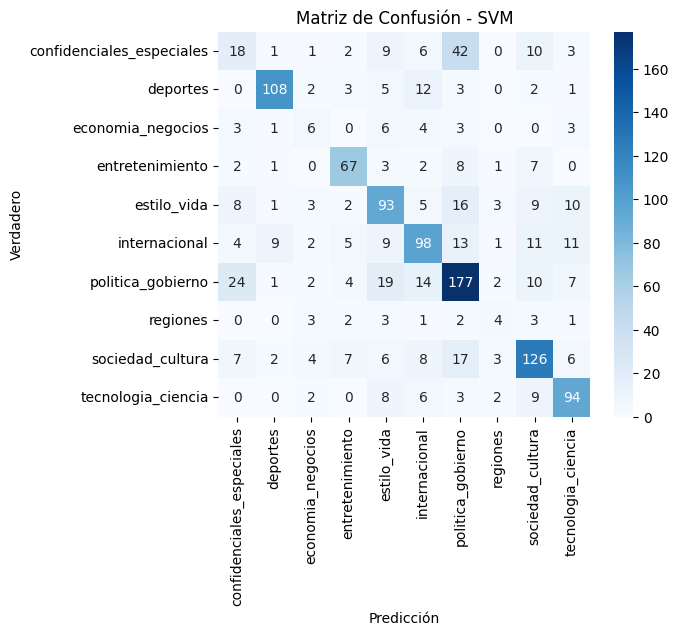

In [ ]:
svm_model3 = entrenar_svm(X_bert, y, kernel="linear")

### Resultados con BERT – SVM

La combinación de **SVM con embeddings BERT** alcanzó una **precisión del 63%**, siendo el rendimiento más bajo entre las variantes probadas. Aunque SVM suele funcionar bien con representaciones lineales como TF-IDF o BoW, en este caso parece tener dificultades para aprovechar la riqueza contextual de los embeddings de BERT.

La matriz de confusión muestra que categorías con muchos ejemplos como **política_gobierno** o **sociedad_cultura** mantienen un desempeño aceptable, mientras que las clases con menor representación (**economía_negocios**, **regiones**) presentan un rendimiento muy pobre. Esto indica que el modelo no logra separar correctamente las fronteras entre clases semánticamente cercanas, y tiende a confundir categorías con contenido temático solapado.

En conclusión, aunque los embeddings de BERT ofrecen una representación avanzada, su uso directo con SVM no resulta óptimo. Sería recomendable considerar técnicas como **fine-tuning del modelo base** o clasificadores más complejos (p. ej. redes neuronales profundas) que puedan aprovechar mejor la estructura no lineal de los embeddings.


🔹 Random Forest
Accuracy: 0.6110665597433841

Reporte de clasificación:
                            precision    recall  f1-score   support

confidenciales_especiales       0.00      0.00      0.00        92
                 deportes       0.90      0.74      0.81       136
        economia_negocios       0.33      0.04      0.07        26
          entretenimiento       0.86      0.69      0.77        91
              estilo_vida       0.52      0.57      0.54       150
            internacional       0.58      0.58      0.58       163
        politica_gobierno       0.50      0.83      0.63       260
                 regiones       0.50      0.05      0.10        19
         sociedad_cultura       0.67      0.61      0.64       186
       tecnologia_ciencia       0.68      0.72      0.70       124

                 accuracy                           0.61      1247
                macro avg       0.56      0.48      0.48      1247
             weighted avg       0.59      0.61      0.

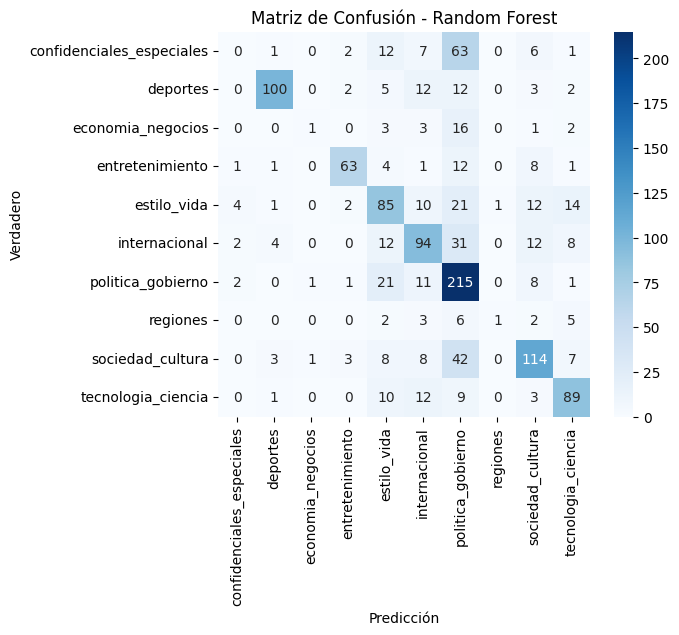

In [ ]:
rf_model3  = entrenar_random_forest(X_bert, y, n_estimators=200)

### Resultados con BERT – Random Forest

El modelo de **Random Forest con embeddings BERT** alcanzó una **precisión del 61%**, mostrando el desempeño más bajo dentro de las combinaciones evaluadas. La matriz de confusión refleja que varias categorías fueron particularmente problemáticas, como **confidenciales_especiales** (donde prácticamente no hubo aciertos) y **economía_negocios**, con un f1-score muy bajo.

Aunque categorías más frecuentes como **política_gobierno** o **sociedad_cultura** lograron un rendimiento razonable, se observa una tendencia del modelo a sobreajustarse a estas clases dominantes y a confundir aquellas con menor representación. Esto pone en evidencia la **limitación de Random Forest para capturar relaciones semánticas profundas** en embeddings densos como los de BERT, dado que este tipo de representación no se adapta bien a divisiones basadas en árboles.

En conclusión, los resultados sugieren que el uso de Random Forest sobre embeddings BERT no es una estrategia adecuada, y que sería preferible optar por modelos más alineados con representaciones distribuidas, como redes neuronales profundas o técnicas de fine-tuning específicas.


---

### Conclusiones sobre Embeddings BERT

Al aplicar embeddings BERT como representación de los textos, los resultados muestran un desempeño **inferior** en comparación con TF-IDF y Bag of Words. En particular, los modelos entrenados con BERT alcanzaron niveles de accuracy entre **61% y 67%**, bastante por debajo del 76% logrado con TF-IDF. Además, las matrices de confusión evidencian una mayor confusión entre categorías temáticamente cercanas (por ejemplo, _sociedad_cultura_ con _política_gobierno_ o _internacional_), lo que refleja que el modelo no logra separar con claridad los límites semánticos de cada clase.

Una explicación plausible es que **el tamaño reducido del corpus (≈6.500 noticias)** limita la capacidad de los embeddings BERT para generalizar adecuadamente. Este tipo de representaciones densas suelen requerir **grandes volúmenes de datos** para brillar y mostrar ventaja frente a métodos tradicionales. En contextos de datos más pequeños, la riqueza semántica de BERT no se traduce necesariamente en un mejor rendimiento, ya que los modelos de clasificación pueden sobreajustarse o no aprovechar completamente la dimensionalidad del embedding.

En conclusión, aunque BERT aporta un mayor nivel de información semántica, en este proyecto sus resultados se ven restringidos por el tamaño del dataset. Con un corpus más amplio y balanceado, es razonable esperar que los embeddings BERT superen a TF-IDF y BoW en tareas de clasificación de noticias.

## **Conclusiones Finales de la Clasificación**

De la aplicación de los tres esquemas de representación (TF-IDF, Bag of Words y BERT) y su evaluación con modelos clásicos de clasificación (MLP, SVM y Random Forest), se desprenden varias conclusiones relevantes:

1. **TF-IDF fue la representación más robusta.** Con este embedding se alcanzaron los mejores resultados, en particular con **SVM (76% de accuracy)**, superando ligeramente a MLP (75%) y con una diferencia más marcada frente a Random Forest (71%). Esto indica que, en un corpus de tamaño moderado, las representaciones dispersas y basadas en frecuencia siguen siendo altamente efectivas para tareas de clasificación temática.

2. **Bag of Words ofreció un rendimiento intermedio.** Aunque sus resultados fueron razonables (≈68–72% de accuracy), en todos los casos se ubicaron por debajo de TF-IDF. Esto sugiere que, al no ponderar términos relevantes, BoW pierde poder discriminativo en comparación con TF-IDF.

3. **BERT no superó a los métodos tradicionales.** A pesar de capturar información semántica más rica, los modelos entrenados con embeddings densos de BERT lograron accuracies entre **61% y 67%**, con claras dificultades para distinguir categorías cercanas. Esto refuerza la hipótesis de que **el tamaño relativamente reducido del dataset (≈6.500 noticias)** limita el verdadero potencial de BERT, que requiere más datos para desplegar su ventaja sobre representaciones clásicas.

4. **Confusión entre clases cercanas.** En todas las implementaciones se observan errores frecuentes en categorías con alta proximidad temática, como _sociedad_cultura_ con _política_gobierno_ o _internacional_. Esto puede deberse tanto a la ambigüedad inherente de las noticias como al proceso de etiquetado manual, lo que abre la posibilidad de mejorar la anotación o de explorar enfoques no supervisados (clustering) para evaluar la coherencia de las clases.

En síntesis, **TF-IDF + SVM se consolida como la mejor combinación** para este corpus, mientras que BERT, aunque prometedor, requiere un mayor volumen y balance de datos para alcanzar su verdadero potencial. Estos resultados resaltan la importancia de adaptar la elección del embedding y del clasificador a las características del dataset disponible.


---

## 2. **Análisis de sentimiento**


#### Metodología de Análisis de Sentimiento (modelo BETO – 5+1 clases)

Para clasificar el sentimiento en textos extensos, como lo son las noticas, empleamos el checkpoint en español  
**`ignacio-ave/beto-sentiment-analysis-spanish`**, basado en **BETO** (BERT entrenado para español) y **afinado para análisis de sentimiento**.  
Este modelo produce **clases ordinales** de polaridad:

- **VERY NEGATIVE**, **NEGATIVE**, **NEUTRAL**, **POSITIVE**, **VERY POSITIVE**
- y una clase de reserva **UNDEFINED** cuando el texto no encaja en las anteriores.

**Ventajas del enfoque preentrenado.** No necesitamos construir embeddings manualmente: el modelo realiza **tokenización sub-palabra** y genera **representaciones contextuales** internamente, lo que ofrece mejor precisión que enfoques de bolsa de palabras o embeddings estáticos.

**Textos largos (límite de 512 tokens).** Para no perder información en noticias largas, usamos una estrategia de **ventanas deslizantes** (_windowing_): dividimos cada documento en _chunks_ de hasta **512 tokens** con **solapamiento** (_stride_). Cada chunk se procesa en **lotes (batch)** con **padding dinámico** en GPU. Para combinar las predicciones de un mismo documento, **promediamos los _logits_** de todos sus chunks y luego aplicamos _softmax_, obteniendo una probabilidad por clase para el documento completo. Esta agregación es **más estable** que promediar probabilidades directamente.

**Salida y columnas en el DataFrame.** Para cada noticia incorporamos:

1. `sentimiento_5clases`: etiqueta ordinal en {VERY NEGATIVE, NEGATIVE, NEUTRAL, POSITIVE, VERY POSITIVE} (o **UNDEFINED** cuando ocurra).
2. `score_5clases`: probabilidad asignada por el modelo a la clase elegida (tras la agregación por chunks).

**Detalles de implementación.** Usamos **modelo y tokenizer del mismo repo** para evitar desalineaciones, ejecución **en GPU** con _batching_ y **padding dinámico**, y control de solapamiento (_stride_) para balancear cobertura contextual y eficiencia computacional. Esta configuración prioriza **robustez reproducible** y **escalabilidad** sobre corpus noticiosos.


In [ ]:

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
corpus = pd.read_csv('/content/corpus_preprocessed.csv')
corpus.head()

,Unnamed: 0,fecha,titulo,cuerpo,url,categoria,categoria_grupo,texto_tfidf
0,580,2025-08-26 13:31:46-05:00,YouTube hizo inesperado movimiento con intelig...,La plataforma de entretenimiento YouTube cuent...,https://www.semana.com//tecnologia/articulo/yo...,tecnologia,tecnologia_ciencia,plataforma entretenimiento youtube contar mill...
1,581,2025-08-26 16:39:02-05:00,Apple reveló la fecha de lanzamiento del iPhon...,Apple celebrará un nuevo evento de presentació...,https://www.semana.com//tecnologia/articulo/ap...,tecnologia,tecnologia_ciencia,apple celebrar evento presentacion producto se...
2,582,2025-08-21 19:13:31-05:00,La estrella más lejana conocida puede no serlo...,"Eärendel, un objeto descubierto en 2022 con el...",https://www.semana.com//tecnologia/articulo/la...,tecnologia,tecnologia_ciencia,rendel objeto descubierto telescopio espacial ...
3,583,2025-08-08 20:07:54-05:00,Por primera vez en la historia: investigadores...,Un equipo de especialistas en ciberseguridad r...,https://www.semana.com//tecnologia/articulo/po...,tecnologia,tecnologia_ciencia,equipo especialista ciberseguridad revelo meto...
4,584,2025-08-28 14:57:58-05:00,No solo es la inteligencia artificial: esta es...,"Para muchos ha resultado sorprendente cómo, en...",https://www.semana.com//tecnologia/articulo/no...,tecnologia,tecnologia_ciencia,resultar sorprendente ano inteligencia artific...


In [ ]:
import torch, numpy as np
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding


if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "enable_flash_sdp"):
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)

MODEL = "ignacio-ave/beto-sentiment-analysis-spanish"
TOKENIZER = MODEL
BATCH_SIZE = 32
MAX_LEN = 512
STRIDE   = 128
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

texts = corpus["texto_tfidf"].fillna("").astype(str).tolist()

tok = AutoTokenizer.from_pretrained(TOKENIZER, use_fast=True, model_max_length=MAX_LEN)
tok.padding_side = "right"
tok.truncation_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token if tok.eos_token is not None else tok.cls_token

mdl = AutoModelForSequenceClassification.from_pretrained(MODEL)
mdl.config.pad_token_id = tok.pad_token_id
mdl = mdl.to(DEVICE).eval()

id2label = mdl.config.id2label
num_labels = mdl.config.num_labels

mini = tok(["hola mundo"], return_tensors="pt", padding=True, truncation=True, max_length=64)
with torch.no_grad():
    _ = mdl(**{k: v.to(DEVICE) for k,v in mini.items()})


enc = tok(texts,
    truncation=True, max_length=MAX_LEN, stride=STRIDE,
    return_overflowing_tokens=True, return_tensors=None)
sample_map = enc.pop("overflow_to_sample_mapping")

class ChunksDataset(torch.utils.data.Dataset):
    """
    Dataset personalizado para manejar datos tokenizados y su correspondencia
    con índices de muestra.

    Este dataset extiende `torch.utils.data.Dataset` y está pensado para trabajar
    con representaciones tokenizadas (por ejemplo, salidas de un `Tokenizer` de
    Hugging Face). Cada elemento incluye tanto los tensores de entrada como el
    índice de la muestra original de la que proviene.

    Args:
        encodings (dict of torch.Tensor): Diccionario con tensores tokenizados,
            típicamente las salidas de un `Tokenizer` (p. ej., "input_ids",
            "attention_mask").
        sample_map (list or array-like): Lista de índices que mapea cada chunk al
            índice de la muestra original.

    Attributes:
        encodings (dict of torch.Tensor): Tensores tokenizados para cada clave.
        sample_map (list): Mapeo de chunks a índices de muestra.

    Methods:
        __len__():
            Devuelve el número total de elementos en el dataset, igual a la longitud
            de `sample_map`.
        __getitem__(idx):
            Devuelve un diccionario con:
              - claves de `encodings` indexadas en `idx`,
              - clave adicional `"sample_idx"` indicando el índice de la muestra original.
    """

    def __init__(self, encodings, sample_map):
        self.encodings, self.sample_map = encodings, sample_map

    def __len__(self):
      return len(self.sample_map)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["sample_idx"] = self.sample_map[idx]
        return item

ds = ChunksDataset(enc, sample_map)
collator = DataCollatorWithPadding(tokenizer=tok)

def collate_fn(batch):
    """
    Función de colación personalizada para DataLoader.

    Combina una lista de ejemplos (batch) en un único diccionario de tensores
    para su uso en el modelo. Extrae los índices de muestra y aplica un collator
    externo (por ejemplo, de Hugging Face) para procesar los tensores de entrada.

    Args:
        batch (list of dict): Lista de ejemplos individuales, donde cada ejemplo es
            un diccionario con las claves:
              - Tensores de entrada (e.g., "input_ids", "attention_mask").
              - "sample_idx" (int): índice de la muestra original.

    Returns:
        dict: Diccionario con los tensores colacionados. Contiene:
            - Tensores procesados por `collator` (p. ej., "input_ids", "attention_mask").
            - "sample_idx" (torch.Tensor): índices de muestra concatenados.

    Notas:
        - Requiere que exista un objeto `collator` definido en el ámbito global,
          responsable de transformar listas de tensores en tensores batch.
        - Se asume que todos los elementos en el batch tienen las mismas claves.
        - Es compatible con `DataLoader(..., collate_fn=collate_fn)`.
    """
    sample_idx = torch.tensor([b["sample_idx"] for b in batch], dtype=torch.long)
    model_inputs = {k: [b[k] for b in batch] for k in batch[0] if k != "sample_idx"}
    model_inputs = collator(model_inputs)
    model_inputs["sample_idx"] = sample_idx
    return model_inputs

dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

sum_logits = [np.zeros((num_labels,), dtype=np.float32) for _ in range(len(texts))]
count_chunks = [0 for _ in range(len(texts))]

with torch.no_grad():
    for batch in dl:
        sample_idx = batch.pop("sample_idx").cpu().numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = mdl(**batch)
        logits = out.logits.detach().cpu().numpy()
        for i, doc_id in enumerate(sample_idx):
            sum_logits[doc_id] += logits[i]
            count_chunks[doc_id] += 1

labels, scores = [], []
for doc_id in range(len(texts)):
    mean_logits = sum_logits[doc_id] / max(count_chunks[doc_id], 1)
    probs = np.exp(mean_logits - mean_logits.max()); probs /= probs.sum()
    lid = int(np.argmax(probs))
    labels.append(id2label[lid])
    scores.append(float(probs[lid]))

corpus["sentimiento"] = labels
corpus["score"] = scores

tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

In [ ]:
corpus.head()

,Unnamed: 0,fecha,titulo,cuerpo,url,categoria,categoria_grupo,texto_tfidf,sentimiento,score
0,580,2025-08-26 13:31:46-05:00,YouTube hizo inesperado movimiento con intelig...,La plataforma de entretenimiento YouTube cuent...,https://www.semana.com//tecnologia/articulo/yo...,tecnologia,tecnologia_ciencia,plataforma entretenimiento youtube contar mill...,VERY POSITIVE,0.489073
1,581,2025-08-26 16:39:02-05:00,Apple reveló la fecha de lanzamiento del iPhon...,Apple celebrará un nuevo evento de presentació...,https://www.semana.com//tecnologia/articulo/ap...,tecnologia,tecnologia_ciencia,apple celebrar evento presentacion producto se...,POSITIVE,0.856817
2,582,2025-08-21 19:13:31-05:00,La estrella más lejana conocida puede no serlo...,"Eärendel, un objeto descubierto en 2022 con el...",https://www.semana.com//tecnologia/articulo/la...,tecnologia,tecnologia_ciencia,rendel objeto descubierto telescopio espacial ...,NEGATIVE,0.602729
3,583,2025-08-08 20:07:54-05:00,Por primera vez en la historia: investigadores...,Un equipo de especialistas en ciberseguridad r...,https://www.semana.com//tecnologia/articulo/po...,tecnologia,tecnologia_ciencia,equipo especialista ciberseguridad revelo meto...,VERY NEGATIVE,0.715093
4,584,2025-08-28 14:57:58-05:00,No solo es la inteligencia artificial: esta es...,"Para muchos ha resultado sorprendente cómo, en...",https://www.semana.com//tecnologia/articulo/no...,tecnologia,tecnologia_ciencia,resultar sorprendente ano inteligencia artific...,VERY POSITIVE,0.640022


---

### **Analisis de los sentimientos clasificados**

Dado que **no contamos con etiquetas reales de sentimiento en nuestro corpus**, no es posible calcular métricas tradicionales de desempeño como _accuracy_, _precision_ o _recall_. Por esta razón, el enfoque se centra en **analizar la distribución y coherencia de los resultados producidos por el modelo**. De esta manera, buscamos identificar patrones relevantes, tales como:

- **Distribución de sentimientos** en el corpus.
- **Scores (confianza)** por clase.
- **Evolución temporal** del sentimiento (media móvil).
- **Top trigramas** por polaridad.

Este análisis permite **obtener una aproximación cualitativa al sesgo emocional presente en las noticias**, evaluando tendencias generales sin necesidad de contar con un conjunto etiquetado de referencia. Además, constituye un punto de partida para futuras extensiones, como la creación de un dataset anotado manualmente que permita evaluar cuantitativamente el rendimiento del modelo.


---

### **Distribución de sentimientos en el corpus**


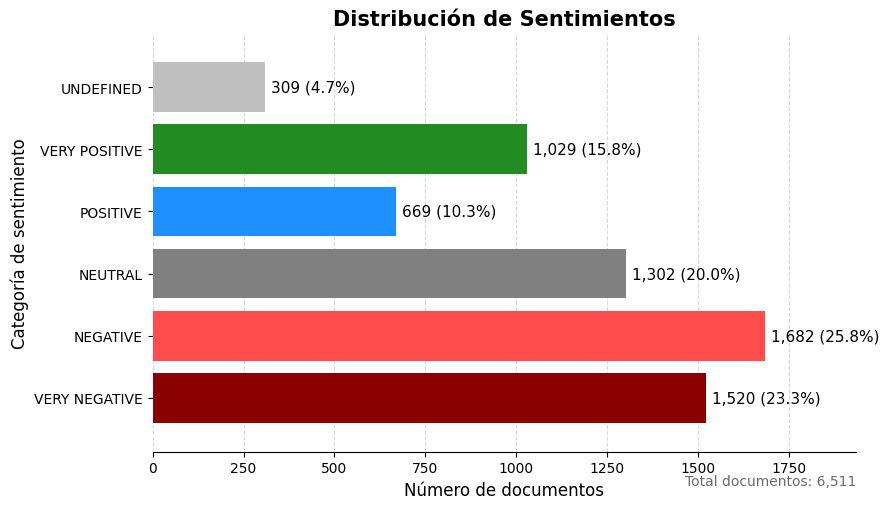

In [ ]:

def plot_sentiment_bars(df, col="sentimiento"):
    """
    Genera un gráfico de barras horizontales que muestra la distribución de
    categorías de sentimiento en un DataFrame.

    Args:
        df (pandas.DataFrame): DataFrame que contiene la columna de categorías
            de sentimiento.
        col (str, optional): Nombre de la columna con las categorías de sentimiento.
            Por defecto "sentimiento".

    Returns:
        None: Muestra la figura directamente con `matplotlib.pyplot.show()`.

    Notas:
        - Ordena las categorías según un orden predefinido:
          ["VERY NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE",
           "VERY POSITIVE", "UNDEFINED"]. Si existen otras categorías,
          se agregan al final en el orden en que aparecen.
        - Se calcula tanto el número absoluto como el porcentaje de documentos
          para cada categoría.
        - Colorea cada barra según un mapa de colores específico de sentimiento.
        - Añade etiquetas de conteo y porcentaje al final de cada barra.
        - El gráfico incluye el total de documentos en una anotación inferior.
    """
    counts = df[col].value_counts(dropna=False)
    total = int(counts.sum())
    preferred_order = ["VERY NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY POSITIVE", "UNDEFINED"]
    ordered_index = [c for c in preferred_order if c in counts.index] + \
                    [c for c in counts.index if c not in preferred_order]
    counts = counts.reindex(ordered_index)

    pct = (counts / total * 100).round(1)

    color_map = {
        "VERY NEGATIVE": "#8B0000",
        "NEGATIVE": "#FF4C4C",
        "NEUTRAL": "#808080",
        "POSITIVE": "#1E90FF",
        "VERY POSITIVE": "#228B22",
        "UNDEFINED": "#C0C0C0"}
    colors = [color_map.get(cat, "#4682B4") for cat in counts.index]

    fig, ax = plt.subplots(figsize=(9, 5.2))
    bars = ax.barh(counts.index, counts.values, color=colors)

    for bar, c, p in zip(bars, counts.values, pct.values):
        w = bar.get_width()
        ax.text(
            w + max(counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{c:,.0f} ({p:.1f}%)",
            va="center", ha="left", fontsize=11)

    ax.set_title("Distribución de Sentimientos", fontsize=15, fontweight="bold")
    ax.set_xlabel("Número de documentos", fontsize=12)
    ax.set_ylabel("Categoría de sentimiento", fontsize=12)

    ax.grid(axis="x", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.set_xlim(0, max(counts.values) * 1.15)
    ax.margins(y=0.08)
    ax.text(
        1.0, -0.08,
        f"Total documentos: {total:,}",
        transform=ax.transAxes, fontsize=10, ha="right", color="dimgray")
    plt.tight_layout()
    plt.show()

plot_sentiment_bars(corpus, col="sentimiento")

#### Interpretación preliminar de la distribución de sentimientos

La mayor parte de los documentos analizados exhibe una carga **negativa**:

- **NEGATIVE (25.8%)** y **VERY NEGATIVE (23.3%)** concentran casi **la mitad de las observaciones**.
- En contraste, los documentos con valoración **positiva** (POSITIVE + VERY POSITIVE) apenas suman **26.1%**.
- El segmento **NEUTRAL (20%)** también tiene un peso considerable, reflejando una proporción relevante de textos sin polaridad marcada.
- Finalmente, un **4.7%** de los casos quedó en **UNDEFINED**, probablemente asociado a textos ambiguos o con bajo contenido emocional.

En conjunto, esta distribución sugiere que el corpus de noticias tiende a resaltar **aspectos negativos** más que positivos, aunque también hay una fracción no despreciable de contenidos neutrales y positivos.


---

### **Scores (confianza) por clase.**


/tmp/ipython-input-2008984381.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




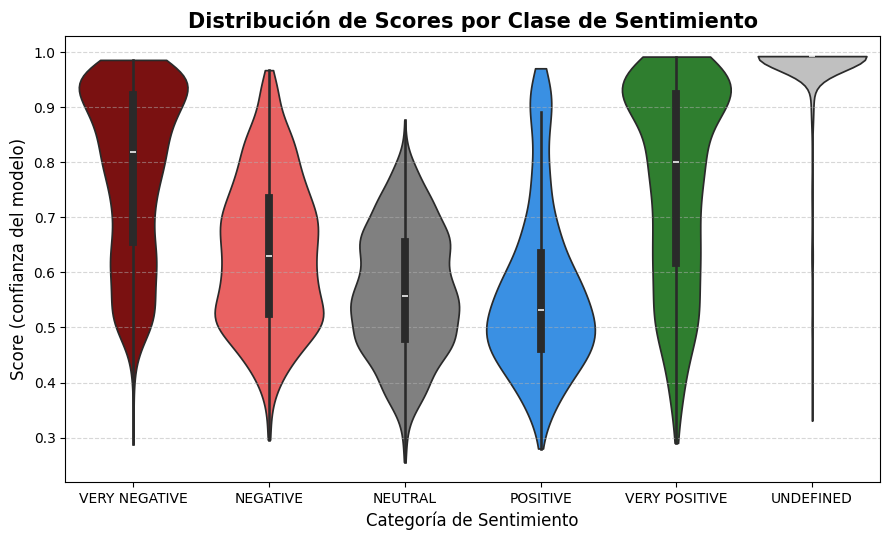

In [ ]:
import seaborn as sns

if "sentimiento" in corpus.columns and "score" in corpus.columns:
    plt.figure(figsize=(9, 5.5))
    sns.violinplot(
        data=corpus,
        x="sentimiento",
        y="score",
        order=["VERY NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY POSITIVE", "UNDEFINED"],
        palette={
            "VERY NEGATIVE": "#8B0000",
            "NEGATIVE": "#FF4C4C",
            "NEUTRAL": "#808080",
            "POSITIVE": "#1E90FF",
            "VERY POSITIVE": "#228B22",
            "UNDEFINED": "#C0C0C0"
        },
        inner="box",
        cut=0)
    plt.title("Distribución de Scores por Clase de Sentimiento", fontsize=15, fontweight="bold")
    plt.xlabel("Categoría de Sentimiento", fontsize=12)
    plt.ylabel("Score (confianza del modelo)", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("El DataFrame no contiene las columnas 'sentimiento' y 'score'.")

#### Interpretación del violin plot de scores

El gráfico muestra cómo varía la **confianza del modelo** (`score`) en cada clase de sentimiento:

1. **Clases extremas (VERY NEGATIVE y VERY POSITIVE)**

   - Presentan distribuciones muy concentradas en valores altos (≈0.9–1.0).
   - Esto indica que cuando el modelo asigna una polaridad muy marcada, lo hace con gran seguridad.
   - La mediana es claramente alta, y la dispersión relativamente baja.

2. **Clases intermedias (NEGATIVE y POSITIVE)**

   - Los scores son más dispersos (≈0.4–0.8).
   - El modelo reconoce estas categorías, pero con menor confianza que en los extremos.
   - Esto refleja que algunos textos cercanos a la frontera entre positivo/negativo se asignan con incertidumbre.

3. **Clase NEUTRAL**

   - La distribución está centrada en valores medios (≈0.5–0.7).
   - Confirma que el modelo tiende a ser **menos categórico** con noticias neutras, lo que es coherente con la naturaleza ambigua de este sentimiento.
   - Es la clase con mayor variabilidad en confianza.

4. **Clase UNDEFINED**
   - Llama la atención que sus scores aparecen en el rango más alto (≈0.9–1.0).
   - Esto sugiere que el modelo es **muy seguro cuando detecta casos no clasificables**, probablemente porque el texto no contiene señales afectivas claras.
   - En la práctica, conviene revisar cómo manejar esta categoría (excluirla, o tratarla como “indefinida”).

El modelo muestra un patrón consistente:

- **Alta seguridad en los extremos** (very negative / very positive).
- **Confianza moderada en clases intermedias** (negative / positive).
- **Neutralidad menos definida**, con mayor dispersión de scores.
- **Undefined** funciona como una clase “segura”, pero que representa ambigüedad semántica.


---

### **Evolución temporal del sentimiento (media móvil).**


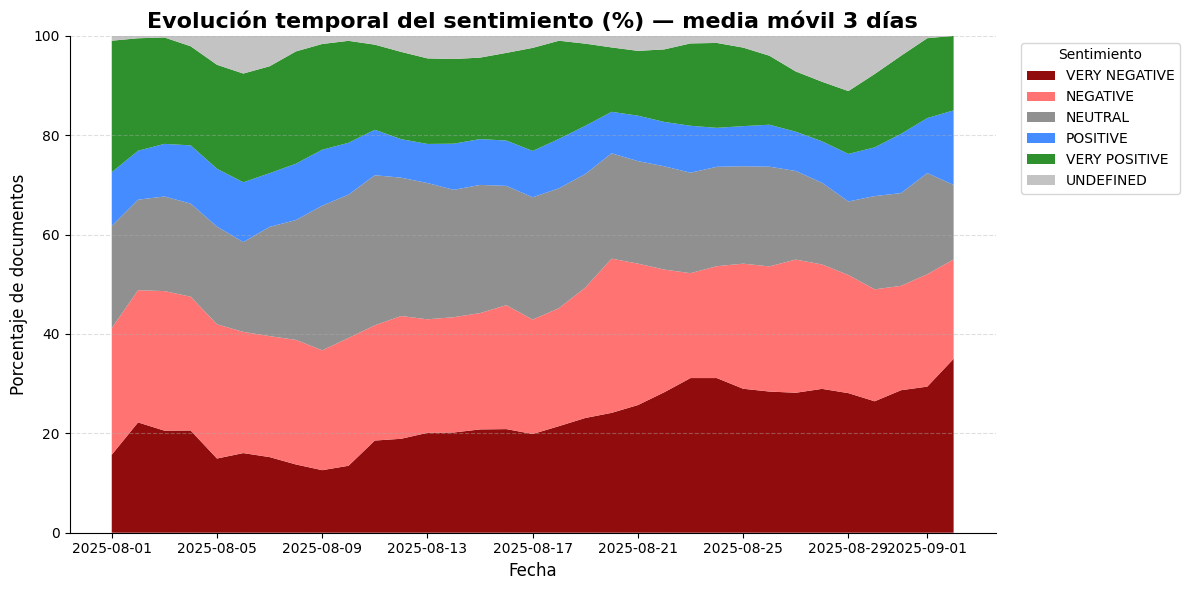

In [ ]:

fecha_col = "fecha"
sent_col  = "sentimiento"
window = 3
min_docs = 20

corpus[fecha_col] = pd.to_datetime(corpus[fecha_col], utc=True, errors="coerce")
df = corpus.dropna(subset=[fecha_col]).copy()
df["dia"] = df[fecha_col].dt.floor("D")

daily_counts = (
    df.groupby(["dia", sent_col])
      .size().unstack(fill_value=0)
      .sort_index())
all_days = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq="D", tz="UTC")
daily_counts = daily_counts.reindex(all_days, fill_value=0)
daily_counts.index.name = "dia"
daily_tot = daily_counts.sum(axis=1)
daily_pct = daily_counts.div(daily_tot.replace(0, np.nan), axis=0) * 100
daily_pct_filtered = daily_pct.where(daily_tot >= min_docs)
daily_pct_smooth = daily_pct_filtered.rolling(window=window, min_periods=1).mean()

order = [c for c in ["VERY NEGATIVE","NEGATIVE","NEUTRAL","POSITIVE","VERY POSITIVE","UNDEFINED"]
         if c in daily_pct_smooth.columns]
color_map = {
    "VERY NEGATIVE": "#8B0000",
    "NEGATIVE":      "#FF6B6B",
    "NEUTRAL":       "#8A8A8A",
    "POSITIVE":      "#3A86FF",
    "VERY POSITIVE": "#228B22",
    "UNDEFINED":     "#C0C0C0"}

colors = [color_map[c] for c in order]

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(daily_pct_smooth.index.to_pydatetime(),
             *[daily_pct_smooth[c].values for c in order],
             labels=order, colors=colors, alpha=0.95)

ax.set_title("Evolución temporal del sentimiento (%) — media móvil {} días".format(window),
             fontsize=16, fontweight="bold")
ax.set_ylabel("Porcentaje de documentos", fontsize=12)
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Sentimiento", bbox_to_anchor=(1.02, 1), loc="upper left")
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

- **Tendencia al alza de lo negativo**: a mitad de mes aumenta el peso combinado de _VERY NEGATIVE_ + _NEGATIVE_ y cierra con su **máximo relativo** (≈55% del total).
- **Neutral en retroceso**: la franja _NEUTRAL_ pierde participación conforme avanza el mes, lo que sugiere que la cobertura se vuelve más polarizada.
- **Positividad acotada y estable**: _POSITIVE_ se mantiene en una banda estrecha y _VERY POSITIVE_ desciende hacia el final, contribuyendo poco al total.
- **Robustez visual**: el suavizado de 3 días atenúa picos puntuales; el patrón negativo no depende de outliers diarios.
- **Advertencia metodológica**: el scraping fue **más intenso en la recta final del mes**, por lo que el incremento de negatividad podría estar **amplificado** por ese sesgo temporal.


---

### **Top trigramas por polaridad**


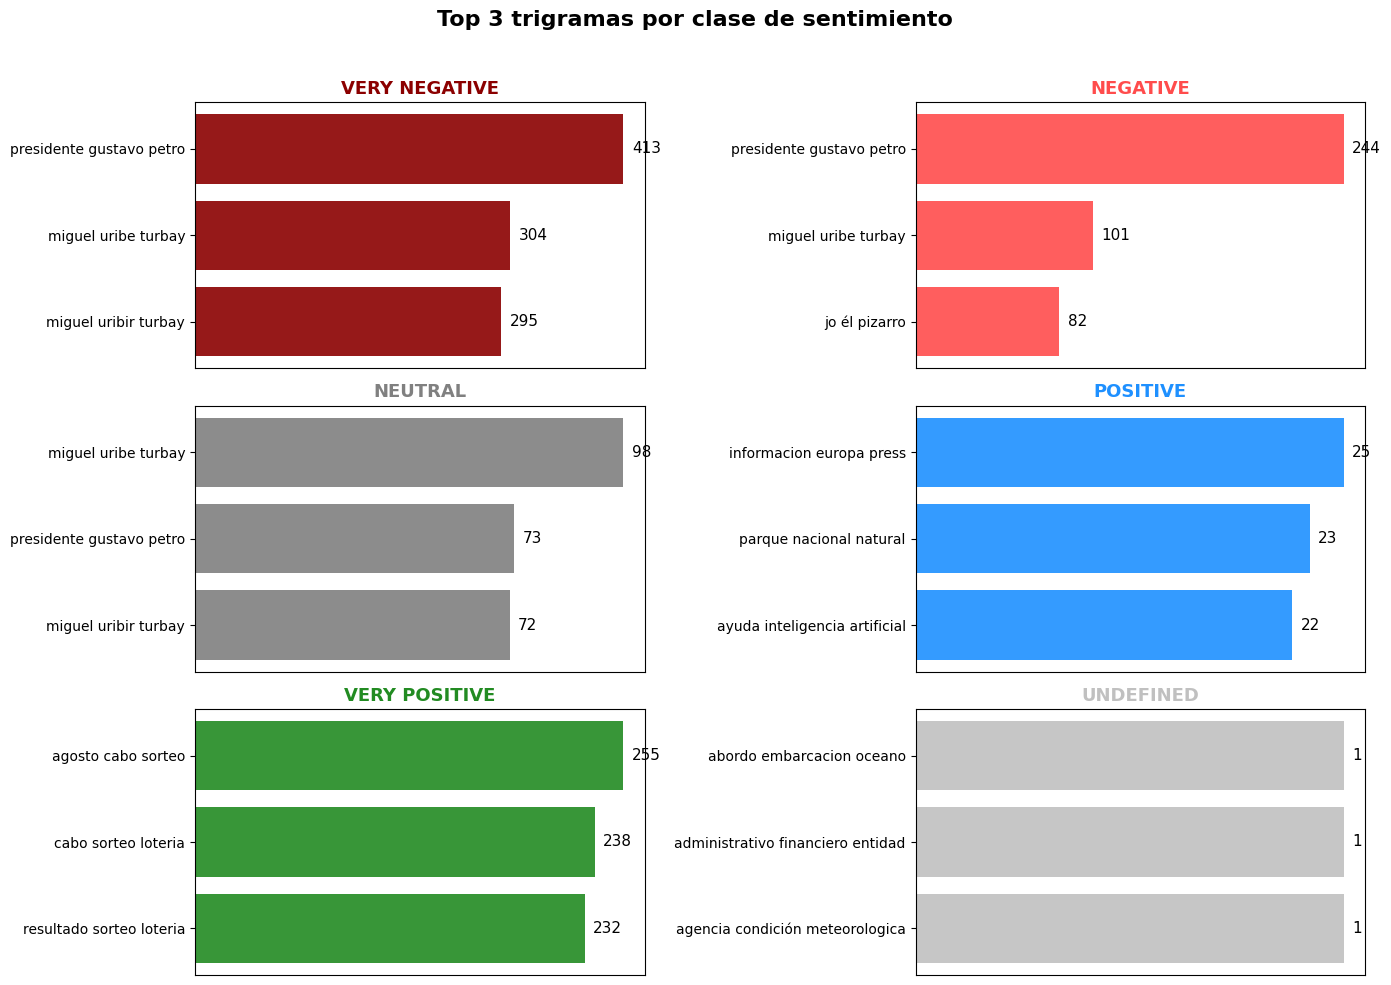

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus["texto"] = corpus["texto_tfidf"].astype(str)
clases = corpus["sentimiento"].unique()
clases = [c for c in ["VERY NEGATIVE","NEGATIVE","NEUTRAL","POSITIVE","VERY POSITIVE","UNDEFINED"] if c in clases]


color_map = {
    "VERY NEGATIVE": "#8B0000",
    "NEGATIVE": "#FF4C4C",
    "NEUTRAL": "#808080",
    "POSITIVE": "#1E90FF",
    "VERY POSITIVE": "#228B22",
    "UNDEFINED": "#C0C0C0"}

def top_ngrams(texts, n=3, ngram_range=(3,3)):
    """
    Obtiene los n-gramas más frecuentes en una lista de textos.

    Args:
        texts (list of str): Lista de documentos en formato texto.
        n (int, optional): Número de n-gramas más frecuentes a devolver.
            Por defecto 3.
        ngram_range (tuple of int, optional): Rango de tamaños de n-gramas a considerar,
            en el formato (min_n, max_n). Por defecto (3, 3), que corresponde a trigramas.

    Returns:
        list of tuple: Lista con los n-gramas más frecuentes y su frecuencia absoluta,
        ordenados de mayor a menor frecuencia. Cada elemento es una tupla:
        (ngram, frecuencia).

    Notas:
        - Utiliza `sklearn.feature_extraction.text.CountVectorizer` para tokenizar y
          contar los n-gramas.
        - El preprocesamiento y la tokenización son los que aplica CountVectorizer
          por defecto (minúsculas, tokenización básica).
        - Puede ser sensible a stopwords y puntuación si no se aplicó
          preprocesamiento previo.
    """

    vec = CountVectorizer(ngram_range=ngram_range)
    X = vec.fit_transform(texts)
    counts = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    freq = sorted(zip(vocab, counts), key=lambda x: x[1], reverse=True)[:n]
    return freq

clases = [c for c in ["VERY NEGATIVE","NEGATIVE","NEUTRAL","POSITIVE","VERY POSITIVE","UNDEFINED"]
          if c in corpus["sentimiento"].unique()]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
for i, clase in enumerate(clases):
    texts = corpus.loc[corpus["sentimiento"] == clase, "texto"]
    top3 = top_ngrams(texts, n=3)

    ax = axes[i]
    if top3:
        ngrams, freqs = zip(*top3)
        ax.barh(ngrams, freqs, color=color_map.get(clase, "#1f77b4"), alpha=0.9)
        ax.set_title(clase, fontsize=13, fontweight="bold", color=color_map.get(clase, "black"))
        ax.invert_yaxis()
        for j, v in enumerate(freqs):
            ax.text(v + max(freqs)*0.02, j, str(v), va="center", fontsize=11, color="black")
        ax.set_xticks([])
    else:
        ax.axis("off")

for j in range(len(clases), 6):
    fig.delaxes(axes[j])

plt.suptitle("Top 3 trigramas por clase de sentimiento", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Interpretación de trigramas por sentimiento

1. **VERY NEGATIVE (Rojo oscuro)**

   - Predominan los trigramas _“presidente gustavo petro”_ y _“miguel uribe turbay”_.
   - Esto indica que la narrativa muy negativa está fuertemente vinculada a la **crítica política**, con énfasis en figuras de alto perfil.
   - Sugiere un discurso polarizado y confrontacional.
   - Tambien se habla de la muerte del pre candidato Miguel Uribe

2. **NEGATIVE (Rojo claro)**

   - Destacan _“presidente gustavo petro”_ y _“miguel uribe turbay”_, pero aparece también _“jo él pizarro”_.
   - Refleja la extensión del sentimiento negativo hacia otros actores políticos.
   - Reafirma que el eje central de lo negativo es el **debate político nacional**.

3. **NEUTRAL (Gris)**

   - Los trigramas más frecuentes siguen siendo _“miguel uribe turbay”_ y _“presidente gustavo petro”_.
   - La diferencia es que aquí los nombres aparecen en un **tono descriptivo/informativo** más que crítico.
   - El sentimiento neutro cumple el rol de narrar hechos sin carga emocional fuerte.

4. **POSITIVE (Azul)**

   - Se destacan _“informacion europa press”_, _“parque nacional natural”_ y _“ayuda inteligencia artificial”_.
   - Este grupo refleja un sentimiento positivo orientado a **temas tecnológicos, ambientales e internacionales**.
   - Muestra un contraste claro frente al predominio político en los negativos.

5. **VERY POSITIVE (Verde)**

   - Aparecen trigramas como _“agosto cabo sorteo”_, _“cabo sorteo loteria”_ y _“resultado sorteo loteria”_.
   - El tono muy positivo se vincula principalmente a **eventos de lotería o premios**.
   - Refleja una narrativa de celebración y expectativas favorables.

6. **UNDEFINED (Gris claro)**
   - Los trigramas (_“abordo embarcacion oceano”_, _“administrativo financiero entidad”_, _“agencia condición meteorologica”_) aparecen solo una vez.
   - Esto indica que esta categoría es marginal y no tiene patrones representativos claros.

### **Conclusiones del análisis de sentimiento**

El análisis de sentimientos revela que el tono predominante del corpus es **negativo**, con una presencia significativa de noticias clasificadas como _VERY NEGATIVE_ y _NEGATIVE_. Esto se observa tanto en la **distribución global de categorías** como en la **evolución temporal**, donde las proporciones de negatividad se mantienen estables a lo largo del tiempo, incluso mostrando un crecimiento hacia finales del periodo analizado. La neutralidad ocupa un espacio intermedio importante, mientras que los sentimientos positivos, aunque presentes, tienen un peso mucho menor.

La **distribución de scores por clase de sentimiento** muestra que las clases extremas (_VERY NEGATIVE_ y _VERY POSITIVE_) son aquellas en las que el modelo exhibe mayor confianza, lo que refuerza la solidez de la clasificación en los extremos del espectro. En contraste, las clases intermedias (_NEGATIVE, NEUTRAL y POSITIVE_) presentan más dispersión en los valores de confianza, lo que indica que el modelo encuentra mayores ambigüedades al diferenciar entre tonos cercanos.

Finalmente, el análisis de **trigramas por clase de sentimiento** aporta un matiz cualitativo: en las categorías negativas aparecen reiteradamente menciones a figuras políticas como _“presidente Gustavo Petro”_ y _“Miguel Uribe Turbay”_, lo que sugiere un sesgo de polarización política en las noticias negativas. En contraste, los trigramas de corte positivo se concentran en temas de carácter informativo o neutro como _“información Europa Press”_ o _“parque nacional natural”_. La clase _VERY POSITIVE_ se asocia principalmente a sorteos y loterías, lo que refleja que la positividad en el corpus no proviene de asuntos políticos o sociales, sino de noticias más ligeras y de entretenimiento.

En conjunto, los resultados muestran que el corpus presenta un fuerte sesgo hacia la negatividad, especialmente en torno a actores políticos, mientras que los aspectos positivos tienden a provenir de noticias de menor relevancia estructural. Este hallazgo es clave para comprender la manera en que los medios tienden a enmarcar el discurso público.


---

## 3. **NER analysis**


In [ ]:
ner_df = pd.read_parquet("corpus_ner.parquet")

In [ ]:
def interactive_ner_plot(df):
    """
    Crea un panel interactivo (compatible con Google Colab) para explorar entidades reconocidas (NER)
    con filtros por categoría y fecha, y selección del top-N por frecuencia.

    El panel muestra cuatro gráficos de barras horizontales (PER, ORG, LOC, MISC) en una misma figura.
    Cada barra representa el conteo de ocurrencias por texto de entidad.

    Args:
        df (pandas.DataFrame): DataFrame con, al menos, las columnas:
            - 'categoria_grupo' (str): Categoría usada para filtrar.
            - 'published_date' (str o datetime-like): Fecha de publicación.
            - 'text' (str): Texto de la entidad.
            - 'label' (str): Etiqueta NER en {"PER", "ORG", "LOC", "MISC"}.
            - 'url' (str): Usada para el conteo por grupo (se cuenta el número de filas por (text, label)).

    Returns:
        None: Renderiza en la notebook los widgets y el gráfico interactivo (Plotly).

    Notas:
        - Incluye tres widgets: categoría, fecha (con opción 'Todos') y top-N de palabras.
        - La lista de fechas del selector se construye filtrando previamente por
          `published_date > '2025-07-31'`. Ajuste esta condición si requiere otro horizonte temporal.
        - Requiere `ipywidgets`, `plotly` y un entorno que soporte su visualización (Colab o Jupyter).
        - Para mostrar el UI se utiliza `display` (de `IPython.display`).
        - El conteo se calcula como número de filas por combinación ('text', 'label') usando `url` como
          columna a contar (`.count()`); si prefiere conteo de ocurrencias únicas, adapte la agregación.
    """
    category_widget = widgets.Dropdown(
        options=['Todos'] + sorted(list(df['categoria_grupo'].unique())),
        description='Categoria:',
        value='Todos'
    )

    date_options_ls = sorted(df[pd.to_datetime(df['published_date']) > pd.to_datetime('2025-07-31')]['published_date'].unique())
    date_widget = widgets.Dropdown(
        options=['Todos'] + date_options_ls,
        description='Fecha:',
        value='Todos',
    )

    top_n_widget = widgets.Dropdown(
        options=range(1, 25),
        description='Number of words:',
        value=10,
    )

    def update_and_plot(category, date, top_n):

        filtered_df = df.copy()

        if category != 'Todos':
            filtered_df = filtered_df[filtered_df['categoria_grupo'] == category]

        if date != 'Todos':
            filtered_df = filtered_df[filtered_df['published_date'] == date]

        grouped_data = filtered_df.groupby(['text', 'label'])['url'].count().reset_index()

        fig = make_subplots(
            rows=1,
            cols=4,
            shared_yaxes=False,
            subplot_titles=("PER", "ORG", "LOC", "MISC"),
            horizontal_spacing=0.1,
        )

        for i, label in enumerate(["PER", "ORG", "LOC", "MISC"], 1):
            data_subset = grouped_data[grouped_data['label'] == label].sort_values('url', ascending=False).head(top_n)

            fig.add_trace(
                go.Bar(
                    x=data_subset['url'],
                    y=data_subset['text'],
                    name=label,
                    orientation='h',
                    marker=dict(cornerradius=10)
                ),
                row=1, col=i
            )

        fig.update_layout(
            height=600,
            width=1200,
            title_text="Interactive NER Plot",
            showlegend=False,
            yaxis_autorange='reversed',
        )

        fig.show()

    out = widgets.interactive_output(
        update_and_plot,
        {'category': category_widget, 'date': date_widget, 'top_n': top_n_widget}
    )

    ui = widgets.HBox([category_widget, date_widget, top_n_widget])
    display(ui, out)

In [ ]:
interactive_ner_plot(ner_df)

Output()

### **Análisis NER (Reconocimiento de Entidades Nombradas)**

El modelo de NER permite identificar de manera automática entidades relevantes dentro del corpus, clasificándolas en categorías como **PER (personas), ORG (organizaciones), LOC (lugares) y MISC (otros términos relevantes)**. La visualización desarrollada es **interactiva**, lo que facilita filtrar dinámicamente por categoría temática (ej. _política_gobierno_) o por fecha, adaptando el análisis a distintos periodos y contextos.

En el gráfico se observa que dentro de la categoría _política_gobierno_, los nombres de figuras políticas como **“Petro”**, **“Gustavo Petro”**, **“Miguel Uribe Turbay”** y **“Nicolás Maduro”** aparecen como los más frecuentes en la clase **PER**. En cuanto a organizaciones (**ORG**), destacan **“Fiscalía General de la Nación”**, **“Fuerzas Militares”**, **“Centro Democrático”** y **“FARC”**, reflejando la relevancia institucional y política de estos actores en las noticias analizadas. En **LOC**, sobresale el predominio de **“Colombia”**, junto con menciones a **Estados Unidos**, **Bogotá**, **Medellín** y **Venezuela**, lo cual sugiere una interacción entre dinámicas nacionales e internacionales. Finalmente, en **MISC** aparecen términos como **“Pacto Histórico”** y **“Presidencia”**, que reflejan tanto partidos políticos como expresiones del discurso mediático.

La **interactividad de la herramienta** permite explorar en detalle qué entidades son más relevantes según la temática y cómo estas cambian a lo largo del tiempo, lo que la convierte en un recurso valioso para la exploración de narrativas mediáticas y el seguimiento de actores clave en el debate público.


---


## **Concluciones del Proyecto NLP**

El proyecto demostró que el uso de técnicas de **procesamiento de lenguaje natural (NLP)** constituye una herramienta poderosa para enfrentar la fragmentación informativa y la sobrecarga de noticias en Colombia. A partir de un corpus diverso de artículos, se implementaron modelos de clasificación temática (TF-IDF, BoW y BERT), análisis de sentimiento con modelos preentrenados y extracción de entidades nombradas (NER), lo que permitió generar un panorama integral sobre el contenido y el tono de la información publicada en medios nacionales.

En línea con lo planteado en el **marco de proyecto**, los resultados confirman la utilidad de este tipo de análisis tanto para **ciudadanos** interesados en comprender mejor la coyuntura nacional como para **organismos públicos y privados** que requieren detectar tendencias sociales, políticas y económicas. La clasificación mostró fortalezas y limitaciones: mientras que categorías como _política_gobierno_ y _deportes_ alcanzaron desempeños aceptables, otras con menos representación sufrieron caídas en precisión, lo que resalta la importancia de contar con bases de datos balanceadas y de gran escala.

El análisis de **sentimientos** reveló una marcada predominancia de tonos negativos y muy negativos, acompañados de neutralidad en segundo lugar, lo que sugiere una percepción pesimista en la narrativa mediática durante el período analizado. Este hallazgo es relevante para comprender el impacto emocional que transmiten los medios y su influencia sobre la opinión pública.

Por su parte, el **NER interactivo** permitió identificar actores, organizaciones y lugares recurrentes en las noticias, ofreciendo un mapa claro de los protagonistas de la coyuntura informativa. Esta herramienta aporta un valor agregado al transformar datos dispersos en insumos estructurados para la toma de decisiones.

En conclusión, el proyecto no solo cumplió con el **alcance inicial** de aplicar técnicas de NLP para clasificar, analizar y organizar noticias, sino que además evidenció el potencial de estas metodologías para construir un **radar de actualidad**. Dicho radar permite detectar dinámicas sociales y políticas en tiempo real, facilitando investigaciones académicas, el diseño de estrategias de comunicación y la elaboración de políticas públicas basadas en evidencia.
